## Variational Fourier Regression

In [1]:
import jax
from jax import config
from jax import Array
import jax.numpy as jnp
config.update("jax_enable_x64", True)  # do this at the very top

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams["figure.figsize"] = (5, 3)
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern Roman"]  # matches LaTeX default

import mplcyberpunk
plt.style.use("cyberpunk")

from vgd.model import FourierPredictor
from vgd.distribution import FourierParticles, NormalDiag, SignedMixtureLike
from vgd.kernel import RBFKernel, KernelParams
from vgd.loss import DeterministicRiskLoss, squared_loss_and_grad, logistic_loss_and_grad, ISFDeterministicRiskLoss
from vgd.methods import vgd, vgd_weight, mfld, vgd_random
from vgd.util import plot_1d_predictive_output, plot_isf_results
from vgd.methods.isf import isf


In [3]:
# -----------------------
# Synthetic data makers
# -----------------------
def make_regression_data(n=256, key=jax.random.PRNGKey(0)):
    kx, kn = jax.random.split(key)
    X = jax.random.uniform(kx, (n, 1), minval=-3.0, maxval=3.0)
    f_true = jnp.sin(2.0 * X[:, 0]) + 0.5 * jnp.cos(1.3 * X[:, 0])
    y = f_true + 0.15 * jax.random.normal(kn, (n,))
    return {"x": X, "y": y}, f_true  # f_true for diagnostics

def make_classification_data(n=512, key=jax.random.PRNGKey(1)):
    kx, kn = jax.random.split(key)
    X = jax.random.uniform(kx, (n, 2), minval=-2.5, maxval=2.5)
    logits = 1.2 * jnp.sin(2.0 * X[:, 0]) + 0.8 * X[:, 1]
    logits = logits + 0.5 * jax.random.normal(kn, (n,))
    probs = jax.nn.sigmoid(logits)
    y = jnp.where(probs > 0.5, 1.0, 0.0)
    return {"x": X, "y": y.astype(jnp.float32)}, logits


# -----------------------
# Fourier particle init
# -----------------------
def init_fourier_particles(
    n_particles: int,
    d: int,
    key: Array,
    w_scale: float = 1.0,          # freq std
    phase_uniform: bool = True,
    alpha_scale: float = 0.1       # weight std (smaller is usually stabler)
) -> SignedMixtureLike:
    k1, k2, k3 = jax.random.split(key, 3)
    omega = jax.random.normal(k1, (n_particles, d)) * w_scale         # (n,d)
    if phase_uniform: 
        b = jax.random.uniform(k2, (n_particles, 1), minval=0.0, maxval=2.0 * jnp.pi) 
    else: 
        b = jnp.zeros((n_particles, 1))
    particles = jnp.concatenate([omega, b], axis=1)                   # (n, d+1)
    alpha = jax.random.normal(k3, (n_particles,)) * alpha_scale       # (n,)
    return SignedMixtureLike(particles=particles, alpha=alpha)


# -----------------------
# Simple metrics
# -----------------------
def mse(y, yhat):
    r = yhat - y
    return float(jnp.mean(r * r))

def accuracy(y, logits):
    preds = (jax.nn.sigmoid(logits) >= 0.5).astype(y.dtype)
    return float(jnp.mean((preds == y).astype(jnp.float32)))



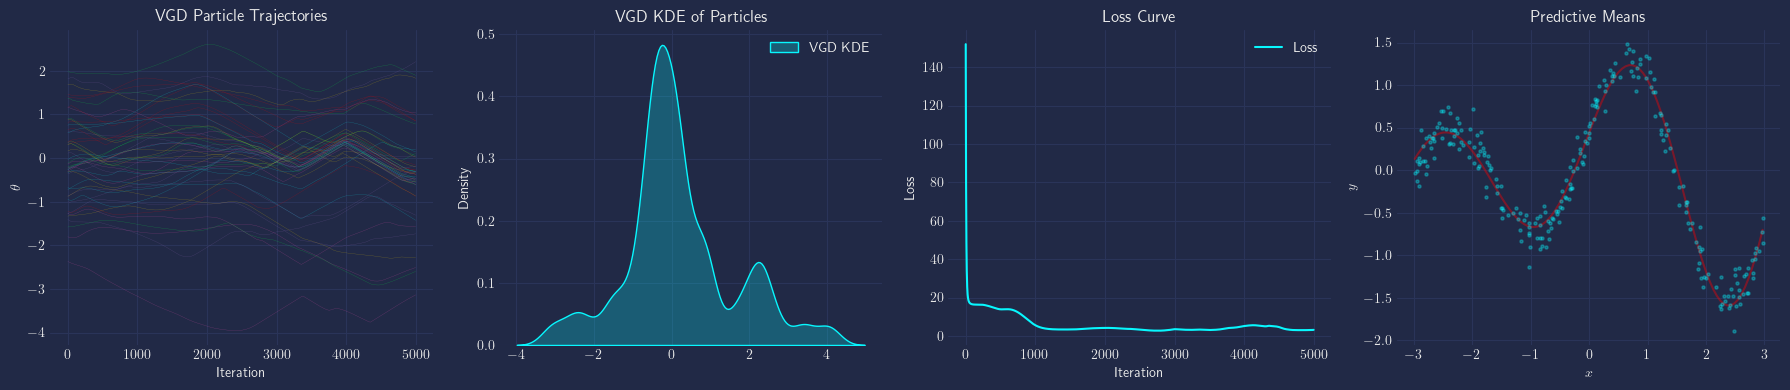

In [4]:
key = jax.random.PRNGKey(42)
data, f_true = make_regression_data(n=256, key=key)
N, d = data["x"].shape

# Init Fourier mixture
Q0 = init_fourier_particles(n_particles=48, d=d, key=key, w_scale=1.0, phase_uniform=True)

# Predictor + Loss
prior = NormalDiag(sd=1.0)
predictor = FourierPredictor(prior_plus=prior, prior_minus=prior, data = data, x_key="x", y_key="y")
loss = ISFDeterministicRiskLoss(loss_and_grad=squared_loss_and_grad)

# Kernel & params (adjust KernelParams(...) if your signature differs)
kparams = KernelParams(lengthscale=jnp.asarray(1.), amplitude=jnp.asarray(1.0)) 
kernel = RBFKernel()

# Pre-train diagnostics
f0 = predictor.predict(Q0)

# Run VGD
out = isf(
    model=predictor,
    loss=loss,
    kernel=kernel,
    kparams=kparams,
    eps_theta=1e-2,
    eps_alpha = 1e-4,
    lambda_skl = 1.,
    Q0=Q0,
    steps=5000,
    ema_alpha=1.0,
    use_median_lengthscale=True,
    return_metrics=True,
)
Qhat, metrics = out if isinstance(out, tuple) else (out, None)

Qfinal, history = out
plot_1d_predictive_output(Qfinal, history, predictor)
plt.show()

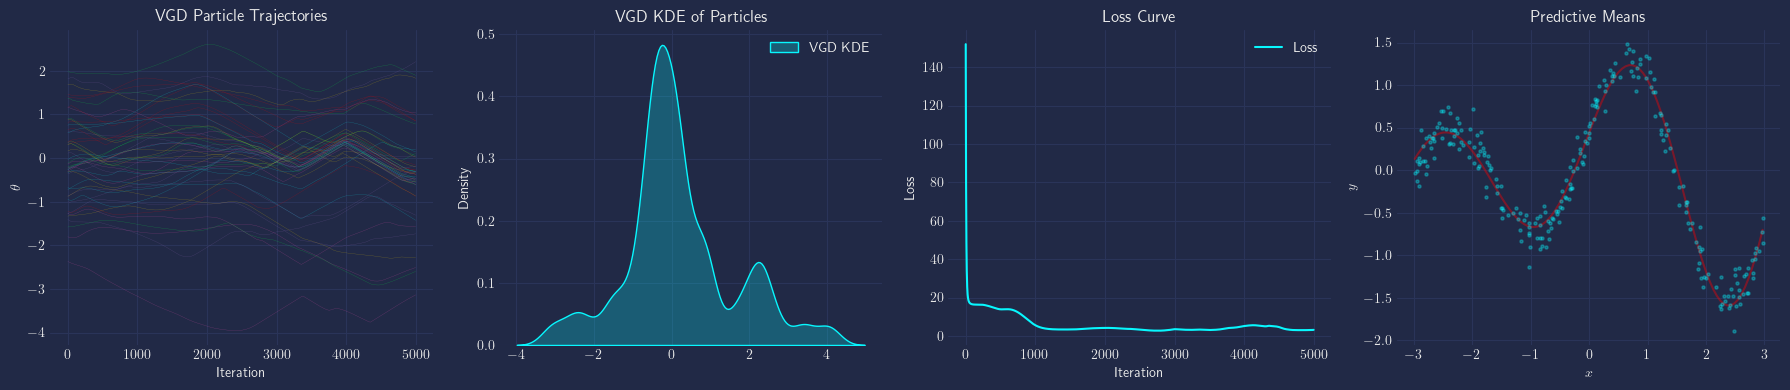

In [4]:
Qfinal, history = out
plot_1d_predictive_output(Qfinal, history, predictor)
plt.show()

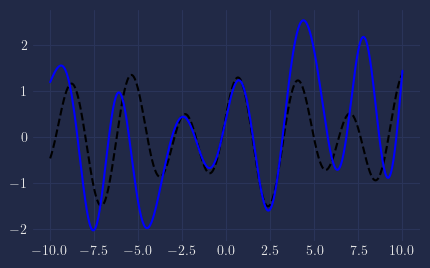

In [5]:
xgrid = jnp.linspace(-10, 10, 512).reshape(-1, 1)

ygrid = jnp.sin(2.0 * xgrid[:, 0]) + 0.5 * jnp.cos(1.3 * xgrid[:, 0])

plt.plot(xgrid, ygrid, 'k--', label='True function')

preds = predictor.predict_on_x(Qfinal, xgrid)
plt.plot(xgrid, preds, 'b', label='VG-D output')

In [6]:



def make_classification_data(n=512, key=jax.random.PRNGKey(1)):
    kx, kn = jax.random.split(key)
    X = jax.random.uniform(kx, (n, 2), minval=-2.5, maxval=2.5)
    logits = 1.2 * jnp.sin(2.0 * X[:, 0]) + 0.8 * X[:, 1]
    logits = logits + 0.5 * jax.random.normal(kn, (n,))
    probs = jax.nn.sigmoid(logits)
    y = jnp.where(probs > 0.5, 1.0, 0.0)
    return {"x": X, "y": y.astype(jnp.float32)}, logits

key = jax.random.PRNGKey(42)
data, logits = make_classification_data(n=256, key=key)
N, d = data["x"].shape

# Init Fourier mixture
Q0 = init_fourier_particles(n_particles=48, d=d, key=key, w_scale=1.0, phase_uniform=True)

# Predictor + Loss
prior = NormalDiag(sd=1.0)
predictor = FourierPredictor(prior_plus=prior, prior_minus=prior, data = data, x_key="x", y_key="y")
loss = ISFDeterministicRiskLoss(loss_and_grad=logistic_loss_and_grad)

# Kernel & params (adjust KernelParams(...) if your signature differs)
kparams = KernelParams(lengthscale=jnp.asarray(1.), amplitude=jnp.asarray(1.0)) 
kernel = RBFKernel()

# Pre-train diagnostics
f0 = predictor.predict(Q0)

# Run VGD
out = isf(
    model=predictor,
    loss=loss,
    kernel=kernel,
    kparams=kparams,
    eps_theta=1e-2,
    eps_alpha = 1e-4,
    lambda_skl = 1.,
    Q0=Q0,
    steps=5000,
    ema_alpha=1.0,
    use_median_lengthscale=True,
    return_metrics=True,
)
Qhat, metrics = out if isinstance(out, tuple) else (out, None)

# Post-train diagnostics
fhat = predictor.predict(Qhat)
print("MSE after:", mse(data["y"], fhat))

# Optional: show a couple of metric keys if present
if metrics:
    keys = list(metrics.keys())
    show = keys[:3]
    for k in show:
        try:
            print(f"metric[{k}][-1] =", float(np.array(metrics[k])[-1]))
        except Exception:
            pass


MSE after: 6.16179746525132
metric[loss][-1] = 83.39447561830862


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

def plot_isf_results(
    predictor,
    data,
    Q0,
    Qhat,
    metrics=None,
    grid_lim=2.5,
    grid_n=200,
    title_prefix="ISF"
):
    def _to_np(x):
        return np.asarray(x)

    def _grid_2d(lim=2.5, n=200):
        xs = np.linspace(-lim, lim, n)
        ys = np.linspace(-lim, lim, n)
        XX, YY = np.meshgrid(xs, ys)
        XY = np.stack([XX.ravel(), YY.ravel()], axis=1)  # (n*n, 2)
        return XX, YY, XY

    def _predict_probs(predictor, Q, XY):
        logits = _to_np(predictor.predict_on_x(Q, XY))   # (M,)
        return 1.0 / (1.0 + np.exp(-logits))

    X = _to_np(data["x"])
    y = _to_np(data["y"]).astype(int)

    XX, YY, XY = _grid_2d(lim=grid_lim, n=grid_n)

    P0 = _predict_probs(predictor, Q0, XY).reshape(XX.shape)
    Ph = _predict_probs(predictor, Qhat, XY).reshape(XX.shape)
    dP = Ph - P0


    # One figure, 2x3 grid
    fig = plt.figure(figsize=(14, 8))
    gs = gridspec.GridSpec(2, 3, figure=fig, height_ratios=[1, 1])

    # --- Axes ---
    ax_init  = fig.add_subplot(gs[0, 0])
    ax_final = fig.add_subplot(gs[0, 1])
    ax_diff  = fig.add_subplot(gs[0, 2])
    ax_loss  = fig.add_subplot(gs[1, 0])
    ax_norms = fig.add_subplot(gs[1, 1])
    ax_hist  = fig.add_subplot(gs[1, 2])

    # Common plotting helper for surfaces
    def _plot_surface(ax, Z, title, draw_points=True, levels=25, vmin=0.0, vmax=1.0, show_cb=True):
        im = ax.contourf(XX, YY, Z, levels=levels, vmin=vmin, vmax=vmax, alpha=0.85)
        cs = ax.contour(XX, YY, Z, levels=[0.5], colors="k", linewidths=1.2)
        ax.clabel(cs, inline=True, fontsize=8, fmt="0.5")
        if draw_points:
            ax.scatter(X[y == 0, 0], X[y == 0, 1], s=12, c="C0", label="class 0", alpha=0.8, edgecolors="none")
            ax.scatter(X[y == 1, 0], X[y == 1, 1], s=12, c="C1", label="class 1", alpha=0.8, edgecolors="none")
            ax.legend(loc="upper right", frameon=True, fontsize=8)
        ax.set_title(title)
        ax.set_xlabel("x1"); ax.set_ylabel("x2")
        ax.set_xlim(-grid_lim, grid_lim); ax.set_ylim(-grid_lim, grid_lim)
        if show_cb:
            fig.colorbar(im, ax=ax, shrink=0.8)

    # Top row: initial, final, delta
    _plot_surface(ax_init,  P0, f"{title_prefix}: initial $p(y=1)$")
    _plot_surface(ax_final, Ph, f"{title_prefix}: final $p(y=1)$")

    # For difference, symmetric color range around 0
    vmax = np.max(np.abs(dP))
    imd = ax_diff.contourf(XX, YY, dP, levels=25, vmin=-vmax, vmax=vmax, alpha=0.9, cmap="coolwarm")
    csd = ax_diff.contour(XX, YY, Ph, levels=[0.5], colors="k", linewidths=1.0)
    ax_diff.clabel(csd, inline=True, fontsize=8, fmt="final 0.5")
    ax_diff.set_title(f"{title_prefix}: $\Delta p$ = final - initial")
    ax_diff.set_xlabel("x1"); ax_diff.set_ylabel("x2")
    ax_diff.set_xlim(-grid_lim, grid_lim); ax_diff.set_ylim(-grid_lim, grid_lim)
    fig.colorbar(imd, ax=ax_diff, shrink=0.8)

    # Bottom-left: loss curve (if available)
    if metrics is not None and "loss" in metrics:
        loss = _to_np(metrics["loss"])
        ax_loss.plot(loss, lw=1.5)
        ax_loss.set_title("training loss")
        ax_loss.set_xlabel("step"); ax_loss.set_ylabel("loss")
    else:
        ax_loss.axis("off")
        ax_loss.set_title("training loss (unavailable)")

    # Bottom-middle: step norms (if available)
    has_r = metrics is not None and "rkhs_step_norm" in metrics
    has_s = metrics is not None and "stein_step_norm" in metrics
    if has_r or has_s:
        if has_r: ax_norms.plot(_to_np(metrics["rkhs_step_norm"]), label="rkhs_step_norm", lw=1.5)
        if has_s: ax_norms.plot(_to_np(metrics["stein_step_norm"]), label="stein_step_norm", lw=1.5)
        ax_norms.set_title("step norms")
        ax_norms.set_xlabel("step"); ax_norms.set_ylabel("norm")
        ax_norms.legend()
    else:
        ax_norms.axis("off")
        ax_norms.set_title("step norms (unavailable)")

    # Bottom-right: alpha histogram (if available)
    if hasattr(Qhat, "alpha"):
        al = _to_np(Qhat.alpha)
        ax_hist.hist(al, bins=20, edgecolor="white")
        ax_hist.set_title("final weights (alpha)")
        ax_hist.set_xlabel("alpha"); ax_hist.set_ylabel("count")
    else:
        ax_hist.axis("off")
        ax_hist.set_title("final weights (unavailable)")

    fig.suptitle(title_prefix, y=0.99, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


In [19]:
import numpy as np
import matplotlib.pyplot as plt

def _to_np(x):
    try:
        return np.asarray(x)
    except Exception:
        return np.array(x)

def _grid_2d(lim=2.5, n=200):
    xs = np.linspace(-lim, lim, n)
    ys = np.linspace(-lim, lim, n)
    XX, YY = np.meshgrid(xs, ys)
    XY = np.stack([XX.ravel(), YY.ravel()], axis=1)  # (n*n, 2)
    return XX, YY, XY

def _predict_probs(predictor, Q, XY):
    # predictor returns logits; turn into probabilities
    logits = _to_np(predictor.predict_on_x(Q, XY))           # (M,)
    probs = 1.0 / (1.0 + np.exp(-logits))
    return probs

def plot_isf_results(
    predictor,
    data,
    Q0,
    Qhat,
    metrics=None,
    grid_lim=2.5,
    grid_n=200,
    title_prefix="ISF"
):
    X = _to_np(data["x"])
    y = _to_np(data["y"]).astype(int)

    XX, YY, XY = _grid_2d(lim=grid_lim, n=grid_n)

    # initial + final probability fields
    P0 = _predict_probs(predictor, Q0, XY).reshape(XX.shape)
    Ph = _predict_probs(predictor, Qhat, XY).reshape(XX.shape)

    # --- Figure 1: initial surface ---
    plt.figure(figsize=(6, 5))
    plt.contourf(XX, YY, P0, levels=25, alpha=0.8)
    cs = plt.contour(XX, YY, P0, levels=[0.5], linewidths=1.5)
    plt.clabel(cs, inline=True, fontsize=8)
    plt.scatter(X[y == 0, 0], X[y == 0, 1], s=15, label="class 0")
    plt.scatter(X[y == 1, 0], X[y == 1, 1], s=15, label="class 1")
    plt.title(f"{title_prefix}: initial decision surface")
    plt.xlabel("x1"); plt.ylabel("x2"); plt.legend(); plt.tight_layout()

    # --- Figure 2: final surface ---
    plt.figure(figsize=(6, 5))
    plt.contourf(XX, YY, Ph, levels=25, alpha=0.8)
    cs = plt.contour(XX, YY, Ph, levels=[0.5], linewidths=1.5)
    plt.clabel(cs, inline=True, fontsize=8)
    plt.scatter(X[y == 0, 0], X[y == 0, 1], s=15, label="class 0")
    plt.scatter(X[y == 1, 0], X[y == 1, 1], s=15, label="class 1")
    plt.title(f"{title_prefix}: final decision surface")
    plt.xlabel("x1"); plt.ylabel("x2"); plt.legend(); plt.tight_layout()

    # --- Figure 3: loss curve (if available) ---
    if metrics and "loss" in metrics:
        loss = _to_np(metrics["loss"])
        plt.figure(figsize=(6, 4))
        plt.plot(loss)
        plt.title(f"{title_prefix}: training loss")
        plt.xlabel("step"); plt.ylabel("loss"); plt.tight_layout()

    # --- Figure 4: step norms (if available) ---
    has_r = metrics and "rkhs_step_norm" in metrics
    has_s = metrics and "stein_step_norm" in metrics
    if has_r or has_s:
        plt.figure(figsize=(6, 4))
        if has_r: plt.plot(_to_np(metrics["rkhs_step_norm"]), label="rkhs_step_norm")
        if has_s: plt.plot(_to_np(metrics["stein_step_norm"]), label="stein_step_norm")
        plt.title(f"{title_prefix}: step norms")
        plt.xlabel("step"); plt.ylabel("norm"); plt.legend(); plt.tight_layout()

    # (optional) Figure 5: alpha histogram to inspect sign balance
    if hasattr(Qhat, "alpha"):
        al = _to_np(Qhat.alpha)
        plt.figure(figsize=(6, 4))
        plt.hist(al, bins=20)
        plt.title(f"{title_prefix}: final weights (alpha)"); plt.xlabel("alpha"); plt.ylabel("count")
        plt.tight_layout()

    plt.show()


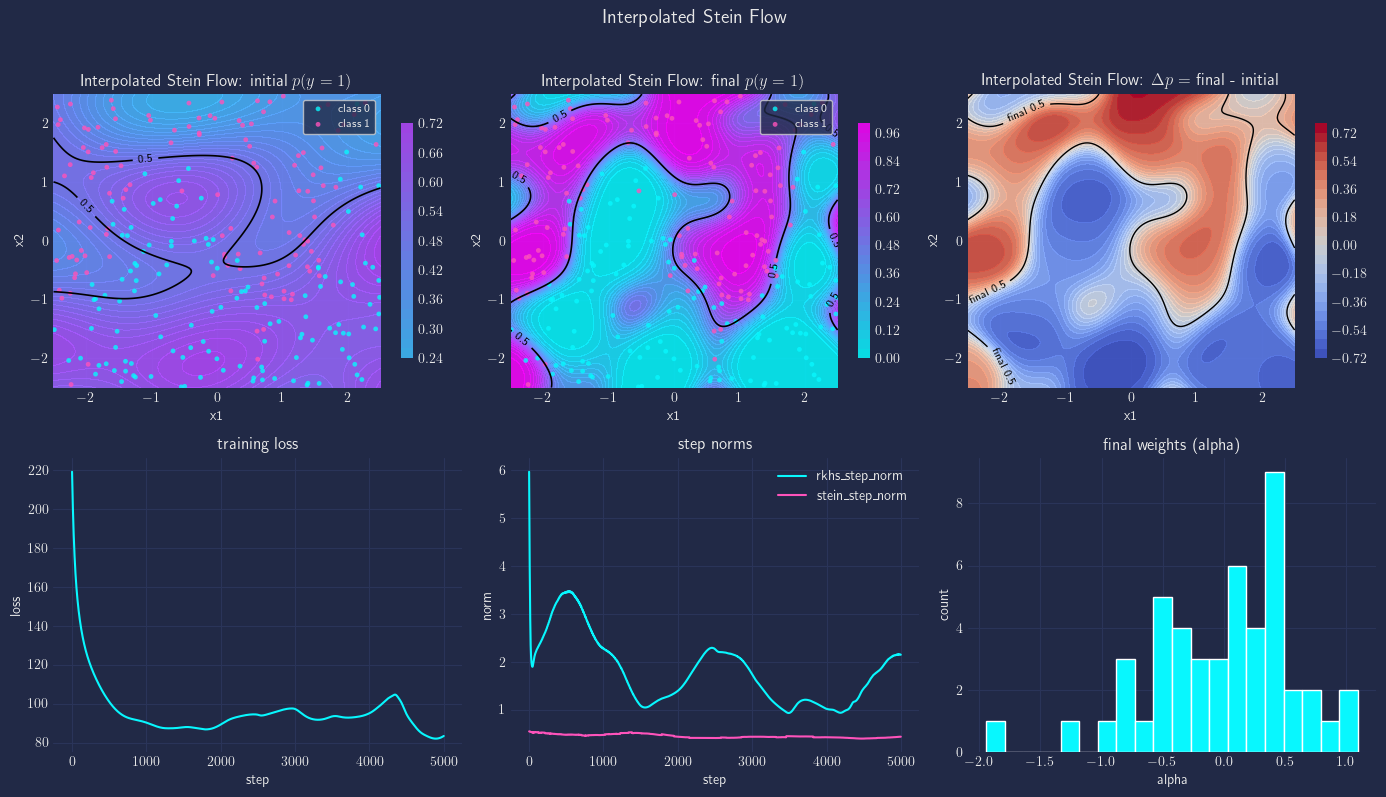

In [7]:
plot_isf_results(
    predictor=predictor,
    data=data,
    Q0=Q0,
    Qhat=Qhat,
    metrics=metrics,
    grid_lim=2.5,
    grid_n=200,
    title_prefix="Interpolated Stein Flow"
)


# tests

In [5]:
import jax, jax.numpy as jnp

# --- Classification ---

def make_spiral_classification(n_per_class=600, noise=0.12, turns=3.0, flip_prob=0.0, key=jax.random.PRNGKey(0)):
    k1, k2, k3, kf = jax.random.split(key, 4)
    # sample angles independently for each class (no pairing)
    t1 = jax.random.uniform(k1, (n_per_class,), minval=0., maxval=turns * 2*jnp.pi)
    t2 = jax.random.uniform(k2, (n_per_class,), minval=0., maxval=turns * 2*jnp.pi)
    r1 = 0.2 + 0.8 * t1 / (turns * 2*jnp.pi)
    r2 = 0.2 + 0.8 * t2 / (turns * 2*jnp.pi)
    X1 = jnp.stack([r1 * jnp.cos(t1), r1 * jnp.sin(t1)], axis=1)
    X2 = jnp.stack([r2 * jnp.cos(t2 + jnp.pi), r2 * jnp.sin(t2 + jnp.pi)], axis=1)
    X = jnp.concatenate([X1, X2], axis=0)
    y = jnp.concatenate([jnp.zeros((n_per_class,)), jnp.ones((n_per_class,))], axis=0)
    X = X + noise * jax.random.normal(k3, X.shape)
    # optional label flips to enforce Bayes error
    if flip_prob > 0:
        flip = jax.random.bernoulli(kf, p=flip_prob, shape=y.shape)
        y = jnp.where(flip, 1.0 - y, y)
    perm = jax.random.permutation(k3, X.shape[0])
    return {"x": X[perm], "y": y[perm].astype(jnp.float32)}


def make_checkerboard_classification(n=2048, cells=4, key=jax.random.PRNGKey(1)):
    k1, k2 = jax.random.split(key)
    X = jax.random.uniform(k1, (n, 2), minval=-3., maxval=3.)
    # non-axis-aligned checkerboard (rotate)
    theta = 0.6
    R = jnp.array([[jnp.cos(theta), -jnp.sin(theta)],[jnp.sin(theta), jnp.cos(theta)]])
    Z = X @ R.T
    cell = (Z + 3.) / (6. / cells)
    y = ((jnp.floor(cell[:,0]) + jnp.floor(cell[:,1])) % 2).astype(jnp.float32)
    y = jnp.where(jax.random.uniform(k2, (n,)) < 0.05, 1. - y, y)  # a bit of label noise
    return {"x": X, "y": y}

# --- Regression (2D, nonstationary, heteroscedastic) ---

def make_bumpy_regression_2d(n=2048, key=jax.random.PRNGKey(2)):
    kx, kn1, kn2 = jax.random.split(key, 3)
    X = jax.random.uniform(kx, (n, 2), minval=-3., maxval=3.)
    x1, x2 = X[:,0], X[:,1]
    f = (jnp.sin(2.2*x1) + 0.6*jnp.cos(1.7*x2)
         + 0.8*jnp.exp(-0.7*((x1-1.2)**2 + (x2+0.8)**2))
         - 0.6*jnp.exp(-3.5*((x1+1.0)**2 + (x2-1.5)**2))
         + 0.25*jnp.sign(x1 - 0.6*x2))  # a small discontinuity
    # heteroscedastic noise
    sigma = 0.05 + 0.25 * jax.nn.sigmoid(1.2*(x1 + 0.5*x2))
    y = f + sigma * jax.random.normal(kn1, (n,))
    return {"x": X, "y": y}, f  # return noiseless f for diagnostics

# --- Add nuisance dimensions (uninformative features) ---

def add_nuisance_dims(data, k_extra=8, scale=1.0, key=jax.random.PRNGKey(3)):
    X = data["x"]; n = X.shape[0]
    Z = scale * jax.random.normal(key, (n, k_extra))
    Xnz = jnp.concatenate([X, Z], axis=1)
    return {"x": Xnz, "y": data["y"]}, k_extra


def train_test_split(data, frac=0.7, key=jax.random.PRNGKey(0)):
    n = data["x"].shape[0]
    idx = jax.random.permutation(key, n)
    n_tr = int(frac * n)
    tr, te = idx[:n_tr], idx[n_tr:]
    dtr = {"x": data["x"][tr], "y": data["y"][tr]}
    dte = {"x": data["x"][te], "y": data["y"][te]}
    return dtr, dte

def add_nuisance_dims(data, k_extra=10, scale=1.0, key=jax.random.PRNGKey(99)):
    X = data["x"]; n = X.shape[0]
    Z = scale * jax.random.normal(key, (n, k_extra))
    return {"x": jnp.concatenate([X, Z], axis=1), "y": data["y"]}


In [22]:
import functools
import jax
import jax.numpy as jnp
from jax import tree_util as jtu  

# ----- MLP params -----
def glorot(k, fan_in, fan_out):
    limit = jnp.sqrt(6.0 / (fan_in + fan_out))
    return jax.random.uniform(k, (fan_in, fan_out), minval=-limit, maxval=limit)

def init_mlp_params(sizes, key):
    """sizes: [in, h1, h2, ..., out]"""
    keys = jax.random.split(key, len(sizes)-1)
    params = []
    for k, (fin, fout) in zip(keys, zip(sizes[:-1], sizes[1:])):
        W = glorot(k, fin, fout)
        b = jnp.zeros((fout,))
        params.append((W, b))
    return params

def mlp_forward(params, x, activation=jax.nn.gelu):
    h = x
    for (W, b) in params[:-1]:
        h = activation(h @ W + b)
    W, b = params[-1]
    return h @ W + b  # raw output (logits for cls, value for reg)

# ----- Adam -----
# ----- Adam -----
@jax.jit  # static_argnames optional; leaving default is fine
def adam_step(params, grads, opt_state, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
    t, m, v = opt_state
    t = t + 1
    m = jtu.tree_map(lambda m_, g_: beta1 * m_ + (1 - beta1) * g_, m, grads)
    v = jtu.tree_map(lambda v_, g_: beta2 * v_ + (1 - beta2) * (g_ * g_), v, grads)
    mhat = jtu.tree_map(lambda m_: m_ / (1 - beta1 ** t), m)
    vhat = jtu.tree_map(lambda v_: v_ / (1 - beta2 ** t), v)
    new_params = jtu.tree_map(lambda p, mh, vh: p - lr * mh / (jnp.sqrt(vh) + eps),
                              params, mhat, vhat)
    return new_params, (t, m, v)

def adam_init(params):
    zeros_like = jtu.tree_map(jnp.zeros_like, params)
    return (jnp.array(0, dtype=jnp.int32), zeros_like, zeros_like)


# ----- Losses -----
def mse_loss(params, X, y):
    pred = mlp_forward(params, X).squeeze(-1)
    r = pred - y
    return jnp.mean(r*r)

def logistic_loss(params, X, y):
    logits = mlp_forward(params, X).squeeze(-1)
    # numerically stable: softplus - y*logits
    return jnp.mean(jnp.logaddexp(0.0, logits) - y*logits)

# ----- Train loops -----
def train_mlp_regression(X, y, hidden=(128,128), epochs=3000, lr=1e-3, l2=1e-5, key=jax.random.PRNGKey(0)):
    sizes = [X.shape[1], *hidden, 1]
    params = init_mlp_params(sizes, key)
    opt = adam_init(params)

    @jax.jit
    def step(params, opt, X, y):
        def loss_fn(p):
            val = mse_loss(p, X, y)
            l2pen = sum(jnp.sum(W*W) for (W, b) in p)
            return val + l2 * l2pen
        val, grads = jax.value_and_grad(loss_fn)(params)
        params2, opt2 = adam_step(params, grads, opt, lr=lr)
        return params2, opt2, val

    hist = []
    for _ in range(epochs):
        params, opt, val = step(params, opt, X, y)
        hist.append(val)
    return params, jnp.stack(hist)

def train_mlp_classification(X, y, hidden=(128,128), epochs=3000, lr=1e-3, l2=1e-5, key=jax.random.PRNGKey(1)):
    sizes = [X.shape[1], *hidden, 1]
    params = init_mlp_params(sizes, key)
    opt = adam_init(params)

    @jax.jit
    def step(params, opt, X, y):
        def loss_fn(p):
            val = logistic_loss(p, X, y)
            l2pen = sum(jnp.sum(W*W) for (W, b) in p)
            return val + l2 * l2pen
        val, grads = jax.value_and_grad(loss_fn)(params)
        params2, opt2 = adam_step(params, grads, opt, lr=lr)
        return params2, opt2, val

    hist = []
    for _ in range(epochs):
        params, opt, val = step(params, opt, X, y)
        hist.append(val)
    return params, jnp.stack(hist)

def predict_mlp(params, X, task="reg"):
    out = mlp_forward(params, X).squeeze(-1)
    if task == "cls":
        return out  # logits
    return out      # values


In [7]:
# 1) data
key = jax.random.PRNGKey(42)
# data2d = make_spiral_classification(n_per_class=600, noise=0.12, turns=3.0, flip_prob=0.05, key=key)
data2d = make_checkerboard_classification(n=1200,cells=4, key=key)

train2d, test2d = train_test_split(data2d, frac=0.7, key=jax.random.PRNGKey(7))
train_hd = add_nuisance_dims(train2d, k_extra=1, key=jax.random.PRNGKey(11))
test_hd  = add_nuisance_dims(test2d,  k_extra=1, key=jax.random.PRNGKey(12))

# 2) ISF setup (train on high-D)
N, d = train_hd["x"].shape
Q0 = init_fourier_particles(n_particles=100, d=d, key=jax.random.PRNGKey(0), w_scale=1.0, alpha_scale=0.05)
prior = NormalDiag(sd=2.0)
predictor = FourierPredictor(prior_plus=prior, prior_minus=prior, data=train_hd)
loss = ISFDeterministicRiskLoss(loss_and_grad=logistic_loss_and_grad)
kparams = KernelParams(lengthscale=jnp.asarray(1.), amplitude=jnp.asarray(1.0))
kernel = RBFKernel()

# 3) Train ISF
Qhat, metrics = isf(
    model=predictor, loss=loss, kernel=kernel, kparams=kparams,
    eps_theta=1e-3, eps_alpha=1e-3, lambda_skl=1., Q0=Q0,
    steps=5000, return_metrics=True
)

# 4) Test accuracy (high-D)
predictor_test = FourierPredictor(prior_plus=prior, prior_minus=prior, data=test_hd)
logits_isf_te = predictor_test.predict(Qhat)
acc_isf_test = float(jnp.mean((jax.nn.sigmoid(logits_isf_te) >= 0.5) == test_hd["y"]))
print("ISF test acc:", acc_isf_test)

# 5) MLP baseline (train on high-D, evaluate on high-D test)
mlp_params, mlp_hist = train_mlp_classification(train_hd["x"], train_hd["y"],
                                                hidden=(32,32), epochs=3000, lr=2e-3, l2=1e-4)
logits_mlp_te = predict_mlp(mlp_params, test_hd["x"], task="cls")
acc_mlp_test = float(jnp.mean((jax.nn.sigmoid(logits_mlp_te) >= 0.5) == test_hd["y"]))
print("MLP test acc:", acc_mlp_test)


ISF test acc: 0.6861111521720886


NameError: name 'train_mlp_classification' is not defined

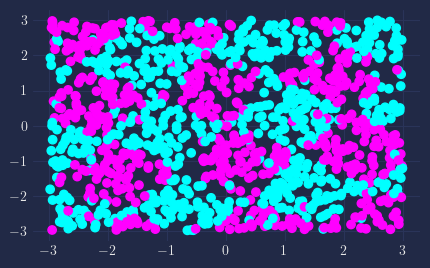

In [38]:
plt.scatter(data2d['x'][:,0], data2d['x'][:,1], c=data2d['y'])

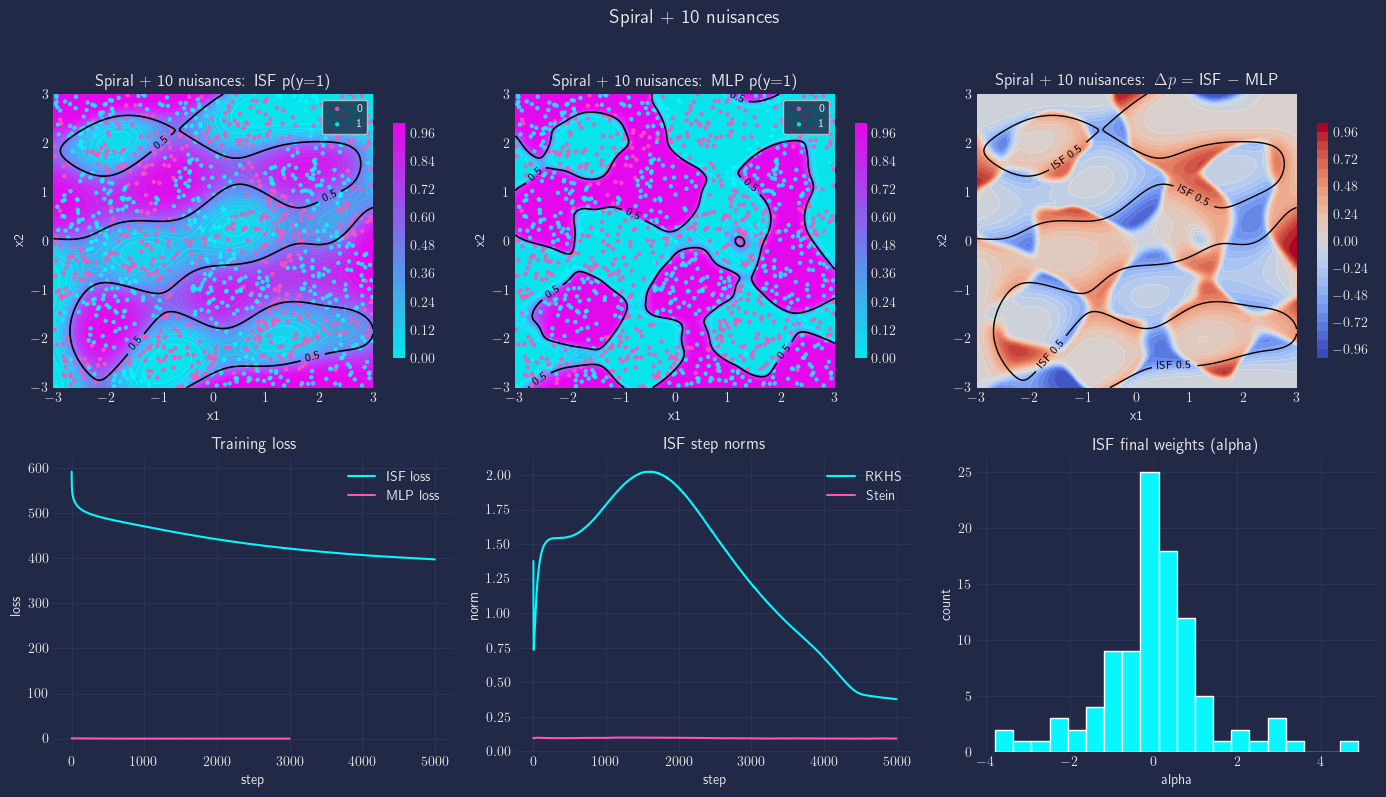

In [ ]:
plot_isf_vs_mlp_onefig(
    predictor=predictor,      
    Qhat=Qhat,                
    mlp_params=mlp_params,    
    data2d=data2d,            
    grid_lim=3.0,
    grid_n=250,
    metrics=metrics,          
    mlp_hist=mlp_hist,       
    title_prefix="Spiral + 10 nuisances"
)


In [16]:
import numpy as np
import matplotlib.pyplot as plt

def plot_isf_vs_mlp_onefig(
    predictor,          # your FourierPredictor trained on data_hd
    Qhat,               # SignedMixtureLike (final ISF particles + alpha)
    mlp_params,         # trained MLP params
    data2d,             # the original 2D dataset dict (for scatter)
    grid_lim=3.0,
    grid_n=250,
    metrics=None,       # ISF metrics dict (optional; for loss/step-norms)
    mlp_hist=None,      # (epochs,) MLP training loss (optional)
    title_prefix="ISF vs MLP"
):
    # ----- helpers -----
    def _to_np(x): return np.asarray(x)
    def _grid_2d(lim, n):
        xs = np.linspace(-lim, lim, n)
        ys = np.linspace(-lim, lim, n)
        XX, YY = np.meshgrid(xs, ys)
        XY = np.stack([XX.ravel(), YY.ravel()], axis=1)  # (n*n, 2)
        return XX, YY, XY

    # Lift 2D grid to full feature dim by zero-padding nuisance dims
    d_full = int(np.asarray(predictor.data[predictor.x_key]).shape[1])
    def _lift_to_full(X2):
        if d_full <= 2:
            return X2
        pad = np.zeros((X2.shape[0], d_full - 2), dtype=X2.dtype)
        return np.concatenate([X2, pad], axis=1)

    # predictor: logits -> probs
    def _predict_isf_probs_on_grid(X2):
        X_full = _lift_to_full(X2)
        logits = _to_np(predictor.predict_on_x(Qhat, X_full))    # (M,)
        return 1.0 / (1.0 + np.exp(-logits))

    # MLP: logits -> probs
    def _predict_mlp_probs_on_grid(X2):
        X_full = _lift_to_full(X2)
        logits = _to_np(predict_mlp(mlp_params, jnp.asarray(X_full), task="cls"))  # (M,)
        return 1.0 / (1.0 + np.exp(-logits))

    # ----- build grid and surfaces -----
    XX, YY, XY = _grid_2d(grid_lim, grid_n)
    P_isf = _predict_isf_probs_on_grid(XY).reshape(XX.shape)
    P_mlp = _predict_mlp_probs_on_grid(XY).reshape(XX.shape)
    dP = P_isf - P_mlp

    X = _to_np(data2d["x"])
    y = _to_np(data2d["y"]).astype(int)

    # ----- layout -----
    fig, axs = plt.subplots(2, 3, figsize=(14, 8))
    ax_isf, ax_mlp, ax_diff = axs[0]
    ax_loss, ax_norms, ax_hist = axs[1]

    # Common surface plotter
    def _plot_surface(ax, Z, ttl, draw_points=True, vmin=0.0, vmax=1.0, levels=25, show_cb=True):
        im = ax.contourf(XX, YY, Z, levels=levels, vmin=vmin, vmax=vmax, alpha=0.9)
        cs = ax.contour(XX, YY, Z, levels=[0.5], colors="k", linewidths=1.2)
        ax.clabel(cs, inline=True, fontsize=8, fmt="0.5")
        if draw_points:
            ax.scatter(X[y==0,0], X[y==0,1], s=10, c="C1", label="0", alpha=0.85, edgecolors="none")
            ax.scatter(X[y==1,0], X[y==1,1], s=10, c="C0", label="1", alpha=0.85, edgecolors="none")
            ax.legend(loc="upper right", frameon=True, fontsize=8)
        ax.set_title(ttl)
        ax.set_xlabel("x1"); ax.set_ylabel("x2")
        ax.set_xlim(-grid_lim, grid_lim); ax.set_ylim(-grid_lim, grid_lim)
        if show_cb: fig.colorbar(im, ax=ax, shrink=0.8)

    # Top row: ISF, MLP, Δ
    _plot_surface(ax_isf, P_isf, f"{title_prefix}: ISF p(y=1)")
    _plot_surface(ax_mlp, P_mlp, f"{title_prefix}: MLP p(y=1)")
    vmax = np.max(np.abs(dP))
    imd = ax_diff.contourf(XX, YY, dP, levels=25, vmin=-vmax, vmax=vmax, cmap="coolwarm", alpha=0.95)
    csd = ax_diff.contour(XX, YY, P_isf, levels=[0.5], colors="k", linewidths=1.0)
    ax_diff.clabel(csd, inline=True, fontsize=8, fmt="ISF 0.5")
    ax_diff.set_title(f"{title_prefix}: $\Delta p$ = ISF − MLP")
    ax_diff.set_xlabel("x1"); ax_diff.set_ylabel("x2")
    ax_diff.set_xlim(-grid_lim, grid_lim); ax_diff.set_ylim(-grid_lim, grid_lim)
    fig.colorbar(imd, ax=ax_diff, shrink=0.8)

    # Bottom-left: training losses (if available)
    got_isf_loss = metrics is not None and "loss" in metrics
    got_mlp_loss = mlp_hist is not None
    if got_isf_loss or got_mlp_loss:
        if got_isf_loss:
            ax_loss.plot(_to_np(metrics["loss"]), label="ISF loss", lw=1.5)
        if got_mlp_loss:
            ax_loss.plot(_to_np(mlp_hist), label="MLP loss", lw=1.5)
        ax_loss.set_title("Training loss")
        ax_loss.set_xlabel("step"); ax_loss.set_ylabel("loss")
        ax_loss.legend()
    else:
        ax_loss.axis("off"); ax_loss.set_title("Training loss (unavailable)")

    # Bottom-middle: ISF step norms (if available)
    has_r = metrics is not None and "rkhs_step_norm" in metrics
    has_s = metrics is not None and "stein_step_norm" in metrics
    if has_r or has_s:
        if has_r: ax_norms.plot(_to_np(metrics["rkhs_step_norm"]), label="RKHS", lw=1.5)
        if has_s: ax_norms.plot(_to_np(metrics["stein_step_norm"]), label="Stein", lw=1.5)
        ax_norms.set_title("ISF step norms")
        ax_norms.set_xlabel("step"); ax_norms.set_ylabel("norm"); ax_norms.legend()
    else:
        ax_norms.axis("off"); ax_norms.set_title("ISF step norms (unavailable)")

    # Bottom-right: ISF final alpha histogram (if available)
    if hasattr(Qhat, "alpha"):
        al = _to_np(Qhat.alpha)
        ax_hist.hist(al, bins=20, edgecolor="white")
        ax_hist.set_title("ISF final weights (alpha)")
        ax_hist.set_xlabel("alpha"); ax_hist.set_ylabel("count")
    else:
        ax_hist.axis("off"); ax_hist.set_title("ISF weights (unavailable)")

    fig.suptitle(title_prefix, y=0.99, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


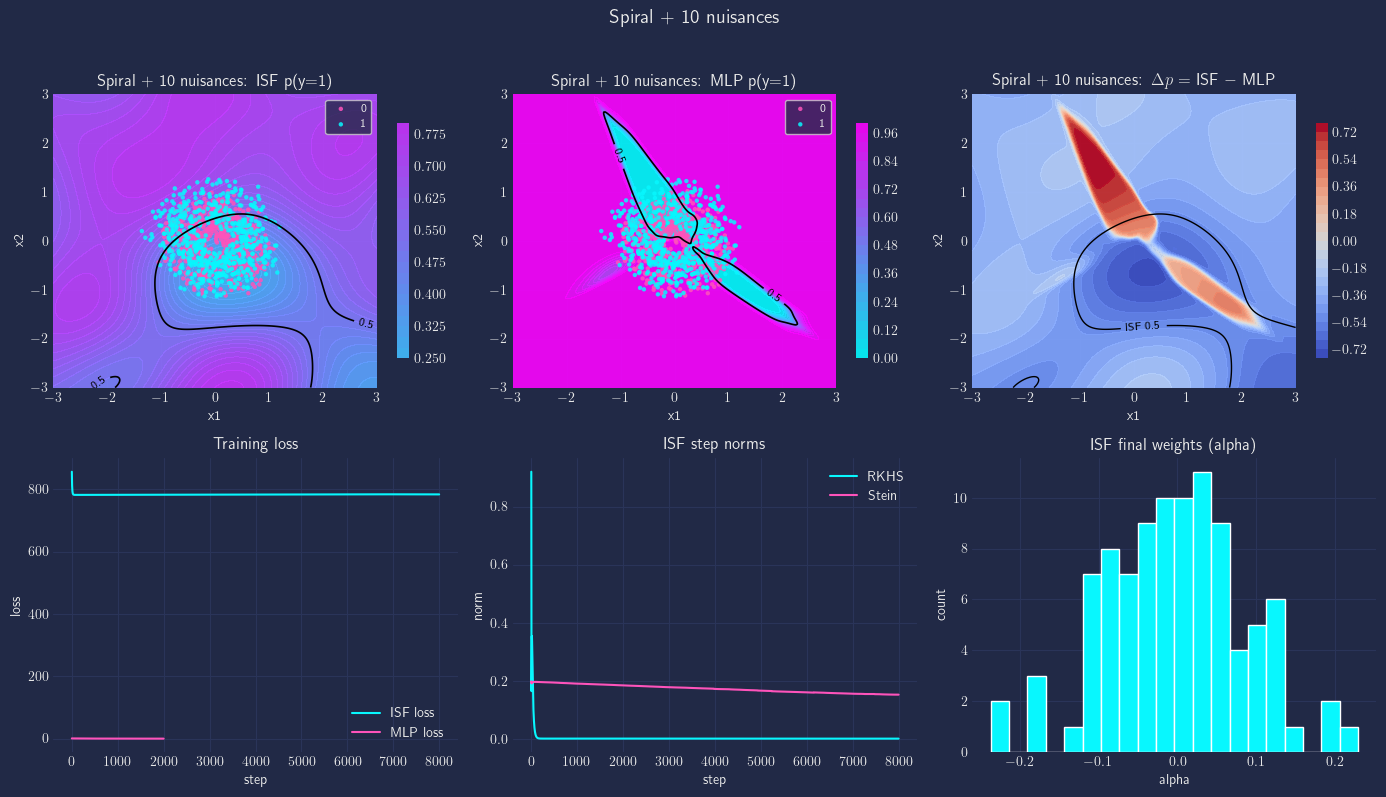

In [17]:
# After you've trained ISF and MLP and computed metrics / mlp_hist:
plot_isf_vs_mlp_onefig(
    predictor=predictor,       # the high-D predictor on data_hd
    Qhat=Qhat,                 # ISF result
    mlp_params=mlp_params,     # trained MLP
    data2d=data2d,             # original 2D dataset for scatter
    grid_lim=3.0,
    grid_n=250,
    metrics=metrics,           # ISF metrics dict (optional)
    mlp_hist=mlp_hist,         # MLP training loss (optional)
    title_prefix="Spiral + 10 nuisances"
)


## Audio Denoising

In [2]:
from vgd.audio import *

In [40]:
import jax, jax.numpy as jnp
import numpy as np



import jax, jax.numpy as jnp
import numpy as np

# ---------- helpers (unchanged except WOLA already fixed) ----------

def hann_window(N: int) -> jnp.ndarray:
    n = jnp.arange(N, dtype=jnp.float32)
    return 0.5 - 0.5 * jnp.cos(2*jnp.pi*n/(N-1))

def frame_signal(y: jnp.ndarray, frame_len: int, hop: int, pad_end: bool = True):
    N = int(y.shape[0])
    if N <= frame_len:
        pad = frame_len - N if pad_end else 0
        y_pad = jnp.pad(y, (0, pad))
        return y_pad[None, :], N

    if pad_end:
        n_steps = (N - frame_len + hop - 1) // hop + 1
        total = hop * (n_steps - 1) + frame_len
        pad = max(0, total - N)
    else:
        n_steps = (N - frame_len) // hop + 1
        pad = 0

    y_pad = jnp.pad(y, (0, pad))
    idx = jnp.arange(frame_len)[None, :] + hop * jnp.arange(n_steps)[:, None]
    frames = y_pad[idx]  # (T, L)
    return frames, N

def overlap_add(frames: jnp.ndarray, hop: int, window: jnp.ndarray, N_trim: int | None = None):
    T, L = frames.shape
    total = hop * (T - 1) + L
    y = jnp.zeros((total,), dtype=frames.dtype)
    wsum = jnp.zeros((total,), dtype=frames.dtype)
    for t in range(T):
        start = t * hop
        seg = frames[t] * window
        y = y.at[start:start+L].add(seg)
        # WOLA: sum window^2
        wsum = wsum.at[start:start+L].add(window * window)

    if N_trim is not None:
        y = y[:N_trim]
        wsum = wsum[:N_trim]

    wsum = jnp.where(wsum > 1e-12, wsum, 1.0)
    return y / wsum

# ---------- minimal Gaussian prior for θ=(ω,b) ----------
class NormalDiag:
    """N(0, diag(sd^2)) score for θ. 'sd' can be scalar or per-dim array."""
    def __init__(self, sd=1.0):
        self.var = jnp.asarray(sd, dtype=jnp.float32) ** 2
    def grad_log_prob(self, theta: jnp.ndarray) -> jnp.ndarray:
        return -theta / self.var  # broadcasts

# ---------- denoiser with fixes ----------
def isf_denoise_audio(
    y_noisy: np.ndarray,
    sr: int = 16000,
    frame_len: int = 1024,
    hop: int = 512,
    n_particles: int = 64,
    steps: int = 200,
    eps_theta: float = 2e-3,
    eps_alpha: float = 2e-4,
    lambda_skl: float = 0.3,
    w_scale: float = 8.0,        # std of ω in "harmonic index" units (normalized time)
    alpha_scale: float = 0.02,
    kernel=None,
    kparams=None,
    step_clip: float = 0.05,     # pass through to ISF to keep θ updates bounded
) -> dict:
    """
    per-frame ISF denoiser using normalized time t = 2π n / L (ω ~ harmonic index).
    Requires: SignedMixtureLike, FourierPredictor, ISFLoss, isf(), RBFKernel, KernelParams.
    """
    # --- dtype unification ---
    y_noisy = np.asarray(y_noisy, dtype=np.float32)
    y = jnp.asarray(y_noisy)  # (N,)

    # --- framing ---
    win = hann_window(frame_len)                              # (L,)
    frames, N_orig = frame_signal(y, frame_len, hop, True)    # (T, L)
    T, L = frames.shape

    # --- normalized time axis in radians: t = 2π n / L ---
    two_pi_over_L = jnp.asarray(2 * np.pi / L, dtype=jnp.float32)
    t = two_pi_over_L * jnp.arange(L, dtype=jnp.float32)      # (L,)
    X_frame = t[:, None]                                      # (L,1)

    # --- priors (loose on phase b) ---
    # sd per-dim: [sd_ω, sd_b]; keep phase wide so SKL doesn't clamp b
    prior = NormalDiag(sd=jnp.array([6.0, 50.0], dtype=jnp.float32))

    # --- particle init for θ=(ω,b) ---
    def init_fourier_particles_1d(n_particles, key):
        k1, k2, k3 = jax.random.split(key, 3)
        omega = jax.random.normal(k1, (n_particles, 1), dtype=jnp.float32) * w_scale
        b     = jax.random.uniform(k2, (n_particles, 1), minval=0., maxval=2*jnp.pi, dtype=jnp.float32)
        particles = jnp.concatenate([omega, b], axis=1)                # (n,2)
        alpha = jax.random.normal(k3, (n_particles,), dtype=jnp.float32) * alpha_scale
        return SignedMixtureLike(particles=particles, alpha=alpha)

    # --- loss (squared) ---
    loss = ISFDeterministicRiskLoss(loss_and_grad=squared_loss_and_grad)

    # --- kernel defaults / anisotropy (optional) ---
    if kernel is None:
        kernel = RBFKernel()
    if kparams is None:
        # If your kernel supports vector lengthscales, consider: lengthscale=[4.0, 2π]
        kparams = KernelParams(lengthscale=jnp.asarray(1.0, dtype=jnp.float32),
                               amplitude=jnp.asarray(1.0, dtype=jnp.float32))

    frames_pred = []
    Q_last = None
    key = jax.random.PRNGKey(0)

    for t_idx in range(T):
        key, kq = jax.random.split(key)
        # analysis windowing
        y_frame = frames[t_idx] * win  # (L,)
        # per-frame RMS normalisation for stability
        eps = jnp.asarray(1e-6, dtype=jnp.float32)
        rms = jnp.sqrt(jnp.mean(y_frame**2) + eps)
        y_fit = y_frame / jnp.maximum(rms, eps)

        data = {"x": X_frame, "y": y_fit}
        Q0 = init_fourier_particles_1d(n_particles, kq) if Q_last is None else Q_last

        predictor = FourierPredictor(
            prior_plus=prior, prior_minus=prior, data=data, x_key="x", y_key="y"
        )

        # run ISF (ensure your 'isf' accepts step_clip and forwards it)
        Qhat, _ = isf(
            model=predictor, loss=loss, kernel=kernel, kparams=kparams,
            eps_theta=eps_theta, eps_alpha=eps_alpha, lambda_skl=lambda_skl,
            Q0=Q0, steps=steps, step_clip=step_clip, return_metrics=False
        )

        # predict and undo RMS scaling
        yhat = predictor.predict(Qhat) * rms
        frames_pred.append(yhat)
        Q_last = Qhat  # warm-start next frame

    frames_pred = jnp.stack(frames_pred, axis=0)  # (T, L)
    y_denoised = overlap_add(frames_pred, hop=hop, window=win, N_trim=int(N_orig))

    return {
        "denoised": np.asarray(y_denoised),
        "frames_pred": np.asarray(frames_pred),
        "Q_last": Q_last,
    }



# --- make a synthetic 2-second signal ---
sr = 16000
t = np.arange(sr*2) / sr
# sparse, time-varying spectrum (two tones + one slowly sweeping chirp)
clean = (0.6*np.sin(2*np.pi*220*t)
         + 0.3*np.sin(2*np.pi*440*t + 0.5)
         + 0.2*np.sin(2*np.pi*(200 + 100*t)*t))
# add white noise at ~0 dB SNR
rng = np.random.default_rng(0)
noise = 0.8 * rng.standard_normal(clean.shape)
noisy = clean + noise

print("Noisy SNR:", snr_db(clean, noisy))

# --- run ISF denoiser ---
res = isf_denoise_audio(
    y_noisy=noisy, sr=sr,
    frame_len=1024, hop=1024,
    n_particles=64, steps=50,            
    eps_theta=2e-4, eps_alpha=1e-4,
    lambda_skl=0.0,
    w_scale=2.0, alpha_scale=0.02,
    kernel=RBFKernel(),
    kparams=KernelParams(lengthscale=jnp.asarray(1.0), amplitude=jnp.asarray(1.0)),
    step_clip=0.05,
)
den = res["denoised"]
print("Denoised SNR:", snr_db(clean, den))

# --- listen (in a notebook) ---
play_audio(noisy, sr)
play_audio(den,   sr)

# --- optionally save to WAVs ---
# save_wav("noisy.wav", noisy, sr)
# save_wav("denoised_isf.wav", den, sr)


Noisy SNR: -4.0557667536279824
Denoised SNR: -45.71340150554494


In [16]:
den

array([ 0.        , -0.00032849, -0.00034991, ...,  0.00054257,
        0.00053545,  0.00052833])

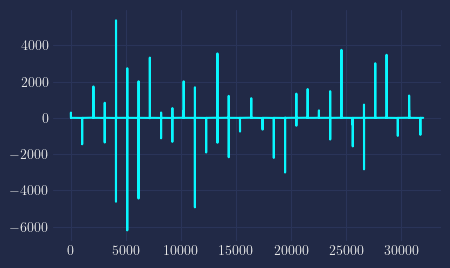

In [41]:
plt.plot(den)
# plt.plot(clean)

In [15]:
play_audio(clean, sr)


In [ ]:
import jax, jax.numpy as jnp
from dataclasses import dataclass
from typing import Any, Optional
KeyArray = jax.Array

# ----- Helper: ridge solve for alpha given fixed Xi, phi -----
def solve_alpha_ridge(Phi_n_by_N, y, lam=1e-3):
    """
    Solve: min_alpha ||Phi^T alpha - y||^2 + lam ||alpha||^2
    where Phi is (n, N), y is (N,), returning alpha (n,).
    """
    # (n, n) system: (Phi Phi^T + lam I) alpha = Phi y
    A = Phi_n_by_N @ Phi_n_by_N.T + lam * jnp.eye(Phi_n_by_N.shape[0])
    b = Phi_n_by_N @ y
    return jnp.linalg.solve(A, b)

# ----- Example 0: tiny utility to encode a base-p path -> integer -----
def encode_base_p_path(digits, p, m):
    """
    digits: list/array of digits in {0,...,p-1}, length <= m
    returns integer in [0, p^m - 1] equal to sum_{k=0}^{L-1} digits[k] * p^k
    """
    L = len(digits)
    if L > m:
        raise ValueError("path longer than m")
    coefs = (jnp.array(digits, dtype=jnp.int64) * (p ** jnp.arange(L, dtype=jnp.int64))).sum()
    return int(coefs)

# ================================
# Synthetic data generators
# ================================
def make_p_adic_regression_data_1d(p=5, m=4, N=512, key: KeyArray=jax.random.PRNGKey(0)):
    """
    One-dimensional X uniform in {0,...,M-1}, y from a few true p-adic characters + noise.
    """
    M = p ** m
    k1, k2, k3 = jax.random.split(key, 3)

    # X ~ Haar on Z_p mod p^m => uniform residues
    X = jax.random.randint(k1, shape=(N,), minval=0, maxval=M).astype(jnp.int64)

    # Ground-truth mixture: choose a few divisibility scales r so frequencies are p^r-multiples
    # (low frequencies correspond to large r)
    Xi_true = jnp.array([
        0 * jnp.ones((), dtype=jnp.int64) + (p ** 0) * 7,   # high-ish frequency
        0 * jnp.ones((), dtype=jnp.int64) + (p ** 1) * 3,   # lower frequency
        0 * jnp.ones((), dtype=jnp.int64) + (p ** 2) * 1,   # even lower
    ], dtype=jnp.int64) % M  # (n_true,)

    phi_true = jnp.array([0.0, 3.0, 8.0])  # phases in [0,M), interpreted real then mod M
    alpha_true = jnp.array([1.2, -0.8, 0.5])

    # Build characters and signal
    # chi_{xi}(x) = exp(2πi (x*xi + phi)/M); we use the cosine (real part)
    Tphi = (X[:, None] * Xi_true[None, :] + phi_true[None, :]) % M  # (N, n_true)
    ang = (2.0 * jnp.pi / M) * Tphi
    Phi_true = jnp.cos(ang)  # (N, n_true)
    y_clean = (Phi_true @ alpha_true).reshape(-1)

    # Add a bit of Gaussian noise
    noise = 0.1 * jax.random.normal(k2, shape=(N,))
    y = y_clean + noise
    return X, y, dict(Xi_true=Xi_true, phi_true=phi_true, alpha_true=alpha_true, M=M)

def make_p_adic_regression_data_2d(p=3, m=4, N=1024, key: KeyArray=jax.random.PRNGKey(1)):
    """
    Two-dimensional X, each coordinate uniform in {0,...,M-1}.
    True signal uses a few multi-scale vector frequencies Xi in (Z/p^mZ)^2.
    """
    M = p ** m
    k1, k2 = jax.random.split(key, 2)
    X = jax.random.randint(k1, shape=(N, 2), minval=0, maxval=M).astype(jnp.int64)

    # A few vector frequencies with different divisibility scales across coords
    Xi_true = jnp.array([
        [ (p ** 0) * 2,  (p ** 2) * 1 ],   # mix of high/low scale
        [ (p ** 1) * 1,  (p ** 1) * 4 ],
        [ (p ** 0) * 7,  (p ** 0) * 5 ],
    ], dtype=jnp.int64) % M  # (n_true, 2)

    phi_true = jnp.array([0.0, 5.0, 11.0])
    alpha_true = jnp.array([0.9, -0.6, 0.8])

    # Build features
    T = (X[:, None, :] * Xi_true[None, :, :]) % M  # (N, n_true, 2)
    T = (T.sum(axis=-1) + phi_true[None, :]) % M   # (N, n_true)
    ang = (2.0 * jnp.pi / M) * T
    Phi_true = jnp.cos(ang)                         # (N, n_true)
    y_clean = (Phi_true @ alpha_true).reshape(-1)

    noise = 0.1 * jax.random.normal(k2, shape=(N,))
    y = y_clean + noise
    return X, y, dict(Xi_true=Xi_true, phi_true=phi_true, alpha_true=alpha_true, M=M)

# ================================
# Minimal fit using your Predictor
# ================================
@jax.tree_util.register_pytree_node_class
@dataclass
class PAdicMixtureLike:
    Xi: jax.Array  # (n,d) int64 in [0, M-1]
    phi: jax.Array # (n,) real phases (mod M on eval)
    alpha: jax.Array  # (n,) real weights
    def replace_particles(self, new_Xi):   return PAdicMixtureLike(new_Xi, self.phi, self.alpha)
    def replace_alpha(self, new_alpha):    return PAdicMixtureLike(self.Xi, self.phi, new_alpha)
    def replace_phi(self, new_phi):        return PAdicMixtureLike(self.Xi, new_phi, self.alpha)
    def sign_masks(self):
        m_plus  = (self.alpha > 0.0)
        m_minus = (self.alpha < 0.0)
        return m_plus, m_minus
    def per_sign_weights(self, normalise: bool = True, eps: float = 1e-12):
        a = self.alpha
        a_plus  = jnp.where(a > 0,  a, 0.0)
        a_minus = jnp.where(a < 0, -a, 0.0)
        if normalise:
            m_plus  = jnp.sum(a_plus)  + eps
            m_minus = jnp.sum(a_minus) + eps
            w_plus  = a_plus  / m_plus
            w_minus = a_minus / m_minus
        else:
            w_plus, w_minus = a_plus, a_minus
        return w_plus, w_minus
    # pytree plumbing
    def tree_flatten(self): return (self.Xi, self.phi, self.alpha), None
    @classmethod
    def tree_unflatten(cls, aux, children):
        Xi, phi, alpha = children
        return cls(Xi=Xi, phi=phi, alpha=alpha)


@dataclass
class PAdicFourierPredictor:
    p: int
    m: int
    data: Any
    x_key: str = "x"
    y_key: str = "y"
    use_sin: bool = True

    def set_data(self, data: Any): self.data = data; return self
    def modulus(self) -> int: return int(self.p ** self.m)
    def n(self) -> int: return int(jnp.asarray(self._X()).shape[0])

    def _X(self) -> jnp.ndarray:
        X = jnp.asarray(self.data[self.x_key])
        if X.ndim == 1:
            X = X[:, None]
        return X.astype(jnp.int64)

    def _mod_inner(self, X: jnp.ndarray, Xi: jnp.ndarray) -> jnp.ndarray:
        M = self.modulus()
        prod = (X[:, None, :] * Xi[None, :, :]) % M
        return jnp.sum(prod, axis=-1) % M  # (N,n)

    def _angle(self, Q: PAdicMixtureLike, X: jnp.ndarray) -> jnp.ndarray:
        M = self.modulus()
        T = self._mod_inner(X.astype(jnp.int64), Q.Xi.astype(jnp.int64))  # (N,n)
        phase = jnp.mod(Q.phi, M)
        Tphi = (T + phase[None, :]) % M
        return (2.0 * jnp.pi / M) * Tphi

    def features_pointwise(self, Q: PAdicMixtureLike) -> jnp.ndarray:
        X = self._X()
        ang = self._angle(Q, X)
        C = jnp.cos(ang)
        if not self.use_sin:
            return C.T  # (n,N)
        S = jnp.sin(ang)
        return jnp.concatenate([C, S], axis=1).T  # (2n,N)

    def dfeatures_pointwise(self, Q: PAdicMixtureLike) -> jnp.ndarray:
        X = self._X()
        ang = self._angle(Q, X)
        M = self.modulus()
        scale = 2.0 * jnp.pi / M
        if not self.use_sin:
            return (-jnp.sin(ang) * scale).T[:, :, None]  # (n,N,1)
        dcos = (-jnp.sin(ang) * scale).T[:, :, None]
        dsin = ( jnp.cos(ang) * scale).T[:, :, None]
        return jnp.concatenate([dcos, dsin], axis=0)

    def predict(self, Q: PAdicMixtureLike) -> jnp.ndarray:
        Phi = self.features_pointwise(Q)  # (n or 2n, N)
        return (Phi.T @ Q.alpha).reshape(-1)

    def predict_on_x(self, Q: PAdicMixtureLike, X: jnp.ndarray) -> jnp.ndarray:
        X = jnp.asarray(X)
        if X.ndim == 1: X = X[:, None]
        ang = self._angle(Q, X.astype(jnp.int64))
        C = jnp.cos(ang)
        feats = C if not self.use_sin else jnp.concatenate([C, jnp.sin(ang)], axis=1)
        return (feats @ Q.alpha).reshape(-1)

    # frequency sampler (multi-scale)
    def sample_frequencies(self, n: int, d: int, key: KeyArray,
                           min_scale: int = 0, max_scale: Optional[int] = None) -> jnp.ndarray:
        M = self.modulus()
        rmax = self.m - 1 if max_scale is None else int(max_scale)
        if not (0 <= min_scale <= rmax <= self.m - 1):
            raise ValueError("Require 0 <= min_scale <= rmax <= m-1.")
        k1, k2, k3 = jax.random.split(key, 3)
        r = jax.random.randint(k1, shape=(n, d), minval=min_scale, maxval=rmax + 1)
        base = jax.random.randint(k2, shape=(n, d), minval=0, maxval=self.p ** (self.m - r))
        Xi = (base * (self.p ** r)).astype(jnp.int64) % M
        # avoid all-zero rows (optional)
        all_zero = jnp.all(Xi == 0, axis=1, keepdims=True)
        Xi = jnp.where(all_zero, jax.random.randint(k3, (n, d), 0, M), Xi)
        return Xi

# ================================
# Demo 1: 1-D data and fit
# ================================
def demo_1d():
    p, m = 5, 4
    X, y, truth = make_p_adic_regression_data_1d(p=p, m=m, N=600, key=jax.random.PRNGKey(42))
    predictor = PAdicFourierPredictor(p=p, m=m, data={"x": X, "y": y})

    # Initialise particles
    n = 64
    Xi0 = predictor.sample_frequencies(n=n, d=1, key=jax.random.PRNGKey(0),
                                       min_scale=0, max_scale=m-1)
    phi0 = jnp.zeros((n,), dtype=jnp.float32)  # relaxed phases; can randomise if you like
    alpha0 = jnp.zeros((n,), dtype=jnp.float32)

    Q = PAdicMixtureLike(Xi=Xi0, phi=phi0, alpha=alpha0)

    # Ridge-fit alpha with fixed Xi, phi
    Phi = predictor.features_pointwise(Q)  # (n, N)
    alpha_hat = solve_alpha_ridge(Phi, y, lam=1e-2)
    Q = Q.replace_alpha(alpha_hat)

    # Evaluate
    y_pred = predictor.predict(Q)
    mse = jnp.mean((y_pred - y) ** 2)
    print(f"[1D] M={p**m}, n={n}, ridge MSE: {float(mse):.4f}")

    # Optional: one gradient step on phases (keeping alpha fixed)
    # d/dphi loss ~ (Phi^T alpha - y) dotted with dPhi/dphi * alpha
    dPhi_dphi = predictor.dfeatures_pointwise(Q).squeeze(-1)  # (n, N)
    resid = (Phi.T @ Q.alpha) - y  # (N,)
    # chain rule: grad_phi_j = sum_i resid_i * dPhi_{j,i} * alpha_j
    grad_phi = (dPhi_dphi * resid[None, :]).sum(axis=1) * Q.alpha
    phi_new = Q.phi - 1e-1 * grad_phi  # small step
    Q = Q.replace_phi(phi_new)

    # Refit alpha after changing phi (purely illustrative)
    Phi = predictor.features_pointwise(Q)
    alpha_hat = solve_alpha_ridge(Phi, y, lam=1e-2)
    Q = Q.replace_alpha(alpha_hat)
    mse2 = jnp.mean((predictor.predict(Q) - y) ** 2)
    print(f"[1D] After one phi step + refit alpha, MSE: {float(mse2):.4f}")

    return X, y, Q, truth

# ================================
# Demo 2: 2-D data and fit
# ================================
def demo_2d():
    p, m = 3, 4
    X, y, truth = make_p_adic_regression_data_2d(p=p, m=m, N=1500, key=jax.random.PRNGKey(7))
    predictor = PAdicFourierPredictor(p=p, m=m, data={"x": X, "y": y})

    n = 96
    Xi0 = predictor.sample_frequencies(n=n, d=2, key=jax.random.PRNGKey(9),
                                       min_scale=0, max_scale=m-1)
    phi0 = jnp.zeros((n,), dtype=jnp.float32)
    alpha0 = jnp.zeros((n,), dtype=jnp.float32)
    Q = PAdicMixtureLike(Xi=Xi0, phi=phi0, alpha=alpha0)

    Phi = predictor.features_pointwise(Q)   # (n, N)
    alpha_hat = solve_alpha_ridge(Phi, y, lam=2e-2)
    Q = Q.replace_alpha(alpha_hat)

    mse = jnp.mean((predictor.predict(Q) - y) ** 2)
    print(f"[2D] M={p**m}, n={n}, ridge MSE: {float(mse):.4f}")
    return X, y, Q, truth

# ================================
# Bonus: base-p paths (p=2) -> 1D index
# ================================
def example_binary_tree_paths():
    p, m = 2, 8
    # three binary paths of different depths
    paths = [
        [1,0,1,1],     # depth 4
        [0,1,1],       # depth 3
        [1,1,1,0,0,1]  # depth 6
    ]
    xs = jnp.array([encode_base_p_path(d, p, m) for d in paths], dtype=jnp.int64)
    print(f"[paths->index] p={p}, m={m}, xs={xs.tolist()}")

_ = demo_1d()
_ = demo_2d()
example_binary_tree_paths()


[1D] M=625, n=64, ridge MSE: 0.9632
[1D] After one phi step + refit alpha, MSE: 0.9632
[2D] M=81, n=96, ridge MSE: 0.8694
[paths->index] p=2, m=8, xs=[13, 6, 39]


In [70]:
def plot_1d_fit(X, y, Q, predictor, topk_amplitudes=None):
    """
    One figure with:
      (1) noisy y and prediction vs x (sorted),
      (2) residuals vs x,
      (3) per-frequency amplitudes (if use_sin=True) or raw alphas (if cos-only).

    Args:
      topk_amplitudes: if not None and use_sin=True, show only the top-K amplitudes for readability.
    """
    # ----- Sort x for clean curves -----
    x = np.asarray(X).reshape(-1)
    y_np = np.asarray(y).reshape(-1)
    order_x = np.argsort(x)
    x_sorted = x[order_x]
    y_sorted = y_np[order_x]

    # Prediction on sorted x
    yhat_sorted = np.asarray(predictor.predict_on_x(Q, x_sorted))

    # Residuals
    resid = y_sorted - yhat_sorted

    # ----- Coefficients / amplitudes -----
    Xi = np.asarray(Q.Xi).reshape(-1)         # (n,)
    alpha = np.asarray(Q.alpha).reshape(-1)   # (n,) or (2n,)
    order_k = np.argsort(Xi)
    Xi_sorted = Xi[order_k]

    if getattr(predictor, "use_sin", False):
        n = Xi.shape[0]
        alpha_cos_sorted = alpha[:n][order_k]
        alpha_sin_sorted = alpha[n:][order_k]
        # Amplitude per frequency: a cos + b sin = R cos(· - φ), R = sqrt(a^2+b^2)
        amps_sorted = np.sqrt(alpha_cos_sorted**2 + alpha_sin_sorted**2)
        bar_vals = amps_sorted
        bar_label = "amplitude per frequency"
    else:
        # Cos-only: just show |alpha|
        bar_vals = np.abs(alpha[order_k])
        bar_label = "|alpha| per frequency"

    # Optionally keep only top-K amplitudes for readability
    if topk_amplitudes is not None and getattr(predictor, "use_sin", False):
        k = int(topk_amplitudes)
        idx_top = np.argsort(bar_vals)[-k:]
        Xi_sorted = Xi_sorted[idx_top]
        bar_vals = bar_vals[idx_top]
        # sort by frequency for nicer x-axis
        srt = np.argsort(Xi_sorted)
        Xi_sorted = Xi_sorted[srt]
        bar_vals = bar_vals[srt]

    # ----- Plot: single figure with 3 subplots -----
    M = predictor.modulus()
    fig, axs = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

    # (1) y and yhat vs x
    axs[0].scatter(x_sorted, y_sorted, s=10, alpha=0.6, label="y (noisy)")
    axs[0].plot(x_sorted, yhat_sorted, lw=2, label="prediction")
    axs[0].set_xlabel(r"$x \;(\mathrm{mod}\; p^m)$")
    axs[0].set_ylabel("signal")
    axs[0].set_title("Noisy target and fitted prediction")
    axs[0].legend()

    # (2) residuals vs x
    axs[1].scatter(x_sorted, resid, s=10, alpha=0.7)
    axs[1].axhline(0.0, color="k", ls="--", lw=1)
    axs[1].set_xlabel(r"$x \;(\mathrm{mod}\; p^m)$")
    axs[1].set_ylabel("residual (y - yhat)")
    axs[1].set_title("Residuals")

    # (3) amplitudes / |alpha| vs frequency index (sorted by Xi)
    # Use frequency labels sparingly to avoid clutter
    xs = np.arange(len(Xi_sorted))
    axs[2].bar(xs, bar_vals, width=0.9)
    axs[2].set_xlabel("frequencies (sorted $k$)")
    axs[2].set_ylabel(bar_label)
    axs[2].set_title(f"Coefficients over frequencies (M={M})")

    # Show a few tick labels with actual k's to orient the axis
    if len(Xi_sorted) > 0:
        tick_step = max(1, len(Xi_sorted)//10)
        sel = np.arange(0, len(Xi_sorted), tick_step)
        axs[2].set_xticks(sel)
        axs[2].set_xticklabels([str(int(k)) for k in Xi_sorted[sel]], rotation=45, ha="right")

    plt.show()


In [ ]:
import math
from collections import defaultdict, Counter
import numpy as np
import matplotlib.pyplot as plt

try:
    import jax
    import jax.numpy as jnp
except Exception:
    jax = None
    jnp = None


def base_p_digits_least_first(n: int, p: int, m: int):
    """Return the least-significant-first base-p digits of n modulo p^m, length m."""
    digits = []
    for _ in range(m):
        digits.append(n % p)
        n //= p
    return digits  # [d0 (units), d1, ..., d{m-1}]


def build_tree_positions(p: int, m: int):
    """
    Build deterministic (x, y) positions for each prefix node at each depth k=0..m.
    Returns:
      pos: dict mapping prefix tuple (d0,...,d_{k-1}) to (x, y)
      parent: dict mapping child_prefix -> parent_prefix (for drawing edges)
    """
    pos = {}
    parent = {}

    # Root
    pos[tuple()] = (0.5, 1.0)  # center top
    # Levels k=1..m
    for k in range(1, m + 1):
        num_nodes = p ** k
        # Evenly spaced x positions across [0,1]
        xs = (np.arange(num_nodes) + 0.5) / num_nodes
        y = 1.0 - k / (m + 0.3)  # spread a bit; constant controls vertical spacing

        # enumerate prefixes in lex order over least-first digits
        # i.e., (d0,...,d{k-1}) where d0 is fastest varying
        for idx in range(num_nodes):
            # decode idx to base-p vector of length k, least-first
            digits = []
            t = idx
            for _ in range(k):
                digits.append(t % p)
                t //= p
            prefix = tuple(digits)
            pos[prefix] = (float(xs[idx]), float(y))
            parent[prefix] = tuple(digits[:-1])
    return pos, parent


def aggregate_leaf_stats(X: np.ndarray, y: np.ndarray, p: int, m: int):
    """
    Aggregate statistics for each residue class (leaf): mean y and count.
    Returns dict leaf_prefix -> dict(mean=..., count=..., xs=..., ys=...).
    """
    assert X.ndim == 1 and y.ndim == 1 and X.shape[0] == y.shape[0]
    M = p ** m
    # Reduce X modulo M just in case
    X_mod = np.asarray(X, dtype=np.int64) % M
    y = np.asarray(y, dtype=float)

    by_leaf = defaultdict(list)
    for xi, yi in zip(X_mod, y):
        digits = base_p_digits_least_first(int(xi), p, m)
        leaf = tuple(digits)  # full length m
        by_leaf[leaf].append(yi)

    stats = {}
    for leaf, ys in by_leaf.items():
        ys_arr = np.asarray(ys)
        stats[leaf] = {
            "mean": float(ys_arr.mean()),
            "count": int(len(ys_arr)),
        }
    return stats


def plot_p_adic_tree(X: np.ndarray, y: np.ndarray, p: int, m: int, title=None):
    pos, parent = build_tree_positions(p, m)
    stats = aggregate_leaf_stats(X, y, p, m)

    # Draw edges
    fig = plt.figure(figsize=(10, 7))
    ax = plt.gca()
    for child, par in parent.items():
        x0, y0 = pos[par]
        x1, y1 = pos[child]
        ax.plot([x0, x1], [y0, y1], linewidth=0.8, alpha=0.5)

    # Draw internal nodes (small, light)
    for prefix, (x, yy) in pos.items():
        if len(prefix) < m:
            ax.scatter([x], [yy], s=10, alpha=0.5)

    # Draw leaves with size ~ count and color ~ mean y
    leaf_x = []
    leaf_y = []
    leaf_sizes = []
    leaf_colors = []
    for prefix, (x, yy) in pos.items():
        if len(prefix) == m:
            leaf_x.append(x)
            leaf_y.append(yy)
            st = stats.get(prefix, {"mean": np.nan, "count": 0})
            leaf_colors.append(st["mean"])
            # size scaling
            leaf_sizes.append(20 + 80 * math.sqrt(st["count"]))

    sc = ax.scatter(leaf_x, leaf_y, s=leaf_sizes, c=leaf_colors, edgecolors="none")
    cb = plt.colorbar(sc, ax=ax)
    cb.set_label("mean y at residue ($mod p^m$)")

    # Decorate
    ax.set_xticks([])
    ax.set_yticks([])
    if title is None:
        title = f"p-adic tree (p={p}, m={m}) with leaf color = mean(y), size = count"
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

    # Also provide a small table of the top-k leaves by count for reference
    # Build a dataframe-like dict and show a preview
    import pandas as pd
    rows = []
    for leaf, st in stats.items():
        # encode leaf as an integer residue for readability
        n = sum(int(leaf[k]) * (p ** k) for k in range(m))
        rows.append({"residue": n, "digits_least_first": leaf, "count": st["count"], "mean_y": st["mean"]})
    df = pd.DataFrame(rows).sort_values(["count", "residue"], ascending=[False, True]).reset_index(drop=True)


    return df


def base_p_digits_least_first(n: int, p: int, m: int):
    """Return the least-significant-first base-p digits of n modulo p^m, length m."""
    digits = []
    for _ in range(m):
        digits.append(n % p)
        n //= p
    return digits  # [d0 (units), d1, ..., d{m-1}]

def build_tree_positions(p: int, m: int):
    """
    Build deterministic (x, y) positions for each prefix node at each depth k=0..m.
    Returns:
      pos: dict mapping prefix tuple (d0,...,d_{k-1}) to (x, y)
      parent: dict mapping child_prefix -> parent_prefix (for drawing edges)
    """
    pos = {}
    parent = {}
    pos[tuple()] = (0.5, 1.0)  # root at top center
    for k in range(1, m + 1):
        num_nodes = p ** k
        xs = (np.arange(num_nodes) + 0.5) / num_nodes
        y = 1.0 - k / (m + 0.3)
        for idx in range(num_nodes):
            # decode idx to base-p vector of length k, least-first
            digits = []
            t = idx
            for _ in range(k):
                digits.append(t % p)
                t //= p
            prefix = tuple(digits)
            pos[prefix] = (float(xs[idx]), float(y))
            parent[prefix] = tuple(digits[:-1])
    return pos, parent

def aggregate_leaf_stats(X: np.ndarray, vals: np.ndarray, p: int, m: int):
    """
    Aggregate 'vals' for each residue class (leaf) seen in X.
    Returns dict leaf_prefix -> dict(mean=..., count=...).
    """
    assert X.ndim == 1 and vals.ndim == 1 and X.shape[0] == vals.shape[0]
    M = p ** m
    X_mod = np.asarray(X, dtype=np.int64) % M
    vals = np.asarray(vals, dtype=float)

    by_leaf = defaultdict(list)
    for xi, vi in zip(X_mod, vals):
        digits = base_p_digits_least_first(int(xi), p, m)
        leaf = tuple(digits)
        by_leaf[leaf].append(vi)

    stats = {}
    for leaf, vs in by_leaf.items():
        arr = np.asarray(vs, float)
        stats[leaf] = {"mean": float(arr.mean()), "count": int(arr.size)}
    return stats

def plot_p_adic_tree_with_predictor(X: np.ndarray, y: np.ndarray, Q, predictor,
                                    p: int, m: int, title=None,
                                    cmap="viridis", diff_cmap="coolwarm",
                                    size_base=18.0, size_scale=70.0):
    """
    Draw three panels on one figure:
      (A) leaf color = mean(y),   size = count(X==leaf)
      (B) leaf color = mean(yhat), size = same counts as (A)
      (C) leaf color = mean(yhat) - mean(y), size = counts
    Only leaves that appear in X are emphasized (others are drawn tiny/transparent).

    Works for 1D residues (Z / p^m Z). For multi-D inputs, first encode indices.
    """
    # Positions and topology
    pos, parent = build_tree_positions(p, m)
    M = p ** m

    # Predict on the same sample support (so counts match)
    X = np.asarray(X).reshape(-1)
    y = np.asarray(y).reshape(-1)
    yhat = np.asarray(predictor.predict_on_x(Q, X)).reshape(-1)

    stats_y    = aggregate_leaf_stats(X, y,    p, m)
    stats_yhat = aggregate_leaf_stats(X, yhat, p, m)

    # Build per-leaf arrays (in fixed order across panels)
    leaves = [prefix for prefix in pos.keys() if len(prefix) == m]
    leaf_x = np.array([pos[L][0] for L in leaves])
    leaf_y = np.array([pos[L][1] for L in leaves])

    means_y = np.full(len(leaves), np.nan)
    means_h = np.full(len(leaves), np.nan)
    counts  = np.zeros(len(leaves), dtype=int)

    for i, L in enumerate(leaves):
        if L in stats_y:
            means_y[i] = stats_y[L]["mean"]
            counts[i]  = stats_y[L]["count"]
        if L in stats_yhat:
            means_h[i] = stats_yhat[L]["mean"]

    # Shared color scale for data & prediction
    vmin = np.nanmin(np.concatenate([means_y[~np.isnan(means_y)],
                                     means_h[~np.isnan(means_h)]])) if np.any(~np.isnan(means_y)) or np.any(~np.isnan(means_h)) else 0.0
    vmax = np.nanmax(np.concatenate([means_y[~np.isnan(means_y)],
                                     means_h[~np.isnan(means_h)]])) if np.any(~np.isnan(means_y)) or np.any(~np.isnan(means_h)) else 1.0
    # Diff panel symmetric around 0
    diffs = means_h - means_y
    dmax = np.nanmax(np.abs(diffs[~np.isnan(diffs)])) if np.any(~np.isnan(diffs)) else 1.0

    # Sizing: emphasize observed leaves
    sizes = size_base + size_scale * np.sqrt(np.maximum(counts, 0))
    sizes[np.where(counts == 0)] = 2.0  # tiny for unseen

    # --- plotting helpers ---
    def draw_edges(ax):
        for child, par in parent.items():
            x0, y0 = pos[par]
            x1, y1 = pos[child]
            ax.plot([x0, x1], [y0, y1], linewidth=0.6, alpha=0.35, color="gray")

    def draw_internals(ax):
        for prefix, (xx, yy) in pos.items():
            if len(prefix) < m:
                ax.scatter([xx], [yy], s=8, alpha=0.4, color="gray")

    def panel(ax, values, cbar_label, cm, vmin_, vmax_, title_):
        draw_edges(ax)
        draw_internals(ax)
        sc = ax.scatter(leaf_x, leaf_y, s=sizes, c=values, cmap=cm,
                        vmin=vmin_, vmax=vmax_, edgecolors="none")
        cb = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
        cb.set_label(cbar_label)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
        ax.set_title(title_)

    # --- figure ---
    if title is None:
        title = f"p-ary tree view (p={p}, m={m}) - data vs predictor and error"
    fig, axs = plt.subplots(1, 3, figsize=(16, 4.6), constrained_layout=True)
    fig.suptitle(title, y=1.03, fontsize=12)

    panel(axs[0], means_y, "mean $y$", cmap, vmin, vmax, "Data (mean at leaf)")
    panel(axs[1], means_h, "mean $\hat{y}$", cmap, vmin, vmax, "Prediction (mean at leaf)")
    panel(axs[2], diffs,   "$\hat{y}$ - y", diff_cmap, -dmax, dmax, "Error (prediction - data)")

    plt.show()




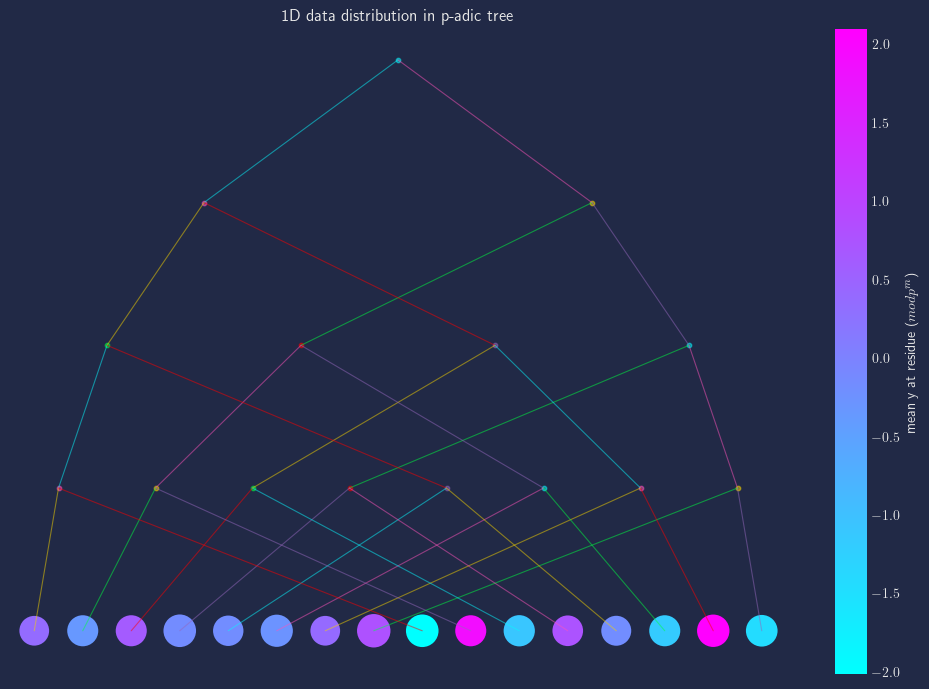

,residue,digits_least_first,count,mean_y
0,7,"(1, 1, 1, 0)",49,0.788230
1,3,"(1, 1, 0, 0)",44,-0.162539
2,8,"(0, 0, 0, 1)",44,-2.013208
3,14,"(0, 1, 1, 1)",43,2.091896
4,5,"(1, 0, 1, 0)",42,-0.270866
5,15,"(1, 1, 1, 1)",39,-1.443916
6,10,"(0, 1, 0, 1)",37,-1.088386
7,1,"(1, 0, 0, 0)",36,-0.359624
8,2,"(0, 1, 0, 0)",36,0.616842
9,9,"(1, 0, 0, 1)",36,1.873285


In [55]:
p, m = 2, 4

X, y, truth = make_p_adic_regression_data_1d(p=p, m=m, N=600, key=jax.random.PRNGKey(42))

plot_p_adic_tree(X, y, p, m, title="1D data distribution in p-adic tree")

[1D] M=8, k=8, cos+sin spectrum-init ridge MSE: 1.308472
[1D] M=8, k=8, cos+sin spectrum-init ridge MSE: 0.008831


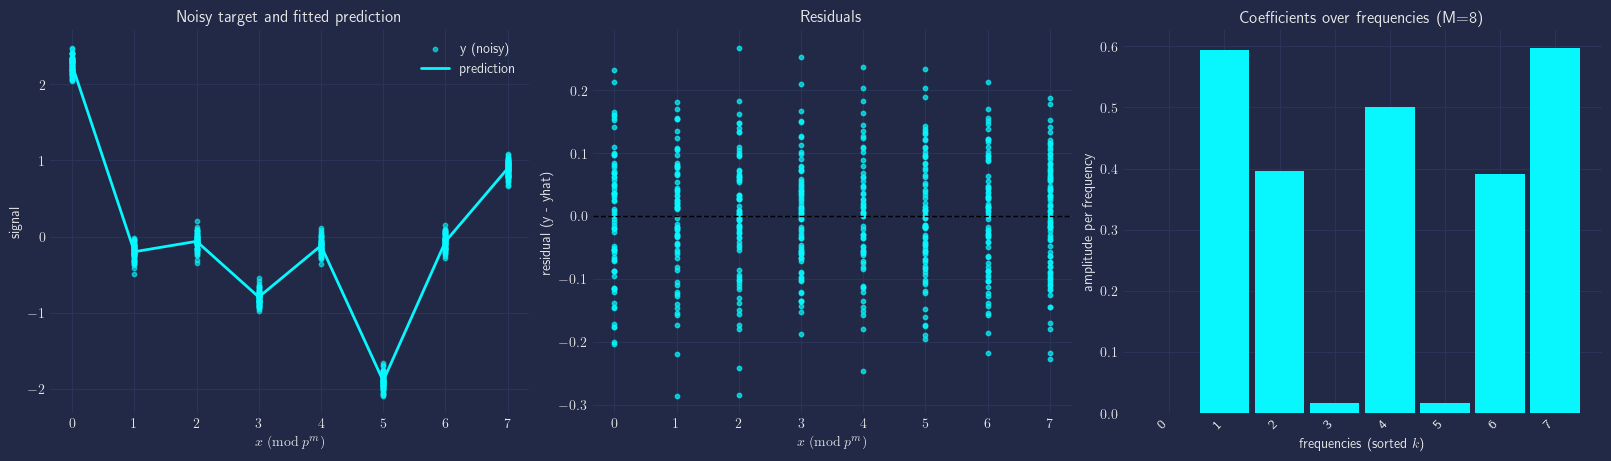

In [78]:
import jax, jax.numpy as jnp
from dataclasses import dataclass
from typing import Any, Optional
import numpy as np

KeyArray = jax.Array

# ----- Helper: ridge solve for alpha given fixed features -----
def solve_alpha_ridge(Phi_n_by_N, y, lam=1e-3):
    """
    Solve: min_alpha ||Phi^T alpha - y||^2 + lam ||alpha||^2
    where Phi is (n, N), y is (N,), returning alpha (n,).
    """
    A = Phi_n_by_N @ Phi_n_by_N.T + lam * jnp.eye(Phi_n_by_N.shape[0])
    b = Phi_n_by_N @ y
    return jnp.linalg.solve(A, b)

# Optional: profiled loss (not needed once we use cos+sin and good Xi)
def profiled_ridge_loss(phi, Q, predictor, lam):
    Qp = PAdicMixtureLike(Xi=Q.Xi, phi=phi, alpha=Q.alpha)
    Phi = predictor.features_pointwise(Qp)           # (n, N) or (2n, N)
    y   = predictor.data[predictor.y_key]            # (N,)
    A = Phi @ Phi.T + lam * jnp.eye(Phi.shape[0])
    b = Phi @ y
    alpha_star = jnp.linalg.solve(A, b)
    yhat = (Phi.T @ alpha_star).reshape(-1)
    loss = jnp.mean((yhat - y) ** 2)
    return loss, (alpha_star, yhat)

val_and_grad = jax.value_and_grad(lambda ph, Q, pr, lam:
                                  profiled_ridge_loss(ph, Q, pr, lam)[0])

# ================================
# Synthetic data generator (1D)
# ================================
def make_p_adic_regression_data_1d(p=5, m=4, N=512, key: KeyArray=jax.random.PRNGKey(0)):
    """
    One-dimensional X uniform in {0,...,M-1}, y from a few true p-adic characters + noise.
    """
    M = p ** m
    k1, k2, k3 = jax.random.split(key, 3)

    # X ~ Haar on Z_p mod p^m => uniform residues
    X = jax.random.randint(k1, shape=(N,), minval=0, maxval=M).astype(jnp.int64)

    # True mixture at low frequencies
    Xi_true = jnp.array([ (p ** 0) * 7,  (p ** 1) * 3,  (p ** 2) * 1 ], dtype=jnp.int64) % M  # (3,)
    phi_true   = jnp.array([0.0, 3.0, 8.0])  # phases in [0,M), interpreted as real
    alpha_true = jnp.array([1.2, -0.8, 0.5])

    # y = sum_j alpha_j cos(2π/M (Xi_j * X + phi_j)) + noise
    Tphi = (X[:, None] * Xi_true[None, :] + phi_true[None, :]) % M  # (N, 3)
    ang  = (2.0 * jnp.pi / M) * Tphi
    Phi_true = jnp.cos(ang)  # (N, 3)
    y_clean  = (Phi_true @ alpha_true).reshape(-1)

    noise = 0.1 * jax.random.normal(k2, shape=(N,))
    y = y_clean + noise
    return X, y, dict(Xi_true=Xi_true, phi_true=phi_true, alpha_true=alpha_true, M=M)

# ================================
# Model containers
# ================================
@jax.tree_util.register_pytree_node_class
@dataclass
class PAdicMixtureLike:
    Xi: jax.Array   # (n,d) int64 in [0, M-1]
    phi: jax.Array  # (n,)   real phases (unused when use_sin=True)
    alpha: jax.Array  # (n,) or (2n,) if cos+sin
    def replace_particles(self, new_Xi):   return PAdicMixtureLike(new_Xi, self.phi, self.alpha)
    def replace_alpha(self, new_alpha):    return PAdicMixtureLike(self.Xi, self.phi, new_alpha)
    def replace_phi(self, new_phi):        return PAdicMixtureLike(self.Xi, new_phi, self.alpha)
    def sign_masks(self):
        a = self.alpha
        return (a > 0.0), (a < 0.0)
    def per_sign_weights(self, normalise: bool = True, eps: float = 1e-12):
        a = self.alpha
        a_plus  = jnp.where(a > 0,  a, 0.0)
        a_minus = jnp.where(a < 0, -a, 0.0)
        if normalise:
            m_plus  = jnp.sum(a_plus)  + eps
            m_minus = jnp.sum(a_minus) + eps
            w_plus  = a_plus  / m_plus
            w_minus = a_minus / m_minus
        else:
            w_plus, w_minus = a_plus, a_minus
        return w_plus, w_minus
    # pytree plumbing
    def tree_flatten(self): return (self.Xi, self.phi, self.alpha), None
    @classmethod
    def tree_unflatten(cls, aux, children):
        Xi, phi, alpha = children
        return cls(Xi=Xi, phi=phi, alpha=alpha)

@dataclass
class PAdicFourierPredictor:
    p: int
    m: int
    data: Any
    x_key: str = "x"
    y_key: str = "y"
    use_sin: bool = True  # <-- default True: cos & sin features

    def set_data(self, data: Any): self.data = data; return self
    def modulus(self) -> int: return int(self.p ** self.m)
    def n(self) -> int: return int(jnp.asarray(self._X()).shape[0])

    def _X(self) -> jnp.ndarray:
        X = jnp.asarray(self.data[self.x_key])
        if X.ndim == 1:
            X = X[:, None]
        return X.astype(jnp.int64)

    def _mod_inner(self, X: jnp.ndarray, Xi: jnp.ndarray) -> jnp.ndarray:
        M = self.modulus()
        prod = (X[:, None, :] * Xi[None, :, :]) % M   # (N,n,d)
        return jnp.sum(prod, axis=-1) % M             # (N,n)

    def _angle(self, Q: PAdicMixtureLike, X: jnp.ndarray) -> jnp.ndarray:
        M = self.modulus()
        T = self._mod_inner(X.astype(jnp.int64), Q.Xi.astype(jnp.int64))  # (N,n)
        phase = Q.phi  # no modulus for differentiation; cos is periodic
        return (2.0 * jnp.pi / M) * (T + phase[None, :])

    def features_pointwise(self, Q: PAdicMixtureLike) -> jnp.ndarray:
        X = self._X()
        ang = self._angle(Q, X)    # (N,n)
        C = jnp.cos(ang)           # (N,n)
        if not self.use_sin:
            return C.T             # (n,N)
        S = jnp.sin(ang)           # (N,n)
        return jnp.concatenate([C, S], axis=1).T  # (2n, N)

    def predict(self, Q: PAdicMixtureLike) -> jnp.ndarray:
        Phi = self.features_pointwise(Q)     # (n or 2n, N)
        return (Phi.T @ Q.alpha).reshape(-1)

    def predict_on_x(self, Q: PAdicMixtureLike, X: jnp.ndarray) -> jnp.ndarray:
        X = jnp.asarray(X)
        if X.ndim == 1: X = X[:, None]
        ang = self._angle(Q, X.astype(jnp.int64))  # (N,n)
        C = jnp.cos(ang)
        feats = C if not self.use_sin else jnp.concatenate([C, jnp.sin(ang)], axis=1)
        return (feats @ Q.alpha).reshape(-1)

    def sample_frequencies(self, n: int, d: int, key: KeyArray,
                           min_scale: int = 0, max_scale: Optional[int] = None) -> jnp.ndarray:
        """(Kept for convenience; not used in the spectrum init path.)"""
        M = self.modulus()
        rmax = self.m - 1 if max_scale is None else int(max_scale)
        if not (0 <= min_scale <= rmax <= self.m - 1):
            raise ValueError("Require 0 <= min_scale <= rmax <= m-1.")
        k1, k2, k3 = jax.random.split(key, 3)
        r = jax.random.randint(k1, shape=(n, d), minval=min_scale, maxval=rmax + 1)
        base = jax.random.randint(k2, shape=(n, d), minval=0, maxval=self.p ** (self.m - r))
        Xi = (base * (self.p ** r)).astype(jnp.int64) % M
        all_zero = jnp.all(Xi == 0, axis=1, keepdims=True)
        Xi = jnp.where(all_zero, jax.random.randint(k3, (n, d), 0, M), Xi)
        return Xi

# ================================
# NEW: frequency selection via sampled DFT
# ================================
def pick_freqs_via_sampled_dft(X_residues, y, M: int, k: int) -> jnp.ndarray:
    """
    Select top-k frequencies by | sum_i y_i exp(-2πi k X_i / M) |.
    Returns shape (k,1) int64 frequency indices in [0, M-1].
    """
    X = X_residues.reshape(-1).astype(jnp.int64)  # (N,)
    y = y.reshape(-1)                              # (N,)
    ks = jnp.arange(M, dtype=jnp.int64)           # (M,)
    angles = (2.0 * jnp.pi / M) * (X[:, None] * ks[None, :])  # (N,M)
    # exp(-i * angles) = cos - i sin
    E = jnp.cos(angles) - 1j * jnp.sin(angles)                 # (N,M), complex
    Ghat = jnp.sum(y[:, None] * E, axis=0)                     # (M,), complex
    mags = jnp.abs(Ghat)                                       # (M,)
    mags = mags.at[0].set(0.0)                                 
    topk = jnp.argsort(mags)[-k:]
    return topk.astype(jnp.int64)[:, None]  # (k,1)

# ================================
# Demo 1: 1-D data and fit
# ================================
def demo_1d():
    p, m = 2, 3
    X, y, truth = make_p_adic_regression_data_1d(p=p, m=m, N=600, key=jax.random.PRNGKey(42))
    predictor = PAdicFourierPredictor(p=p, m=m, data={"x": X, "y": y}, use_sin=True)

    M = predictor.modulus()
    k = 8  # number of frequencies to keep
    Xi0 = pick_freqs_via_sampled_dft(X, y, M, k)   # (k,1)
    # cos+sin => alpha length is 2k; phases unused here (keep zeros)
    phi0   = jnp.zeros((k,), dtype=jnp.float32)
    alpha0 = jnp.zeros((2 * k,), dtype=jnp.float32)

    Q = PAdicMixtureLike(Xi=Xi0, phi=phi0, alpha=alpha0)

    y_pred = predictor.predict(Q)
    mse_old = jnp.mean((y_pred - y) ** 2)
    print(f"[1D] M={M}, k={k}, cos+sin spectrum-init ridge MSE: {float(mse_old):.6f}")

    # Build design and ridge
    Phi = predictor.features_pointwise(Q)          # (2k, N) since use_sin=True
    alpha_hat = solve_alpha_ridge(Phi, y, lam=1e-3)
    Q = Q.replace_alpha(alpha_hat)

    y_pred = predictor.predict(Q)
    mse = jnp.mean((y_pred - y) ** 2)
    print(f"[1D] M={M}, k={k}, cos+sin spectrum-init ridge MSE: {float(mse):.6f}")

    return X, y, Q, truth, predictor

# ----------------
# Run the demo
# ----------------


X1, y1, Q1, truth1, pred1 = demo_1d()
plot_1d_fit(X1, y1, Q1, pred1)


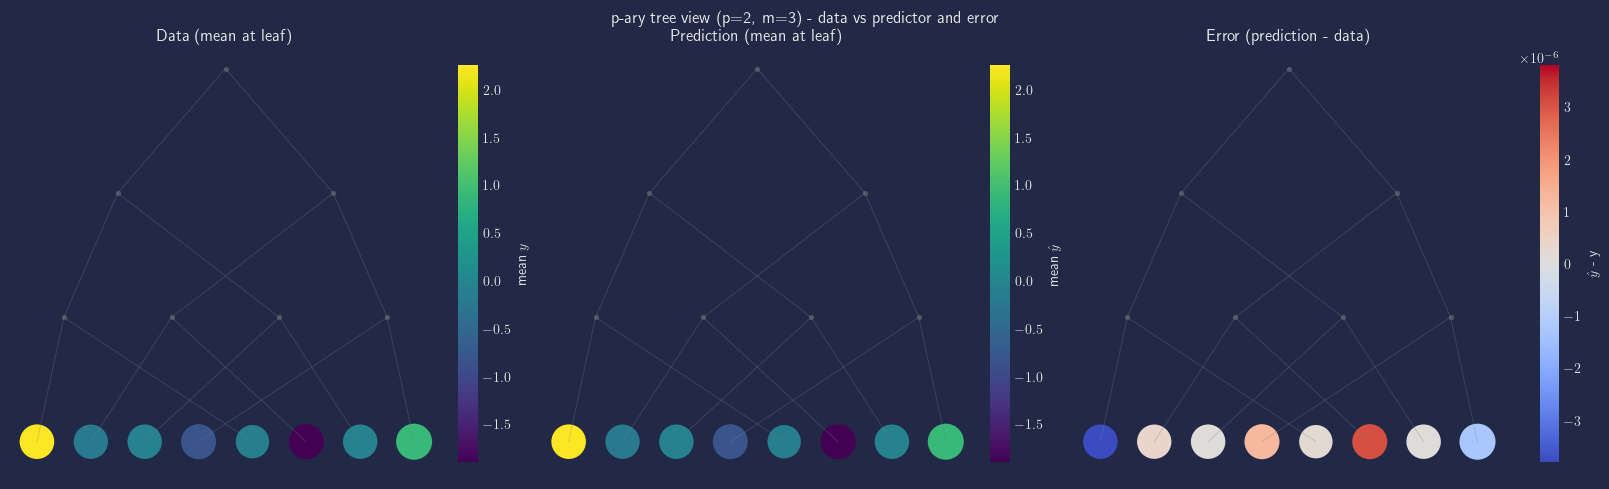

,residue,digits_least_first,count,mean_y,mean_yhat,diff
0,7,"(1, 1, 1)",88,0.893360,0.893359,-1.264317e-06
1,3,"(1, 1, 0)",78,-0.794986,-0.794984,1.236429e-06
2,5,"(1, 0, 1)",78,-1.896682,-1.896679,3.055181e-06
3,0,"(0, 0, 0)",74,2.251974,2.251970,-3.796652e-06
4,2,"(0, 1, 0)",73,-0.062410,-0.062409,6.607597e-08
5,6,"(0, 1, 1)",73,-0.066443,-0.066443,6.769013e-08
6,1,"(1, 0, 0)",72,-0.199430,-0.199430,3.633991e-07
7,4,"(0, 0, 1)",64,-0.118981,-0.118981,2.038606e-07


In [79]:
plot_p_adic_tree_with_predictor(X1, y1, Q1, pred1, p=pred1.p, m=pred1.m,)

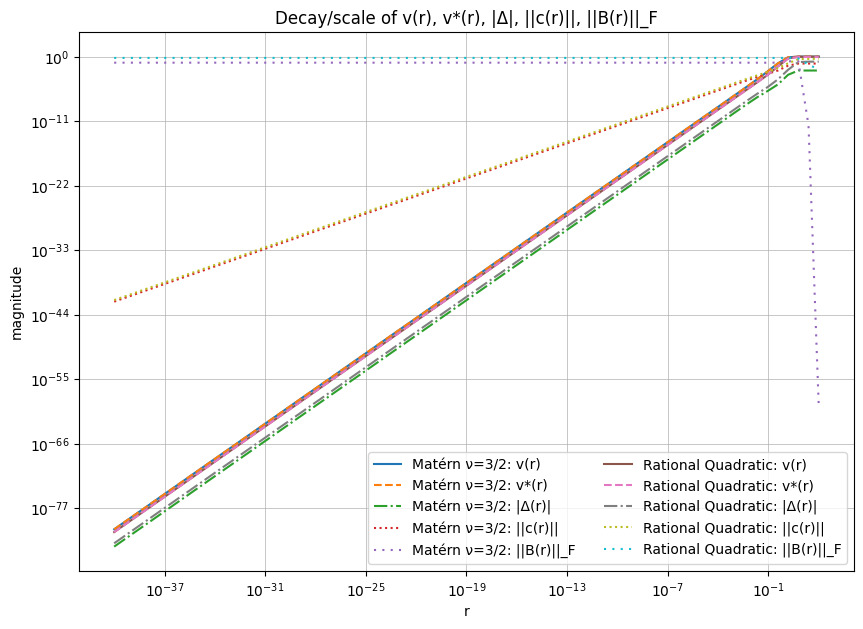

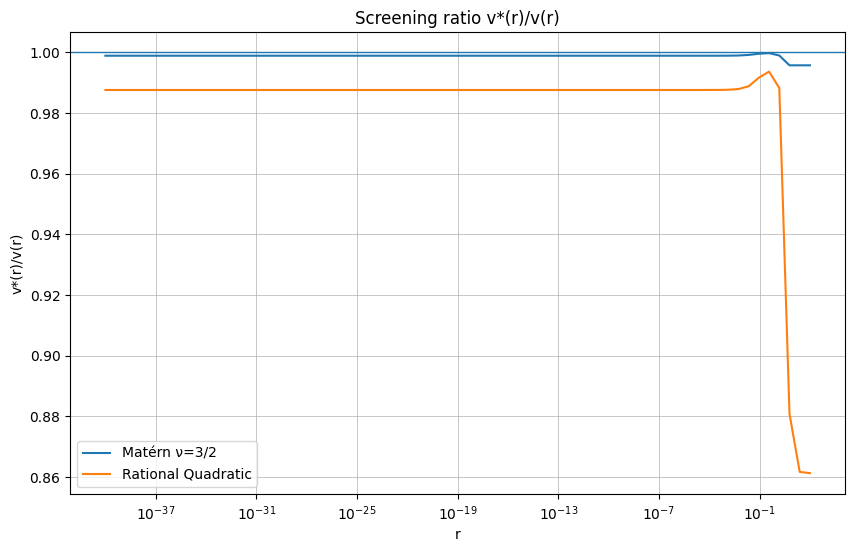

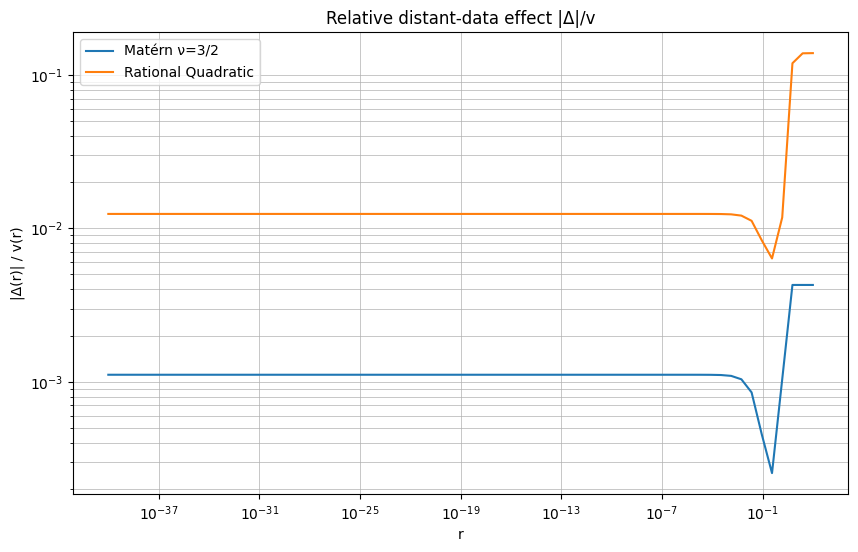

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[warn] Not enough positive finite points for consistency plot: Matérn ν=3/2
[warn] Not enough positive finite points for consistency plot: Rational Quadratic


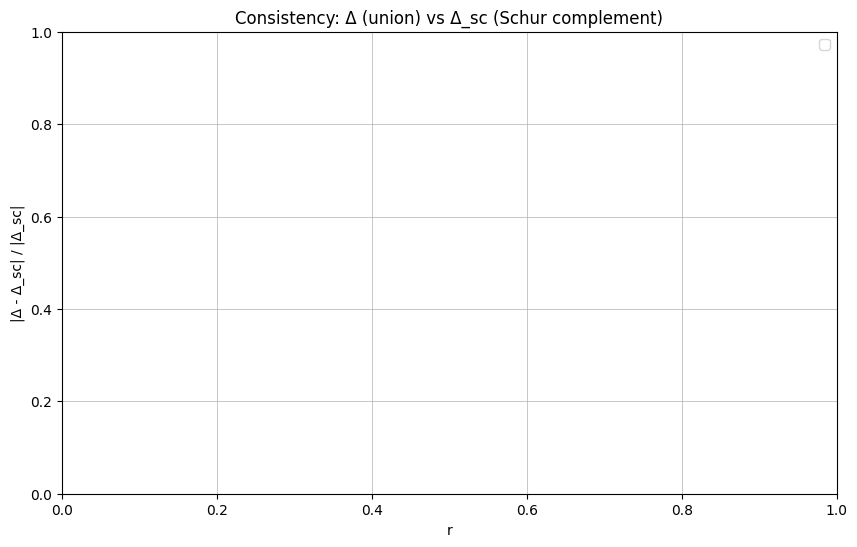


Matérn ν=3/2 tail analysis (r <= 1e-12):
  v(r)       ~ C r^β   with β=2.000,   C=2.700e-01   (n=47)
  v*(r)      ~ C r^β   with β=2.000,  C=2.697e-01  (n=47)
  ||c(r)||   ~ C r^β   with β=1.000,   C=1.727e-02   (n=47)
  |Δ(r)|     ~ C r^β   with β=2.000,   C=2.996e-04   (n=47)
  ||B(r)||_F ~ C r^β   with β=-0.000,   C=9.296e-02   (n=47)
  tail limit Δ/v: mean=0.00110981, median=0.00110981, std=2.17e-19, n=20
  tail limit v*/v: mean=0.99889, median=0.99889, std=3.33e-16, n=20
  inferred leading constant ratio (if same β): C_Δ/C_v ≈ 0.00110981

Rational Quadratic tail analysis (r <= 1e-12):
  v(r)       ~ C r^β   with β=2.000,   C=9.000e-02   (n=47)
  v*(r)      ~ C r^β   with β=2.000,  C=8.888e-02  (n=47)
  ||c(r)||   ~ C r^β   with β=1.000,   C=3.173e-02   (n=47)
  |Δ(r)|     ~ C r^β   with β=2.000,   C=1.117e-03   (n=47)
  ||B(r)||_F ~ C r^β   with β=-0.000,   C=5.998e-01   (n=47)
  tail limit Δ/v: mean=0.0124104, median=0.0124104, std=1.73e-18, n=20
  tail limit v*/v: mean=0.98759,

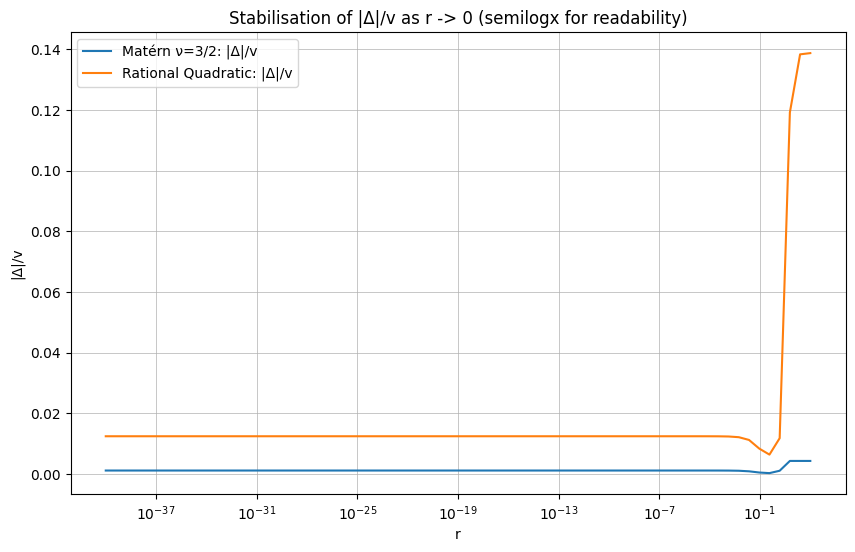

In [ ]:
import mpmath as mp
import numpy as np
import matplotlib.pyplot as plt

mp.mp.dps = 400  # higher precision

# -----------------------------
# mpmath linear algebra helpers
# -----------------------------
def mp_cholesky(A):
    n = A.rows
    L = mp.matrix(n, n)
    for i in range(n):
        for j in range(i + 1):
            s = mp.mpf("0")
            for k in range(j):
                s += L[i, k] * L[j, k]
            if i == j:
                val = A[i, i] - s
                if val <= 0:
                    raise ValueError(f"Matrix not PD at diag {i}: {val}")
                L[i, j] = mp.sqrt(val)
            else:
                L[i, j] = (A[i, j] - s) / L[j, j]
    return L

def mp_forward_sub(L, B):
    n, k = L.rows, B.cols
    X = mp.matrix(n, k)
    for col in range(k):
        for i in range(n):
            s = mp.mpf("0")
            for j in range(i):
                s += L[i, j] * X[j, col]
            X[i, col] = (B[i, col] - s) / L[i, i]
    return X

def mp_back_sub(U, B):
    n, k = U.rows, B.cols
    X = mp.matrix(n, k)
    for col in range(k):
        for i in reversed(range(n)):
            s = mp.mpf("0")
            for j in range(i + 1, n):
                s += U[i, j] * X[j, col]
            X[i, col] = (B[i, col] - s) / U[i, i]
    return X

def mp_chol_solve(A, B):
    L = mp_cholesky(A)
    Y = mp_forward_sub(L, B)
    X = mp_back_sub(L.T, Y)
    return X

def mp_dot(u, v):
    s = mp.mpf("0")
    for i in range(u.rows):
        s += u[i, 0] * v[i, 0]
    return s

def mp_frob_norm(M):
    s = mp.mpf("0")
    for i in range(M.rows):
        for j in range(M.cols):
            s += M[i, j] * M[i, j]
    return mp.sqrt(s)

# -----------------------------
# Kernels in mp
# -----------------------------
def mp_norm(x):
    return mp.sqrt(sum([xi * xi for xi in x]))

def matern32_mp(x, y, ell=mp.mpf("1"), sigma2=mp.mpf("1")):
    d = mp_norm([x[i] - y[i] for i in range(len(x))])
    s = mp.sqrt(3) * d / ell
    return sigma2 * (1 + s) * mp.e ** (-s)

def ratquad_mp(x, y, ell=mp.mpf("1"), alpha=mp.mpf("0.7"), sigma2=mp.mpf("1")):
    d = mp_norm([x[i] - y[i] for i in range(len(x))])
    return sigma2 * (1 + (d * d) / (2 * alpha * ell * ell)) ** (-alpha)

def mp_gram(X, Y, kfun, **kws):
    n, m = len(X), len(Y)
    M = mp.matrix(n, m)
    for i in range(n):
        for j in range(m):
            M[i, j] = kfun(X[i], Y[j], **kws)
    return M

# -----------------------------
# "Difference-free" posterior variance at 0 via precision element
# v = Var(f0 | y) = 1 / (Σ^{-1})_{00}, where Σ is joint covariance of [f0; y]
# -----------------------------
def cond_var_via_precision(k00, k0, K):
    n = K.rows
    Sigma = mp.matrix(n + 1, n + 1)
    Sigma[0, 0] = k00
    for i in range(n):
        Sigma[0, i + 1] = k0[i, 0]
        Sigma[i + 1, 0] = k0[i, 0]
    for i in range(n):
        for j in range(n):
            Sigma[i + 1, j + 1] = K[i, j]
    e1 = mp.matrix(n + 1, 1)
    e1[0, 0] = mp.mpf("1")
    x = mp_chol_solve(Sigma, e1)
    Q00 = x[0, 0]
    return mp.mpf("1") / Q00

# -----------------------------
# Diagnostics (noiseless)
# -----------------------------
def diagnostics_noiseless(r, X_local_base, X_star, kfun, **kws):
    r = mp.mpf(r)
    d = len(X_local_base[0])
    x0 = [mp.mpf("0")] * d

    X_local = [[r * mp.mpf(xij) for xij in xi] for xi in X_local_base]
    X_star = [[mp.mpf(xij) for xij in xi] for xi in X_star]
    X_all = X_local + X_star

    # Local blocks
    K = mp_gram(X_local, X_local, kfun, **kws)
    k0 = mp_gram([x0], X_local, kfun, **kws).T
    k00 = kfun(x0, x0, **kws)

    v = cond_var_via_precision(k00, k0, K)

    # Union blocks
    K_all = mp_gram(X_all, X_all, kfun, **kws)
    k0_all = mp_gram([x0], X_all, kfun, **kws).T
    v_star = cond_var_via_precision(k00, k0_all, K_all)

    Delta = v - v_star

    # Schur objects w.r.t local conditioning
    K_LS = mp_gram(X_local, X_star, kfun, **kws)      # B(r) as (n,m)
    k0S = mp_gram([x0], X_star, kfun, **kws).T        # b as (m,1)
    B = K_LS

    # Norm of B(r) (Frobenius): useful for decay/constancy diagnostics
    B_frob = mp_frob_norm(B)

    # Compute c(r) and Schur complement S(r)
    # Kinv_k0 = K^{-1} k0 ; Kinv_B = K^{-1} B
    Kinv_k0 = mp_chol_solve(K, k0)
    Kinv_B = mp_chol_solve(K, B)

    c = k0S - (B.T * Kinv_k0)  # (m,1)
    S = mp_gram(X_star, X_star, kfun, **kws) - (B.T * Kinv_B)  # (m,m)

    # Delta via Schur
    Sinv_c = mp_chol_solve(S, c)
    Delta_sc = mp_dot(c, Sinv_c)

    # norms/ratios
    cnorm = mp.sqrt(mp_dot(c, c))
    ratio = v_star / v if v != 0 else mp.nan
    Delta_over_v = Delta / v if v != 0 else mp.nan
    return {
        "r": r,
        "v": v,
        "v_star": v_star,
        "Delta": Delta,
        "Delta_over_v": Delta_over_v,
        "ratio": ratio,
        "cnorm": cnorm,
        "B_frob": B_frob,
        "Delta_sc": Delta_sc,
        "Delta_sc_over_c2": Delta_sc / (cnorm * cnorm) if cnorm != 0 else mp.nan,
    }

# -----------------------------
# Setup: symmetric two-point local design in 2D
# -----------------------------
x = [mp.mpf("0.8"), mp.mpf("-0.3")]
X_local_base = [x, [-x[0], x[1]]]  # ±x

X_star = [
    [mp.mpf("2.5"), mp.mpf("1.2")],
    [mp.mpf("-1.8"), mp.mpf("2.2")],
    [mp.mpf("3.0"), mp.mpf("-2.0")],
]

# r grid
r_vals = np.logspace(-40, 2, 70)

specs = [
    ("Matérn ν=3/2", matern32_mp, dict(ell=mp.mpf("1"), sigma2=mp.mpf("1"))),
    ("Rational Quadratic", ratquad_mp, dict(ell=mp.mpf("1"), alpha=mp.mpf("0.7"), sigma2=mp.mpf("1"))),
]

results = {}
for name, kfun, params in specs:
    rows = []
    for r in r_vals:
        rows.append(diagnostics_noiseless(r, X_local_base, X_star, kfun, **params))
    results[name] = rows

def to_float_arr(key, name):
    return np.array([float(row[key]) for row in results[name]], dtype=float)

# -----------------------------
# Helpers: local slopes on log-log
# -----------------------------
def local_loglog_slope(x, y, window=9):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    s = np.full_like(x, np.nan, dtype=float)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    idx = np.where(m)[0]
    if len(idx) < window:
        return s
    half = window // 2
    for k in range(half, len(idx) - half):
        ii = idx[k - half : k + half + 1]
        X = np.log(x[ii])
        Y = np.log(y[ii])
        A = np.vstack([X, np.ones_like(X)]).T
        slope, _ = np.linalg.lstsq(A, Y, rcond=None)[0]
        s[idx[k]] = slope
    return s

def tail_slope(x, y, xmax=1e-12):
    x = np.asarray(x)
    y = np.asarray(y)
    m = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y) & (x <= xmax)
    if np.sum(m) < 10:
        return np.nan
    X = np.log(x[m]); Y = np.log(y[m])
    A = np.vstack([X, np.ones_like(X)]).T
    slope, _ = np.linalg.lstsq(A, Y, rcond=None)[0]
    return float(slope)

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Robust log-log linear fit on a tail window:
# fits log y = a + b log r  -> y ~ exp(a) r^b
# -----------------------------
def loglog_fit_tail(r, y, r_max=1e-12):
    r = np.asarray(r, dtype=float)
    y = np.asarray(y, dtype=float)

    m = (
        np.isfinite(r) & np.isfinite(y) &
        (r > 0) & (y > 0) &
        (r <= r_max)
    )
    if np.sum(m) < 8:
        return {"beta": np.nan, "C": np.nan, "n": int(np.sum(m))}

    X = np.log(r[m])
    Y = np.log(y[m])
    A = np.vstack([X, np.ones_like(X)]).T
    beta, a = np.linalg.lstsq(A, Y, rcond=None)[0]
    C = float(np.exp(a))
    return {"beta": float(beta), "C": C, "n": int(np.sum(m))}

# -----------------------------
# Estimate tail limit of a ratio by (weighted) averaging on smallest r's
# -----------------------------
def tail_limit_estimate(r, z, r_max=1e-12, k=15):
    r = np.asarray(r, dtype=float)
    z = np.asarray(z, dtype=float)

    m = np.isfinite(r) & np.isfinite(z) & (r > 0) & (r <= r_max)
    idx = np.where(m)[0]
    if len(idx) == 0:
        return {"mean": np.nan, "std": np.nan, "n": 0}

    # Take k smallest r points
    idx = idx[np.argsort(r[idx])]
    idx = idx[: min(k, len(idx))]

    zz = z[idx]
    # If zz has crazy spikes, a median is often more stable than mean
    mean = float(np.mean(zz))
    std = float(np.std(zz))
    med = float(np.median(zz))
    mad = float(np.median(np.abs(zz - med)))
    return {"mean": mean, "std": std, "median": med, "mad": mad, "n": int(len(idx))}

# -----------------------------
# Convenience: safe relative error array for log plotting
# -----------------------------
def safe_rel_error(num, den, eps=1e-300):
    num = np.asarray(num, dtype=float)
    den = np.asarray(den, dtype=float)
    return np.abs(num) / np.maximum(np.abs(den), eps)

# -----------------------------
# Plots: magnitudes
# -----------------------------
plt.figure(figsize=(10, 7))
for name in results:
    rr = r_vals
    v = to_float_arr("v", name)
    vs = to_float_arr("v_star", name)
    D = np.abs(to_float_arr("Delta", name))
    cn = to_float_arr("cnorm", name)
    Bn = to_float_arr("B_frob", name)

    plt.loglog(rr, v, label=f"{name}: v(r)")
    plt.loglog(rr, vs, linestyle="--", label=f"{name}: v*(r)")
    plt.loglog(rr, D, linestyle="-.", label=f"{name}: |Δ(r)|")
    plt.loglog(rr, cn, linestyle=":", label=f"{name}: ||c(r)||")
    plt.loglog(rr, Bn, linestyle=(0, (1, 3)), label=f"{name}: ||B(r)||_F")

plt.xlabel("r")
plt.ylabel("magnitude")
plt.title("Decay/scale of v(r), v*(r), |Δ|, ||c(r)||, ||B(r)||_F")
plt.legend(ncol=2)
plt.grid(True, which="both", linewidth=0.5)
plt.show()

# -----------------------------
# Plots: screening ratio and Δ/v
# -----------------------------
plt.figure(figsize=(10, 6))
for name in results:
    plt.semilogx(r_vals, to_float_arr("ratio", name), label=name)
plt.axhline(1.0, linewidth=1.0)
plt.xlabel("r")
plt.ylabel("v*(r)/v(r)")
plt.title("Screening ratio v*(r)/v(r)")
plt.legend()
plt.grid(True, which="both", linewidth=0.5)
plt.show()

plt.figure(figsize=(10, 6))
for name in results:
    plt.loglog(r_vals, np.abs(to_float_arr("Delta_over_v", name)), label=name)
plt.xlabel("r")
plt.ylabel("|Δ(r)| / v(r)")
plt.title("Relative distant-data effect |Δ|/v")
plt.legend()
plt.grid(True, which="both", linewidth=0.5)
plt.show()

# -----------------------------
# Consistency plot: Δ from union vs Δ_sc (Schur)
# Fixes the "no positive values" log warning by masking nonpositive/invalid points.
# -----------------------------
plt.figure(figsize=(10, 6))
for name in results:
    rr = np.asarray(r_vals, dtype=float)
    D = to_float_arr("Delta", name)
    Dsc = to_float_arr("Delta_sc", name)

    rel = safe_rel_error(D - Dsc, Dsc, eps=1e-300)
    m = np.isfinite(rel) & (rel > 0) & np.isfinite(rr) & (rr > 0)

    if np.sum(m) < 2:
        # fallback: show nothing meaningful
        print(f"[warn] Not enough positive finite points for consistency plot: {name}")
        continue

    plt.loglog(rr[m], rel[m], label=name)

plt.xlabel("r")
plt.ylabel("|Δ - Δ_sc| / |Δ_sc|")
plt.title("Consistency: Δ (union) vs Δ_sc (Schur complement)")
plt.legend()
plt.grid(True, which="both", linewidth=0.5)
plt.show()

# -----------------------------
# Tail fits: estimate exponents AND leading constants
# -----------------------------
tail_cut = 1e-12

for name in results:
    rr = np.asarray(r_vals, dtype=float)
    v = to_float_arr("v", name)
    vs = to_float_arr("v_star", name)
    cn = to_float_arr("cnorm", name)
    D = np.abs(to_float_arr("Delta", name))
    Bn = to_float_arr("B_frob", name)
    R = np.abs(to_float_arr("Delta_over_v", name))
    ratio = to_float_arr("ratio", name)

    fit_v = loglog_fit_tail(rr, v, r_max=tail_cut)
    fit_vs = loglog_fit_tail(rr, vs, r_max=tail_cut)
    fit_c = loglog_fit_tail(rr, cn, r_max=tail_cut)
    fit_D = loglog_fit_tail(rr, D, r_max=tail_cut)
    fit_B = loglog_fit_tail(rr, Bn, r_max=tail_cut)

    lim_D_over_v = tail_limit_estimate(rr, R, r_max=tail_cut, k=20)
    lim_ratio = tail_limit_estimate(rr, ratio, r_max=tail_cut, k=20)

    # Optional: if v and Delta share exponent, estimate leading-constant ratio C_D/C_v
    # by fitting both and comparing C (only meaningful if betas are close)
    C_ratio = np.nan
    if np.isfinite(fit_v["beta"]) and np.isfinite(fit_D["beta"]):
        if abs(fit_v["beta"] - fit_D["beta"]) < 0.25:  # heuristic tolerance
            C_ratio = fit_D["C"] / fit_v["C"]

    print(f"\n{name} tail analysis (r <= {tail_cut:g}):")
    print(f"  v(r)       ~ C r^β   with β={fit_v['beta']:.3f},   C={fit_v['C']:.3e}   (n={fit_v['n']})")
    print(f"  v*(r)      ~ C r^β   with β={fit_vs['beta']:.3f},  C={fit_vs['C']:.3e}  (n={fit_vs['n']})")
    print(f"  ||c(r)||   ~ C r^β   with β={fit_c['beta']:.3f},   C={fit_c['C']:.3e}   (n={fit_c['n']})")
    print(f"  |Δ(r)|     ~ C r^β   with β={fit_D['beta']:.3f},   C={fit_D['C']:.3e}   (n={fit_D['n']})")
    print(f"  ||B(r)||_F ~ C r^β   with β={fit_B['beta']:.3f},   C={fit_B['C']:.3e}   (n={fit_B['n']})")

    print(f"  tail limit Δ/v: mean={lim_D_over_v['mean']:.6g}, median={lim_D_over_v['median']:.6g}, "
          f"std={lim_D_over_v['std']:.3g}, n={lim_D_over_v['n']}")
    print(f"  tail limit v*/v: mean={lim_ratio['mean']:.6g}, median={lim_ratio['median']:.6g}, "
          f"std={lim_ratio['std']:.3g}, n={lim_ratio['n']}")

    if np.isfinite(C_ratio):
        print(f"  inferred leading constant ratio (if same β): C_Δ/C_v ≈ {C_ratio:.6g}")

# -----------------------------
# Optional plot: tail ratio stabilisation
# -----------------------------
plt.figure(figsize=(10, 6))
for name in results:
    rr = np.asarray(r_vals, dtype=float)
    R = np.abs(to_float_arr("Delta_over_v", name))
    m = np.isfinite(rr) & np.isfinite(R) & (rr > 0) & (R > 0)
    plt.semilogx(rr[m], R[m], label=f"{name}: |Δ|/v")
plt.xlabel("r")
plt.ylabel("|Δ|/v")
plt.title("Stabilisation of |Δ|/v as r -> 0 (semilogx for readability)")
plt.legend()
plt.grid(True, which="both", linewidth=0.5)
plt.show()

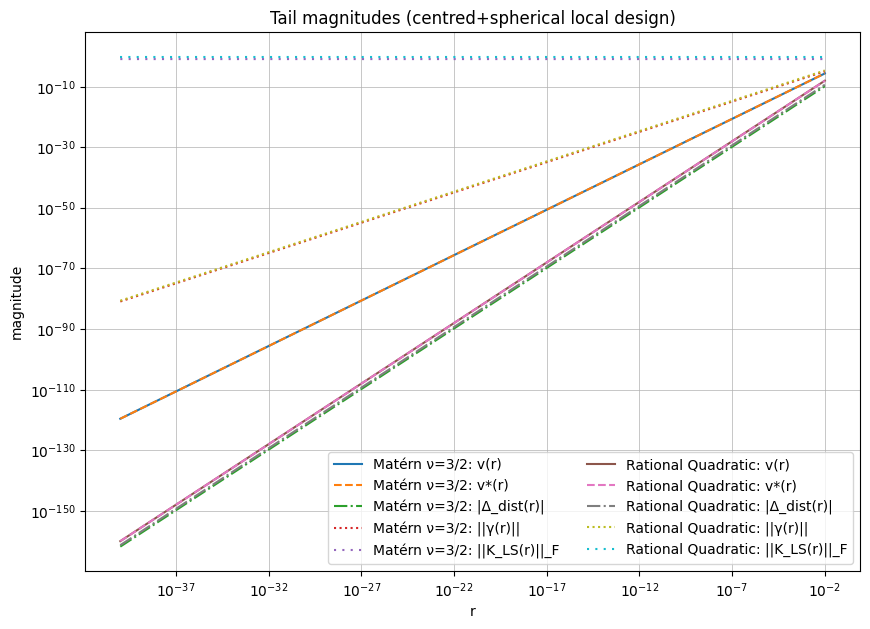

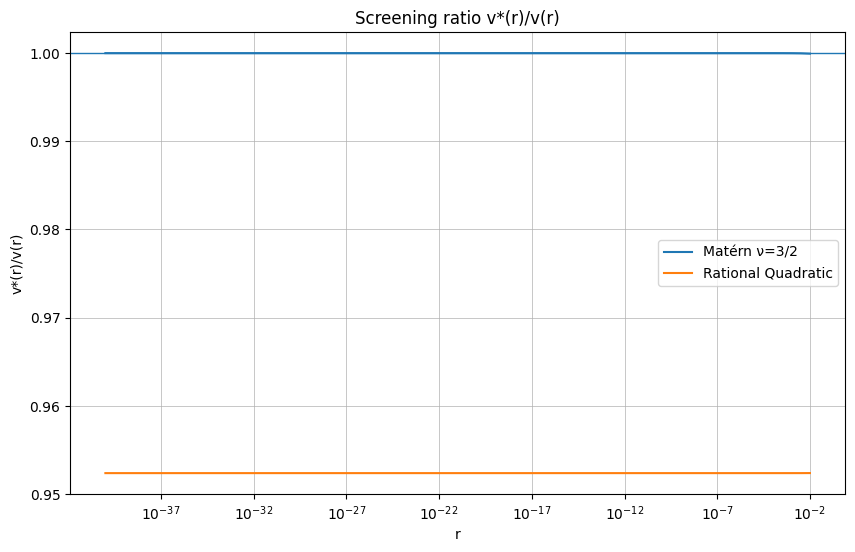

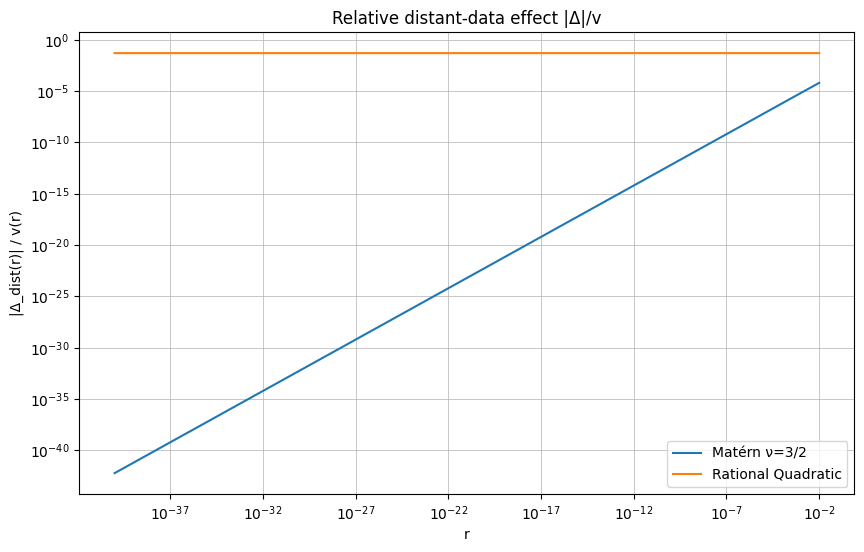

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



Matérn ν=3/2 tail analysis (r <= 1e-12):
  v(r)            ~ C r^β   β=3.000,   C=2.449e+00   (n=59)
  ||γ(r)||        ~ C r^β   β=2.000,   C=1.229e-01   (n=59)
  |Δ_dist(r)|     ~ C r^β   β=4.000,   C=1.501e-02   (n=59)
  |Δ|/v           ~ C r^β   β=1.000,   C=6.126e-03   (n=59)
  tail limit v*/v: mean=1, median=1, std=0, n=25

Rational Quadratic tail analysis (r <= 1e-12):
  v(r)            ~ C r^β   β=4.000,   C=9.643e-01   (n=59)
  ||γ(r)||        ~ C r^β   β=2.000,   C=2.256e-01   (n=59)
  |Δ_dist(r)|     ~ C r^β   β=4.000,   C=4.593e-02   (n=59)
  |Δ|/v           ~ C r^β   β=-0.000,   C=4.763e-02   (n=59)
  tail limit v*/v: mean=0.952372, median=0.952372, std=1.11e-16, n=25


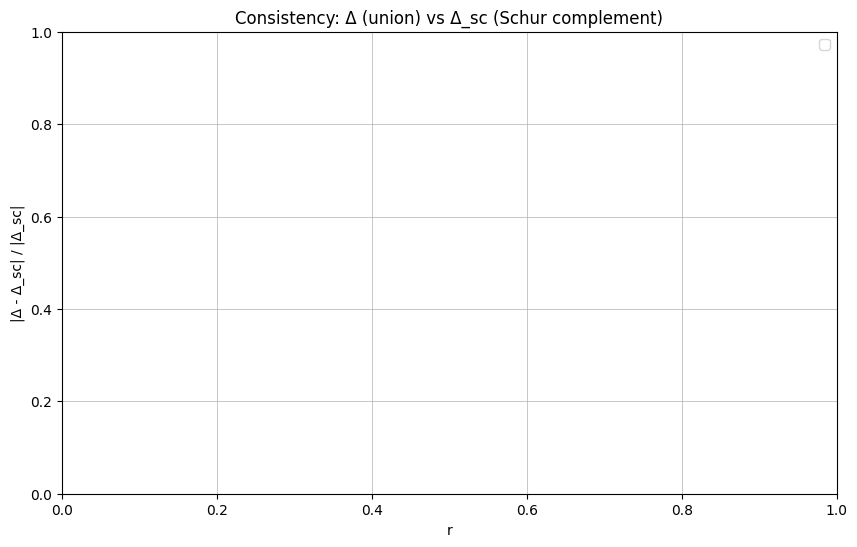

In [40]:
import mpmath as mp
import numpy as np
import matplotlib.pyplot as plt

mp.mp.dps = 400  # higher precision

# -----------------------------
# mpmath linear algebra helpers
# -----------------------------
def mp_cholesky(A):
    n = A.rows
    L = mp.matrix(n, n)
    for i in range(n):
        for j in range(i + 1):
            s = mp.mpf("0")
            for k in range(j):
                s += L[i, k] * L[j, k]
            if i == j:
                val = A[i, i] - s
                if val <= 0:
                    raise ValueError(f"Matrix not PD at diag {i}: {val}")
                L[i, j] = mp.sqrt(val)
            else:
                L[i, j] = (A[i, j] - s) / L[j, j]
    return L

def mp_forward_sub(L, B):
    n, k = L.rows, B.cols
    X = mp.matrix(n, k)
    for col in range(k):
        for i in range(n):
            s = mp.mpf("0")
            for j in range(i):
                s += L[i, j] * X[j, col]
            X[i, col] = (B[i, col] - s) / L[i, i]
    return X

def mp_back_sub(U, B):
    n, k = U.rows, B.cols
    X = mp.matrix(n, k)
    for col in range(k):
        for i in reversed(range(n)):
            s = mp.mpf("0")
            for j in range(i + 1, n):
                s += U[i, j] * X[j, col]
            X[i, col] = (B[i, col] - s) / U[i, i]
    return X

def mp_chol_solve(A, B):
    L = mp_cholesky(A)
    Y = mp_forward_sub(L, B)
    X = mp_back_sub(L.T, Y)
    return X

def mp_dot(u, v):
    s = mp.mpf("0")
    for i in range(u.rows):
        s += u[i, 0] * v[i, 0]
    return s

def mp_frob_norm(M):
    s = mp.mpf("0")
    for i in range(M.rows):
        for j in range(M.cols):
            s += M[i, j] * M[i, j]
    return mp.sqrt(s)

# -----------------------------
# Kernels in mp
# -----------------------------
def mp_norm(x):
    return mp.sqrt(sum([xi * xi for xi in x]))

def matern32_mp(x, y, ell=mp.mpf("1"), sigma2=mp.mpf("1")):
    d = mp_norm([x[i] - y[i] for i in range(len(x))])
    s = mp.sqrt(3) * d / ell
    return sigma2 * (1 + s) * mp.e ** (-s)

def ratquad_mp(x, y, ell=mp.mpf("1"), alpha=mp.mpf("0.7"), sigma2=mp.mpf("1")):
    d = mp_norm([x[i] - y[i] for i in range(len(x))])
    return sigma2 * (1 + (d * d) / (2 * alpha * ell * ell)) ** (-alpha)

def mp_gram(X, Y, kfun, **kws):
    n, m = len(X), len(Y)
    M = mp.matrix(n, m)
    for i in range(n):
        for j in range(m):
            M[i, j] = kfun(X[i], Y[j], **kws)
    return M

# -----------------------------
# "Difference-free" posterior variance at 0 via precision element
# v = Var(f0 | y) = 1 / (Σ^{-1})_{00}, where Σ is joint covariance of [f0; y]
# -----------------------------
def cond_var_via_precision(k00, k0, K):
    n = K.rows
    Sigma = mp.matrix(n + 1, n + 1)
    Sigma[0, 0] = k00
    for i in range(n):
        Sigma[0, i + 1] = k0[i, 0]
        Sigma[i + 1, 0] = k0[i, 0]
    for i in range(n):
        for j in range(n):
            Sigma[i + 1, j + 1] = K[i, j]
    e1 = mp.matrix(n + 1, 1)
    e1[0, 0] = mp.mpf("1")
    x = mp_chol_solve(Sigma, e1)
    Q00 = x[0, 0]
    return mp.mpf("1") / Q00

# -----------------------------
# Diagnostics (noiseless)
# -----------------------------
def diagnostics_noiseless(r, X_local_base, X_star, kfun, **kws):
    r = mp.mpf(r)
    d = len(X_local_base[0])
    x0 = [mp.mpf("0")] * d

    X_local = [[r * mp.mpf(xij) for xij in xi] for xi in X_local_base]
    X_star = [[mp.mpf(xij) for xij in xi] for xi in X_star]
    X_all = X_local + X_star

    # Local blocks
    K = mp_gram(X_local, X_local, kfun, **kws)
    k0 = mp_gram([x0], X_local, kfun, **kws).T
    k00 = kfun(x0, x0, **kws)

    v = cond_var_via_precision(k00, k0, K)

    # Union blocks
    K_all = mp_gram(X_all, X_all, kfun, **kws)
    k0_all = mp_gram([x0], X_all, kfun, **kws).T
    v_star = cond_var_via_precision(k00, k0_all, K_all)

    Delta = v - v_star  # Δ_dist

    # Schur objects w.r.t local conditioning
    K_LS = mp_gram(X_local, X_star, kfun, **kws)      # (n,m) = mathcal K(r)
    dvec = mp_gram([x0], X_star, kfun, **kws).T        # (m,1) = d
    B = K_LS

    # Norm of B(r) (Frobenius)
    B_frob = mp_frob_norm(B)

    # Compute gamma(r) and Sigma_dist(r)
    # w = K^{-1} a   (here a = k0)
    Kinv_k0 = mp_chol_solve(K, k0)
    Kinv_B = mp_chol_solve(K, B)

    gamma = dvec - (B.T * Kinv_k0)                     # (m,1) = γ(r)
    Sigma_dist = mp_gram(X_star, X_star, kfun, **kws) - (B.T * Kinv_B)  # (m,m)

    # Δ via Schur: Δ = γ^T Σ^{-1} γ
    Sinv_gamma = mp_chol_solve(Sigma_dist, gamma)
    Delta_sc = mp_dot(gamma, Sinv_gamma)

    gamma_norm = mp.sqrt(mp_dot(gamma, gamma))
    ratio = v_star / v if v != 0 else mp.nan
    Delta_over_v = Delta / v if v != 0 else mp.nan

    return {
        "r": r,
        "v": v,
        "v_star": v_star,
        "Delta": Delta,
        "Delta_over_v": Delta_over_v,
        "ratio": ratio,
        "gamma_norm": gamma_norm,     ### NEW name (was cnorm)
        "B_frob": B_frob,
        "Delta_sc": Delta_sc,
        "Delta_sc_over_g2": Delta_sc / (gamma_norm * gamma_norm) if gamma_norm != 0 else mp.nan,
    }

# -----------------------------
# ### NEW/CHANGED: symmetric centred+spherical local design in 2D
# Points on a circle, with antipodal symmetry, centroid 0, all norms equal.
# -----------------------------
def symmetric_spherical_design_2d(radius=mp.mpf("1")):
    r = mp.mpf(radius)
    return [
        [ r, mp.mpf("0")],
        [-r, mp.mpf("0")],
        [ mp.mpf("0"),  r],
        [ mp.mpf("0"), -r],
    ]

X_local_base = symmetric_spherical_design_2d(radius=mp.mpf("1"))

# Distant design (keep generic; not scaled with r)
X_star = [
    [mp.mpf("2.5"), mp.mpf("1.2")],
    [mp.mpf("-1.8"), mp.mpf("2.2")],
    [mp.mpf("3.0"), mp.mpf("-2.0")],
]

# r grid: focus on small r tail (you can widen later)
r_vals = np.logspace(-40, -2, 80)

specs = [
    ("Matérn ν=3/2", matern32_mp, dict(ell=mp.mpf("1"), sigma2=mp.mpf("1"))),
    ("Rational Quadratic", ratquad_mp, dict(ell=mp.mpf("1"), alpha=mp.mpf("0.7"), sigma2=mp.mpf("1"))),
]

results = {}
for name, kfun, params in specs:
    rows = []
    for r in r_vals:
        rows.append(diagnostics_noiseless(r, X_local_base, X_star, kfun, **params))
    results[name] = rows

def to_float_arr(key, name):
    return np.array([float(row[key]) for row in results[name]], dtype=float)

# -----------------------------
# Robust log-log linear fit on a tail window:
# fits log y = a + b log r  -> y ~ C r^b
# -----------------------------
def loglog_fit_tail(r, y, r_max=1e-12):
    r = np.asarray(r, dtype=float)
    y = np.asarray(y, dtype=float)

    m = (
        np.isfinite(r) & np.isfinite(y) &
        (r > 0) & (y > 0) &
        (r <= r_max)
    )
    if np.sum(m) < 8:
        return {"beta": np.nan, "C": np.nan, "n": int(np.sum(m))}

    X = np.log(r[m])
    Y = np.log(y[m])
    A = np.vstack([X, np.ones_like(X)]).T
    beta, a = np.linalg.lstsq(A, Y, rcond=None)[0]
    C = float(np.exp(a))
    return {"beta": float(beta), "C": C, "n": int(np.sum(m))}

def tail_limit_estimate(r, z, r_max=1e-12, k=20):
    r = np.asarray(r, dtype=float)
    z = np.asarray(z, dtype=float)

    m = np.isfinite(r) & np.isfinite(z) & (r > 0) & (r <= r_max)
    idx = np.where(m)[0]
    if len(idx) == 0:
        return {"mean": np.nan, "std": np.nan, "median": np.nan, "mad": np.nan, "n": 0}

    idx = idx[np.argsort(r[idx])]
    idx = idx[: min(k, len(idx))]
    zz = z[idx]
    mean = float(np.mean(zz))
    std = float(np.std(zz))
    med = float(np.median(zz))
    mad = float(np.median(np.abs(zz - med)))
    return {"mean": mean, "std": std, "median": med, "mad": mad, "n": int(len(idx))}

# -----------------------------
# Plots: magnitudes
# -----------------------------
plt.figure(figsize=(10, 7))
for name in results:
    rr = r_vals
    v = to_float_arr("v", name)
    vs = to_float_arr("v_star", name)
    D = np.abs(to_float_arr("Delta", name))
    g = to_float_arr("gamma_norm", name)
    Bn = to_float_arr("B_frob", name)

    plt.loglog(rr, v, label=f"{name}: v(r)")
    plt.loglog(rr, vs, linestyle="--", label=f"{name}: v*(r)")
    plt.loglog(rr, D, linestyle="-.", label=f"{name}: |Δ_dist(r)|")
    plt.loglog(rr, g, linestyle=":", label=f"{name}: ||γ(r)||")
    plt.loglog(rr, Bn, linestyle=(0, (1, 3)), label=f"{name}: ||K_LS(r)||_F")

plt.xlabel("r")
plt.ylabel("magnitude")
plt.title("Tail magnitudes (centred+spherical local design)")
plt.legend(ncol=2)
plt.grid(True, which="both", linewidth=0.5)
plt.show()

# -----------------------------
# Plots: screening ratio and Δ/v
# -----------------------------
plt.figure(figsize=(10, 6))
for name in results:
    plt.semilogx(r_vals, to_float_arr("ratio", name), label=name)
plt.axhline(1.0, linewidth=1.0)
plt.xlabel("r")
plt.ylabel("v*(r)/v(r)")
plt.title("Screening ratio v*(r)/v(r)")
plt.legend()
plt.grid(True, which="both", linewidth=0.5)
plt.show()

plt.figure(figsize=(10, 6))
for name in results:
    plt.loglog(r_vals, np.abs(to_float_arr("Delta_over_v", name)), label=name)
plt.xlabel("r")
plt.ylabel("|Δ_dist(r)| / v(r)")
plt.title("Relative distant-data effect |Δ|/v")
plt.legend()
plt.grid(True, which="both", linewidth=0.5)
plt.show()

# -----------------------------
# Tail fits: rates we care about
# Theory for centred+spherical local design (generic case):
#   v(r) ~ r^2
#   ||γ(r)|| ~ r^2
#   Δ_dist(r) = γ^T Σ^{-1} γ ~ r^4 (if Σ_dist well-conditioned)
# so |Δ|/v ~ r^2.
# -----------------------------
tail_cut = 1e-12

for name in results:
    rr = np.asarray(r_vals, dtype=float)
    v = to_float_arr("v", name)
    vs = to_float_arr("v_star", name)
    g = to_float_arr("gamma_norm", name)
    D = np.abs(to_float_arr("Delta", name))
    R = np.abs(to_float_arr("Delta_over_v", name))
    ratio = to_float_arr("ratio", name)

    fit_v = loglog_fit_tail(rr, v, r_max=tail_cut)
    fit_g = loglog_fit_tail(rr, g, r_max=tail_cut)
    fit_D = loglog_fit_tail(rr, D, r_max=tail_cut)
    fit_R = loglog_fit_tail(rr, R, r_max=tail_cut)  # exponent of |Δ|/v

    lim_ratio = tail_limit_estimate(rr, ratio, r_max=tail_cut, k=25)

    print(f"\n{name} tail analysis (r <= {tail_cut:g}):")
    print(f"  v(r)            ~ C r^β   β={fit_v['beta']:.3f},   C={fit_v['C']:.3e}   (n={fit_v['n']})")
    print(f"  ||γ(r)||        ~ C r^β   β={fit_g['beta']:.3f},   C={fit_g['C']:.3e}   (n={fit_g['n']})")
    print(f"  |Δ_dist(r)|     ~ C r^β   β={fit_D['beta']:.3f},   C={fit_D['C']:.3e}   (n={fit_D['n']})")
    print(f"  |Δ|/v           ~ C r^β   β={fit_R['beta']:.3f},   C={fit_R['C']:.3e}   (n={fit_R['n']})")
    print(f"  tail limit v*/v: mean={lim_ratio['mean']:.6g}, median={lim_ratio['median']:.6g}, "
          f"std={lim_ratio['std']:.3g}, n={lim_ratio['n']}")

# -----------------------------
# Optional: check Δ equals Schur version Δ_sc
# -----------------------------
def safe_rel_error(num, den, eps=1e-300):
    num = np.asarray(num, dtype=float)
    den = np.asarray(den, dtype=float)
    return np.abs(num) / np.maximum(np.abs(den), eps)

plt.figure(figsize=(10, 6))
for name in results:
    rr = np.asarray(r_vals, dtype=float)
    D = to_float_arr("Delta", name)
    Dsc = to_float_arr("Delta_sc", name)
    rel = safe_rel_error(D - Dsc, Dsc, eps=1e-300)
    m = np.isfinite(rel) & (rel > 0) & np.isfinite(rr) & (rr > 0)
    if np.sum(m) >= 2:
        plt.loglog(rr[m], rel[m], label=name)

plt.xlabel("r")
plt.ylabel("|Δ - Δ_sc| / |Δ_sc|")
plt.title("Consistency: Δ (union) vs Δ_sc (Schur complement)")
plt.legend()
plt.grid(True, which="both", linewidth=0.5)
plt.show()


ASYMPTOTIC DIAGNOSTICS REPORT
lam(r) range (mp): 1.0e-258 1.0e-28

--- asymptotic exponents (mp fit over r <= 1e-12) ---
v(r):           3.99662073653
||gamma(r)||:   3.99662073653
|Delta(r)|:     7.99324147307
|Delta|/v:      3.99662073653

--- tail ratios (mp aggregation) ---
v*/v mean/std: 1 1.20037e-53  (n=45)

--- gamma/r^2 diagnostic (mp) ---
mean ||gamma||/r^2: 9.40455856105e-29
std  ||gamma||/r^2: 4.73369183416e-28



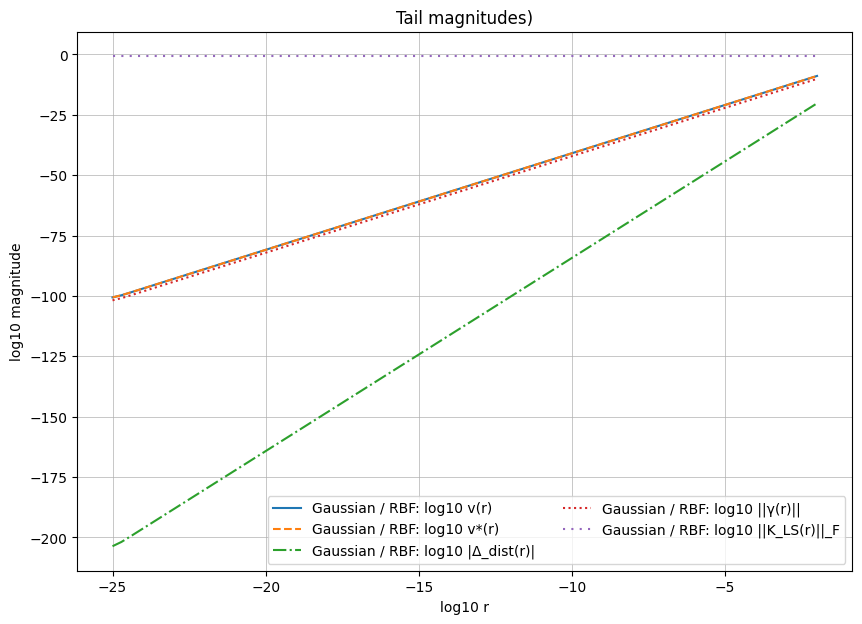

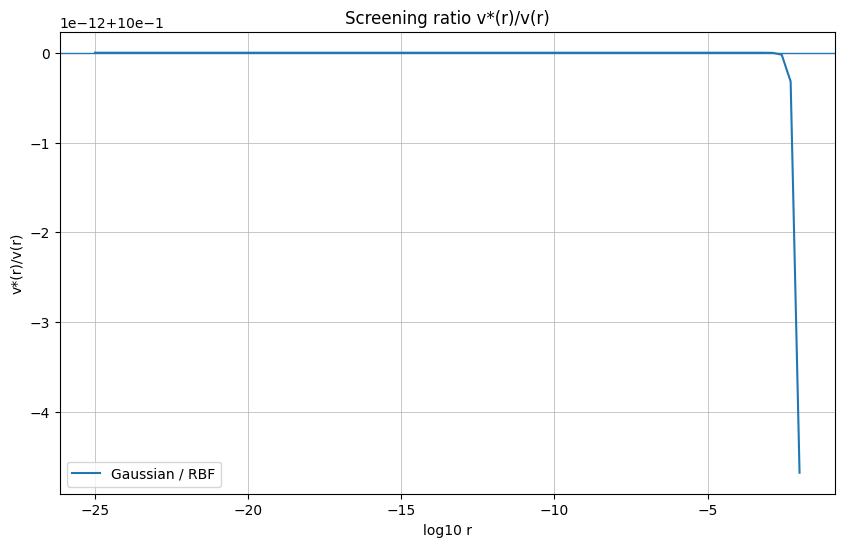

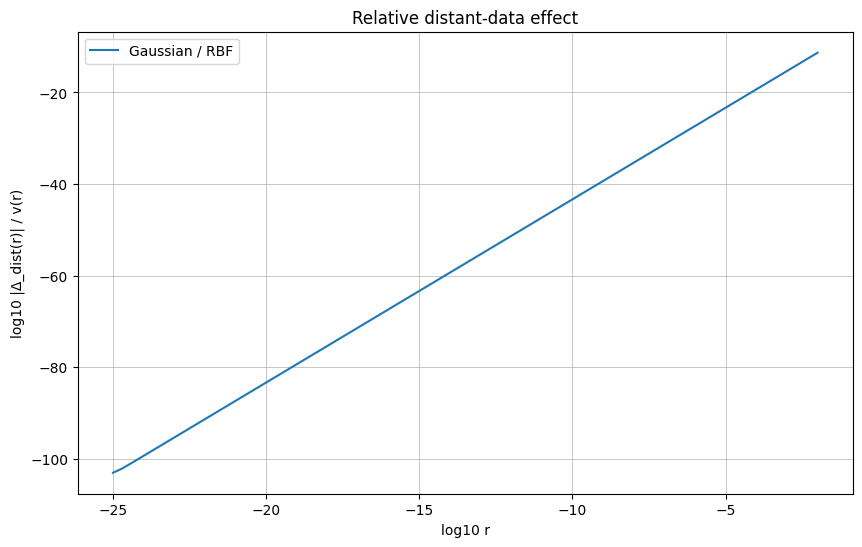

In [58]:
import mpmath as mp
import numpy as np
import matplotlib.pyplot as plt

mp.mp.dps = 1500  # you can crank this up; 200 is usually enough for r~1e-40

# ============================================================
# 1) Build centred + spherical X in R^3 but low-rank => S PSD
#    Put points on xy-plane circle => ker(S) contains e_z
# ============================================================

# def centred_spherical_circle_design_3d(n_points=8, radius=1.0):
#     """
#     n_points evenly spaced on a circle in xy-plane.
#     Centred (sum=0) and spherical (all norms=radius).
#     Lies in 2D subspace => S has 1D nullspace in z-direction.
#     """
#     thetas = np.linspace(0, 2*np.pi, n_points, endpoint=False)
#     X = np.stack([radius*np.cos(thetas), radius*np.sin(thetas), np.zeros_like(thetas)], axis=1)
#     # numerical centring (should already be centred)
#     X = X - X.mean(axis=0, keepdims=True)
#     # rescale to exact radius (very minor)
#     norms = np.linalg.norm(X, axis=1, keepdims=True)
#     X = radius * X / np.maximum(norms, 1e-16)
#     return X

# def second_moment_S(X):
#     n = X.shape[0]
#     return (X.T @ X) / n

# def nullspace_basis_sym(S, tol=1e-12):
#     evals, evecs = np.linalg.eigh(S)
#     mask = evals <= tol
#     return evecs[:, mask], evals

# def sample_in_nullspace(N, m=1, scale=1.0, rng=None):
#     rng = np.random.default_rng() if rng is None else rng
#     d, k = N.shape
#     if k == 0:
#         raise ValueError("Nullspace is trivial; S is full rank.")
#     coeffs = rng.standard_normal((k, m))
#     Xstar = (N @ coeffs).T
#     norms = np.linalg.norm(Xstar, axis=1, keepdims=True)
#     Xstar = scale * Xstar / np.maximum(norms, 1e-16)
#     return Xstar

# jitter_log = []

# # Build X and X*
# d = 3
# R_local = 1.0
# X_np = centred_spherical_circle_design_3d(n_points=8, radius=R_local)

# S = second_moment_S(X_np)
# N, evals = nullspace_basis_sym(S, tol=1e-12)
# print("Local design X: n,d =", X_np.shape)
# print("S eigenvalues:", evals)
# print("nullspace dim:", N.shape[1])

# # Choose X* in ker(S) (e.g. along z-axis), with fixed radius scale_star
# scale_star = 3.0
# m_star = 3
# Xstar_np = sample_in_nullspace(N, m=m_star, scale=scale_star, rng=np.random.default_rng(0))

# # sanity check: x*^T S x* ~ 0
# q = np.einsum("bi,ij,bj->b", Xstar_np, S, Xstar_np)
# print("x*^T S x*:", q)

# Convert to mp-friendly list-of-lists
# X_local_base = [[mp.mpf(xij) for xij in row] for row in X_np.tolist()]
# X_star = [[mp.mpf(xij) for xij in row] for row in Xstar_np.tolist()]

def centred_spherical_circle_design_3d_mp(radius=mp.mpf("1")):
    r = mp.mpf(radius)
    h = r / mp.sqrt(2)  # sqrt(2)/2 * r
    # 8 points at angles 0, pi/4, ..., 7pi/4 in xy-plane
    return [
        [ r, 0, 0],
        [ h, h, 0],
        [ 0, r, 0],
        [-h, h, 0],
        [-r, 0, 0],
        [-h,-h, 0],
        [ 0,-r, 0],
        [ h,-h, 0],
    ]

def xstar_in_nullspace_mp(m=3, scale=mp.mpf("3")):
    # ker(S)=span(e_z), so pick points on z-axis
    s = mp.mpf(scale)
    if m == 1:
        return [[0,0,s]]
    if m == 2:
        return [[0,0,s],[0,0,-s]]
    # simple deterministic set
    return [[0,0,s],[0,0,-s],[0,0,2*s]]


X_local_base = centred_spherical_circle_design_3d_mp(radius=mp.mpf("1"))
X_star = xstar_in_nullspace_mp(m=3, scale=mp.mpf("3"))

# ============================================================
# 2) mpmath linear algebra helpers (your code, unchanged)
# ============================================================

def mp_chol_solve_jitter(A, B,
                        jitter_rel=mp.mpf("1e-100"),
                        max_tries=12,
                        diag_report=None):

    n = A.rows

    diag_max = mp.mpf("0")
    for i in range(n):
        diag_max = max(diag_max, abs(A[i,i]))

    if diag_max == 0:
        diag_max = mp.mpf("1")

    jitter = jitter_rel * diag_max

    for t in range(max_tries):

        Aj = mp.matrix(A)

        for i in range(n):
            Aj[i,i] += jitter

        try:

            L = mp_cholesky(Aj)

            if diag_report is not None:
                diag_report.append(float(jitter))

            Y = mp_forward_sub(L, B)
            X = mp_back_sub(L.T, Y)

            return X

        except ValueError:

            jitter *= 10

    raise ValueError("Cholesky failed.")

def mp_cholesky(A):
    n = A.rows
    L = mp.matrix(n, n)
    for i in range(n):
        for j in range(i + 1):
            s = mp.mpf("0")
            for k in range(j):
                s += L[i, k] * L[j, k]
            if i == j:
                val = A[i, i] - s
                if val <= 0:
                    raise ValueError(f"Matrix not PD at diag {i}: {val}")
                L[i, j] = mp.sqrt(val)
            else:
                L[i, j] = (A[i, j] - s) / L[j, j]
    return L

def mp_forward_sub(L, B):
    n, k = L.rows, B.cols
    X = mp.matrix(n, k)
    for col in range(k):
        for i in range(n):
            s = mp.mpf("0")
            for j in range(i):
                s += L[i, j] * X[j, col]
            X[i, col] = (B[i, col] - s) / L[i, i]
    return X

def mp_back_sub(U, B):
    n, k = U.rows, B.cols
    X = mp.matrix(n, k)
    for col in range(k):
        for i in reversed(range(n)):
            s = mp.mpf("0")
            for j in range(i + 1, n):
                s += U[i, j] * X[j, col]
            X[i, col] = (B[i, col] - s) / U[i, i]
    return X

def mp_chol_solve(A, B):
    L = mp_cholesky(A)
    Y = mp_forward_sub(L, B)
    X = mp_back_sub(L.T, Y)
    return X

def mp_dot(u, v):
    s = mp.mpf("0")
    for i in range(u.rows):
        s += u[i, 0] * v[i, 0]
    return s

def mp_frob_norm(M):
    s = mp.mpf("0")
    for i in range(M.rows):
        for j in range(M.cols):
            s += M[i, j] * M[i, j]
    return mp.sqrt(s)

# ============================================================
# 3) Gaussian / squared-exponential kernel in mp
#    k(x,y) = sigma^2 * exp(-||x-y||^2/(2 ell^2))
# ============================================================

def mp_sqnorm(x):
    return mp.fsum([xi*xi for xi in x])

def rbf_mp(x, y, ell=mp.mpf("1"), sigma2=mp.mpf("1")):
    # squared distance
    s = mp.fsum([(x[i] - y[i])**2 for i in range(len(x))])
    return sigma2 * mp.e ** (-s / (2 * ell * ell))

def mp_gram(X, Y, kfun, **kws):
    n, m = len(X), len(Y)
    M = mp.matrix(n, m)
    for i in range(n):
        for j in range(m):
            M[i, j] = kfun(X[i], Y[j], **kws)
    return M

def mp_log10_abs(x):
    x = abs(x)
    if x == 0:
        return -mp.inf
    return mp.log(x, 10)

def to_float_log10(key):
    # returns numpy array of log10(|value|)
    return np.array([float(mp_log10_abs(row[key])) for row in rows], dtype=float)

# ============================================================
# 4) "Difference-free" posterior variance at 0 via precision element
# ============================================================

def cond_var_via_precision(k00, k0, K):
    n = K.rows
    Sigma = mp.matrix(n + 1, n + 1)
    Sigma[0, 0] = k00
    for i in range(n):
        Sigma[0, i + 1] = k0[i, 0]
        Sigma[i + 1, 0] = k0[i, 0]
    for i in range(n):
        for j in range(n):
            Sigma[i + 1, j + 1] = K[i, j]
    e1 = mp.matrix(n + 1, 1)
    e1[0, 0] = mp.mpf("1")
    x = mp_chol_solve(Sigma, e1)
    Q00 = x[0, 0]
    return mp.mpf("1") / Q00

# ============================================================
# 5) Diagnostics (noiseless), with rbf kernel
# ============================================================

def add_diag(M, lam):
    M2 = mp.matrix(M)
    for i in range(M.rows):
        M2[i,i] += lam
    return M2

def diagnostics_noiseless(r, X_local_base, X_star, kfun, lam0=mp.mpf("1e-8"), **kws):
    r = mp.mpf(r)
    d = len(X_local_base[0])
    x0 = [mp.mpf("0")] * d

    X_local = [[r * mp.mpf(xij) for xij in xi] for xi in X_local_base]
    X_star_mp = [[mp.mpf(xij) for xij in xi] for xi in X_star]

    # local blocks
    K = mp_gram(X_local, X_local, kfun, **kws)
    k0 = mp_gram([x0], X_local, kfun, **kws).T
    k00 = kfun(x0, x0, **kws)

    # shared nugget (scale with r^8)
    lam = lam0 * (r**10)
    Klam = add_diag(K, lam)

    # v via standard conditional formula, consistent with Schur calc
    Kinv_k0 = mp_chol_solve_jitter(Klam, k0)
    v = k00 - mp_dot(k0, Kinv_k0)

    # cross-cov blocks
    K_LS = mp_gram(X_local, X_star_mp, kfun, **kws)
    dvec = mp_gram([x0], X_star_mp, kfun, **kws).T
    Kinv_B = mp_chol_solve_jitter(Klam, K_LS)

    gamma = dvec - (K_LS.T * Kinv_k0)
    Sigma_dist = mp_gram(X_star_mp, X_star_mp, kfun, **kws) - (K_LS.T * Kinv_B)

    Sinv_gamma = mp_chol_solve_jitter(Sigma_dist, gamma)
    Delta_sc = mp_dot(gamma, Sinv_gamma)

    # optional: compute v_star consistently via Schur update (not union matrix)
    v_star = v - Delta_sc
    Delta = v - v_star  # == Delta_sc by construction

    gamma_norm = mp.sqrt(mp_dot(gamma, gamma))
    ratio = v_star / v if v != 0 else mp.nan
    Delta_over_v = Delta / v if v != 0 else mp.nan

    return {
        "r": r,
        "v": v,
        "v_star": v_star,
        "Delta": Delta,
        "Delta_over_v": Delta_over_v,
        "ratio": ratio,
        "gamma_norm": gamma_norm,
        "B_frob": mp_frob_norm(K_LS),
        "Delta_sc": Delta_sc,
        "lam": lam,
    }

# ============================================================
# 6) Run experiment for Gaussian kernel
# ============================================================

# r grid
r_vals = np.logspace(-25, -2, 80)

name = "Gaussian / RBF"
kfun = rbf_mp
params = dict(ell=mp.mpf("1.2"), sigma2=mp.mpf("1"))

rows = []
for r in r_vals:
    rows.append(diagnostics_noiseless(r, X_local_base, X_star, kfun, **params))



def to_float_arr(key):
    return np.array([float(row[key]) for row in rows], dtype=float)

# ============================================================
# DIAGNOSTIC PRINTING BLOCK
# ============================================================

# ============================================================
# Diagnostics + plots (MP-safe): avoid float underflow by working in log space
# ============================================================

print("\n==============================")
print("ASYMPTOTIC DIAGNOSTICS REPORT")
print("==============================")

tail_cut_mp = mp.mpf("1e-12")
tail_cut_float = 1e-12  # only used for masking r_vals in numpy

# ---------- helpers ----------
def mp_log_abs(x):
    x = abs(x)
    if x == 0:
        return -mp.inf
    return mp.log(x)

def mp_log10_abs(x):
    x = abs(x)
    if x == 0:
        return -mp.inf
    return mp.log(x, 10)

def row_logs(rows, key):
    """Return arrays (log r, log |y|) as mp lists for mp-based regression/diagnostics."""
    X, Y = [], []
    for row in rows:
        r = row["r"]
        if r <= 0:
            continue
        y = row[key]
        if y == 0:
            continue
        X.append(mp.log(r))
        Y.append(mp_log_abs(y))
    return X, Y

def loglog_fit_tail_mp(rows, key, r_max=mp.mpf("1e-12")):
    """Fit log|y| = a + beta log r over r <= r_max using mp arithmetic."""
    X, Y = [], []
    for row in rows:
        r = row["r"]
        if r <= 0 or r > r_max:
            continue
        y = abs(row[key])
        if y <= 0:
            continue
        X.append(mp.log(r))
        Y.append(mp.log(y))

    n = len(X)
    if n < 10:
        return mp.nan

    xbar = mp.fsum(X) / n
    ybar = mp.fsum(Y) / n
    num = mp.fsum([(X[i] - xbar) * (Y[i] - ybar) for i in range(n)])
    den = mp.fsum([(X[i] - xbar) ** 2 for i in range(n)])
    return num / den

def mp_tail_stats(rows, key, r_max=mp.mpf("1e-12")):
    """Return mean/std of key over tail using mp -> float at the end (safe since stats are moderate)."""
    vals = [rows[i][key] for i in range(len(rows)) if rows[i]["r"] <= r_max and rows[i][key] != 0]
    if len(vals) == 0:
        return float("nan"), float("nan"), 0
    # convert after aggregation to avoid losing tail information
    mean = mp.fsum(vals) / len(vals)
    var = mp.fsum([(v - mean) ** 2 for v in vals]) / len(vals)
    return float(mean), float(mp.sqrt(var)), len(vals)

# ---------- nugget diagnostics (avoid float underflow) ----------
lam_min = mp.inf
lam_max = mp.mpf("0")
for row in rows:
    lam = row.get("lam", mp.mpf("0"))
    if lam < lam_min:
        lam_min = lam
    if lam > lam_max:
        lam_max = lam

print("lam(r) range (mp):", mp.nstr(lam_min, 6), mp.nstr(lam_max, 6))

# Optional: jitter log if you collected it
# if "jitter_log" in globals() and len(jitter_log) > 0:
#     print("jitter used: min/max =", min(jitter_log), max(jitter_log))

# ---------- MP slopes (trustworthy) ----------
beta_v = loglog_fit_tail_mp(rows, "v", r_max=tail_cut_mp)
beta_g = loglog_fit_tail_mp(rows, "gamma_norm", r_max=tail_cut_mp)
beta_D = loglog_fit_tail_mp(rows, "Delta", r_max=tail_cut_mp)
beta_R = loglog_fit_tail_mp(rows, "Delta_over_v", r_max=tail_cut_mp)

print(f"\n--- asymptotic exponents (mp fit over r <= {tail_cut_float:g}) ---")
print("v(r):          ", mp.nstr(beta_v, 12))
print("||gamma(r)||:  ", mp.nstr(beta_g, 12))
print("|Delta(r)|:    ", mp.nstr(beta_D, 12))
print("|Delta|/v:     ", mp.nstr(beta_R, 12))

# ---------- tail ratio diagnostics (mp) ----------
ratio_mean, ratio_std, ratio_n = mp_tail_stats(rows, "ratio", r_max=tail_cut_mp)
print("\n--- tail ratios (mp aggregation) ---")
print(f"v*/v mean/std: {ratio_mean:.6g} {ratio_std:.6g}  (n={ratio_n})")

# ---------- gamma / r^2 diagnostic (mp) ----------
gr2_vals = []
for row in rows:
    r = row["r"]
    if r <= 0 or r > tail_cut_mp:
        continue
    gnorm = row["gamma_norm"]
    gr2_vals.append(gnorm / (r**2))

if len(gr2_vals) > 0:
    gr2_mean = mp.fsum(gr2_vals) / len(gr2_vals)
    gr2_var = mp.fsum([(v - gr2_mean) ** 2 for v in gr2_vals]) / len(gr2_vals)
    print("\n--- gamma/r^2 diagnostic (mp) ---")
    print("mean ||gamma||/r^2:", mp.nstr(gr2_mean, 12))
    print("std  ||gamma||/r^2:", mp.nstr(mp.sqrt(gr2_var), 12))
else:
    print("\n--- gamma/r^2 diagnostic (mp) ---")
    print("no tail points found")

print("==============================\n")


# ============================================================
# Plots: use log10 magnitudes computed in mp, then convert logs to float
# ============================================================

def to_float_log10_abs(key):
    return np.array([float(mp_log10_abs(row[key])) for row in rows], dtype=float)

log10r = np.log10(np.asarray(r_vals, dtype=float))

# Tail magnitudes (log10 scale)
plt.figure(figsize=(10, 7))
plt.plot(log10r, to_float_log10_abs("v"), label=f"{name}: log10 v(r)")
plt.plot(log10r, to_float_log10_abs("v_star"), linestyle="--", label=f"{name}: log10 v*(r)")
plt.plot(log10r, to_float_log10_abs("Delta"), linestyle="-.", label=f"{name}: log10 |Δ_dist(r)|")
plt.plot(log10r, to_float_log10_abs("gamma_norm"), linestyle=":", label=f"{name}: log10 ||γ(r)||")
plt.plot(log10r, to_float_log10_abs("B_frob"), linestyle=(0, (1, 3)), label=f"{name}: log10 ||K_LS(r)||_F")

plt.xlabel("log10 r")
plt.ylabel("log10 magnitude")
plt.title("Tail magnitudes)")
plt.legend(ncol=2)
plt.grid(True, which="both", linewidth=0.5)
plt.show()

# Screening ratio v*/v (ratio is ~1 so float is fine)
ratio_float = np.array([float(row["ratio"]) for row in rows], dtype=float)
plt.figure(figsize=(10, 6))
plt.plot(log10r, ratio_float, label=name)
plt.axhline(1.0, linewidth=1.0)
plt.xlabel("log10 r")
plt.ylabel("v*(r)/v(r)")
plt.title("Screening ratio v*(r)/v(r)")
plt.legend()
plt.grid(True, which="both", linewidth=0.5)
plt.show()

# Relative distant-data effect |Δ|/v : plot log10 directly (stable)
plt.figure(figsize=(10, 6))
plt.plot(log10r, to_float_log10_abs("Delta_over_v"), label=name)
plt.xlabel("log10 r")
plt.ylabel("log10 |Δ_dist(r)| / v(r)")
plt.title("Relative distant-data effect")
plt.legend()
plt.grid(True, which="both", linewidth=0.5)
plt.show()

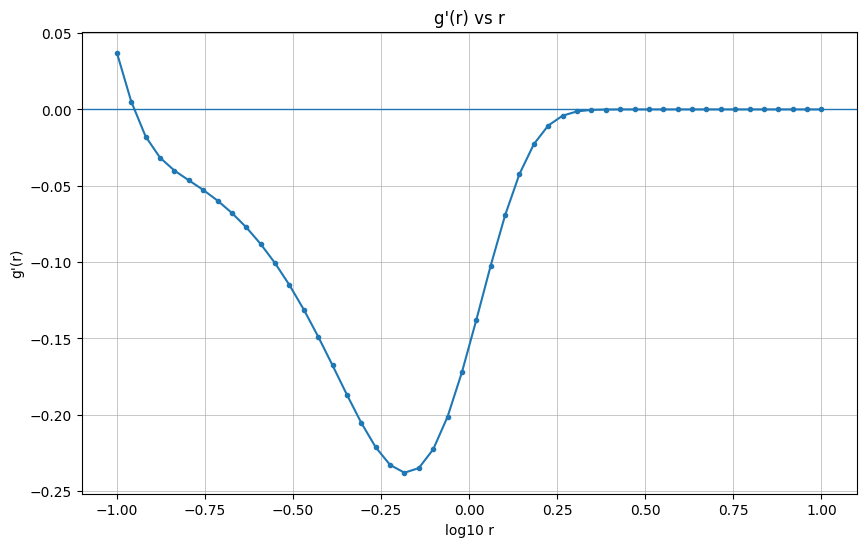

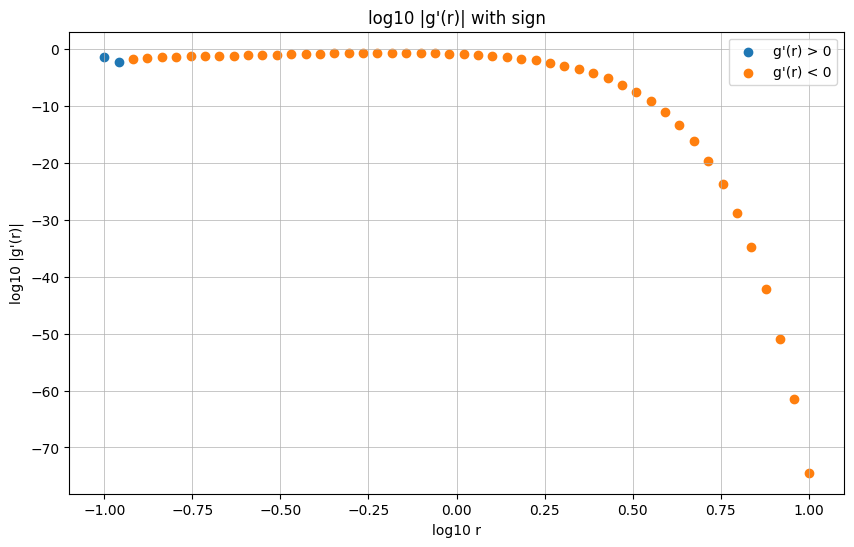

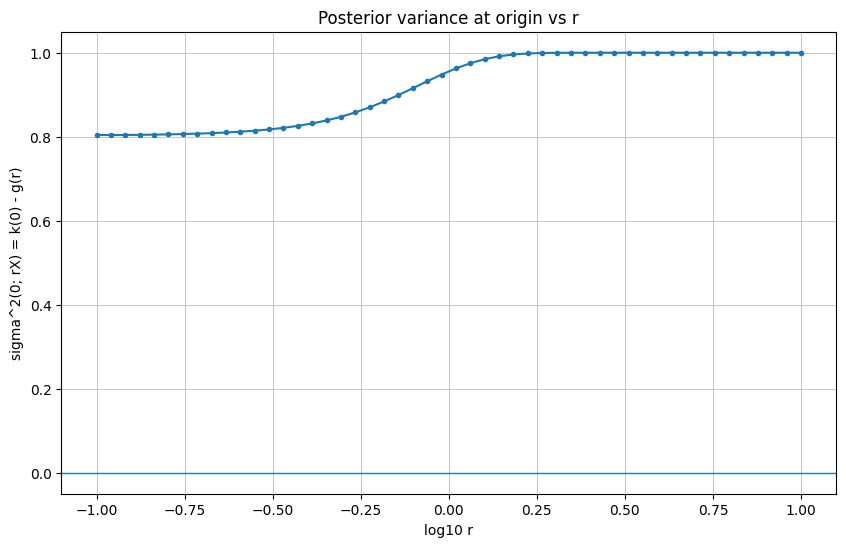

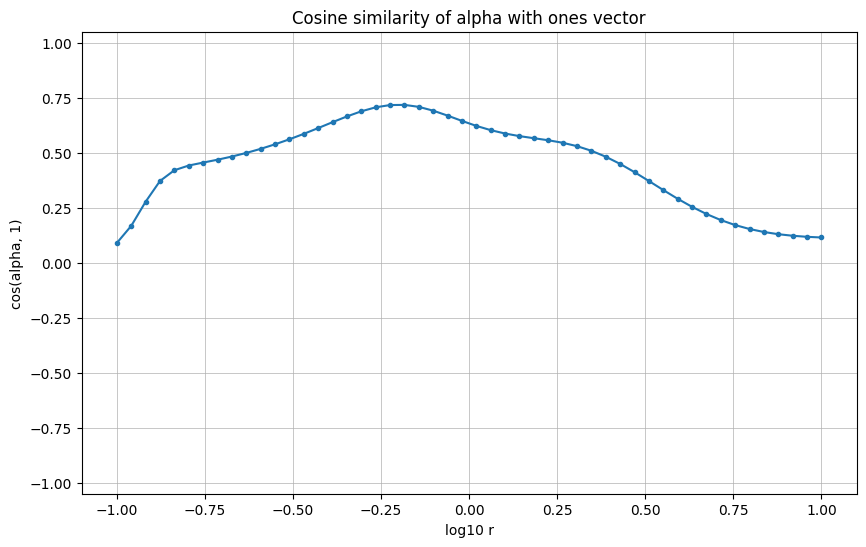

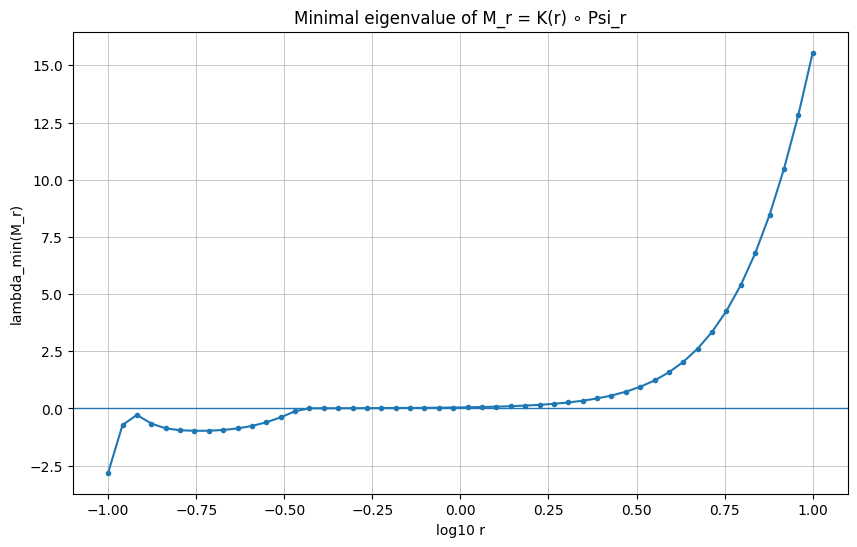

Computed points: 50
min g'(r): -0.237959274945
max g'(r): 0.0371464113064
count g'(r)>0: 2  / g'(r)<0: 48
min lambda_min(M_r): -2.81240662876
max lambda_min(M_r): 15.5537087904


In [83]:
import mpmath as mp
import numpy as np
import matplotlib.pyplot as plt

mp.mp.dps = 400

# ============================================================
# Designs (pick one)
# ============================================================

def simplex_custom_3d_mp(radius=mp.mpf("1")):
    r = mp.mpf(radius)
    V = [
        [ 0.2,  1,   0.9],
        [ 0.1, -0.1, -0.04],
        [-1,   1.2, -1],
        [-1.1,-1,    1],
        [ 0.2,-1,    0.4],
        [-1.3,-0.2,  2.1],
    ]
    out = []
    for v in V:
        norm = mp.sqrt(mp.mpf(v[0]*v[0] + v[1]*v[1] + v[2]*v[2]))
        out.append([r * mp.mpf(v[i]) / norm for i in range(3)])
    return out

def rotate_z_mp(X, theta):
    c = mp.cos(theta); s = mp.sin(theta)
    Y = []
    for x, y, z in X:
        Y.append([c*x - s*y, s*x + c*y, z])
    return Y

def regular_tetrahedron_unit_mp():
    V = [
        [ 1,  1,  1],
        [ 1, -1, -1],
        [-1,  1, -1],
        [-1, -1,  1],
    ]
    out = []
    for v in V:
        norm = mp.sqrt(mp.mpf(v[0]**2 + v[1]**2 + v[2]**2))  # sqrt(3)
        out.append([mp.mpf(v[i])/norm for i in range(3)])
    return out

def two_shell_design_3d_mp(R1=mp.mpf("1"), R2=mp.mpf("1.6"), theta=mp.pi/7):
    base = regular_tetrahedron_unit_mp()
    shell1 = [[R1*xi for xi in v] for v in base]
    shell2 = [[R2*xi for xi in v] for v in rotate_z_mp(base, mp.mpf(theta))]
    return shell1 + shell2

def two_clusters_3d_mp(n_per_cluster=8, R=mp.mpf("30"), delta=mp.mpf("1.0"),
                       separation=mp.mpf("20"), seed=mp.mpf("1.2345")):
    z1 = [R, mp.mpf("0"), mp.mpf("0")]
    z2 = [R, separation, mp.mpf("0")]
    out = []

    def unit_u(i, seed0):
        t1 = seed0 + mp.mpf(i)*mp.mpf("1.111")
        t2 = seed0 + mp.mpf(i)*mp.mpf("2.222")
        t3 = seed0 + mp.mpf(i)*mp.mpf("3.333")
        u = [mp.sin(t1), mp.sin(t2), mp.sin(t3)]
        u_norm = mp.sqrt(u[0]*u[0] + u[1]*u[1] + u[2]*u[2])
        if u_norm == 0:
            return [mp.mpf("1"), mp.mpf("0"), mp.mpf("0")]
        return [ui/u_norm for ui in u]

    for i in range(int(n_per_cluster)):
        u = unit_u(i, seed)
        out.append([z1[0] + delta*u[0], z1[1] + delta*u[1], z1[2] + delta*u[2]])

    seed2 = seed + mp.mpf("1000.0")
    for i in range(int(n_per_cluster)):
        u = unit_u(i, seed2)
        out.append([z2[0] + delta*u[0], z2[1] + delta*u[1], z2[2] + delta*u[2]])

    return out

# --- choose your design here ---
X = two_clusters_3d_mp(n_per_cluster=8, R=mp.mpf("30"), delta=mp.mpf("1.0"), separation=mp.mpf("20"))
# X = simplex_custom_3d_mp(radius=mp.mpf("1"))
# X = two_shell_design_3d_mp(R1=mp.mpf("1"), R2=mp.mpf("1.6"), theta=mp.pi/7)

# ============================================================
# Linear algebra (Cholesky + jitter)
# ============================================================

def mp_cholesky(A):
    n = A.rows
    L = mp.matrix(n, n)
    for i in range(n):
        for j in range(i + 1):
            s = mp.mpf("0")
            for k in range(j):
                s += L[i, k] * L[j, k]
            if i == j:
                val = A[i, i] - s
                if val <= 0:
                    raise ValueError(f"Matrix not PD at diag {i}: {val}")
                L[i, j] = mp.sqrt(val)
            else:
                L[i, j] = (A[i, j] - s) / L[j, j]
    return L

def mp_forward_sub(L, B):
    n, k = L.rows, B.cols
    X = mp.matrix(n, k)
    for col in range(k):
        for i in range(n):
            s = mp.mpf("0")
            for j in range(i):
                s += L[i, j] * X[j, col]
            X[i, col] = (B[i, col] - s) / L[i, i]
    return X

def mp_back_sub(U, B):
    n, k = U.rows, B.cols
    X = mp.matrix(n, k)
    for col in range(k):
        for i in reversed(range(n)):
            s = mp.mpf("0")
            for j in range(i + 1, n):
                s += U[i, j] * X[j, col]
            X[i, col] = (B[i, col] - s) / U[i, i]
    return X

def mp_chol_solve(A, B):
    L = mp_cholesky(A)
    Y = mp_forward_sub(L, B)
    return mp_back_sub(L.T, Y)

def mp_chol_solve_jitter(A, B, jitter_rel=mp.mpf("1e-40"), max_tries=12):
    n = A.rows
    diag_max = mp.mpf("0")
    for i in range(n):
        diag_max = max(diag_max, abs(A[i, i]))
    if diag_max == 0:
        diag_max = mp.mpf("1")

    jitter = jitter_rel * diag_max
    for _ in range(max_tries):
        Aj = mp.matrix(A)
        for i in range(n):
            Aj[i, i] += jitter
        try:
            return mp_chol_solve(Aj, B)
        except ValueError:
            jitter *= 10
    raise ValueError("Cholesky failed even with jitter.")

def mp_dot(u, v):
    return mp.fsum([u[i, 0] * v[i, 0] for i in range(u.rows)])

def mp_norm2_vec(v):
    return mp.sqrt(mp.fsum([v[i, 0]*v[i, 0] for i in range(v.rows)]))

def cosine_similarity_alpha_ones(alpha):
    n = alpha.rows
    ones_dot = mp.fsum([alpha[i, 0] for i in range(n)])
    denom = mp_norm2_vec(alpha) * mp.sqrt(mp.mpf(n))
    return ones_dot / denom if denom != 0 else mp.nan

# ============================================================
# Geometry helpers
# ============================================================

def dist2_mp(x, y):
    return mp.fsum([(x[i] - y[i])**2 for i in range(len(x))])

# ============================================================
# Kernel definition: Drift + Exp-Exp
#   eta(t) = b t + (1-exp(-t))
# ============================================================

b_param = mp.mpf("1e-3")

def eta_fun(t):
    t = mp.mpf(t)
    return b_param*t + (mp.mpf("1") - mp.e**(-t))

def eta_prime_fun(t):
    t = mp.mpf(t)
    return b_param + mp.e**(-t)

def k_and_kprime_r(r, t):
    """
    t = ||x-y||^2
    k_r = exp(-eta(r^2 t))
    d/dr k_r = -k_r * (2 r t eta'(r^2 t))
    """
    r = mp.mpf(r); t = mp.mpf(t)
    s = (r*r) * t
    k = mp.e ** (-eta_fun(s))
    dk = -k * (2*r*t*eta_prime_fun(s))
    return k, dk

def eta_r_prime(r, t):
    """
    eta_r'(x,y) = d/dr eta(r^2 ||x-y||^2) = 2 r t eta'(r^2 t)
    """
    r = mp.mpf(r); t = mp.mpf(t)
    s = (r*r) * t
    return 2*r*t*eta_prime_fun(s)

# ============================================================
# Core computation: g, g', alpha, var0, cos, lambda_min(M_r)
#   M_r = K(r) ∘ Psi_r,   Psi_r(i,j)=psi_r(x_i,x_j)
#   psi_r(x,y)=eta_r'(x,0)+eta_r'(y,0)-eta_r'(x,y)
# ============================================================

def compute_row(r, X, lam):
    r = mp.mpf(r); lam = mp.mpf(lam)
    n = len(X)
    d = len(X[0])
    x0 = [mp.mpf("0")]*d

    # precompute t_i0 and t_ij
    t_i0 = [dist2_mp(X[i], x0) for i in range(n)]
    t_ij = [[dist2_mp(X[i], X[j]) for j in range(n)] for i in range(n)]

    # Build K, K', a, a'
    K = mp.matrix(n, n)
    Kp = mp.matrix(n, n)
    a = mp.matrix(n, 1)
    ap = mp.matrix(n, 1)

    for i in range(n):
        k0, dk0 = k_and_kprime_r(r, t_i0[i])
        a[i, 0] = k0
        ap[i, 0] = dk0
        for j in range(n):
            kij, dkij = k_and_kprime_r(r, t_ij[i][j])
            K[i, j] = kij
            Kp[i, j] = dkij

    # Solve for alpha = (K+lam I)^{-1} a
    Klam = mp.matrix(K)
    for i in range(n):
        Klam[i, i] += lam
    alpha = mp_chol_solve_jitter(Klam, a)

    # g and g'
    g = mp_dot(a, alpha)
    gp = 2*mp_dot(ap, alpha) - mp_dot(alpha, Kp*alpha)

    # posterior variance at origin
    k00 = mp.e ** (-eta_fun(mp.mpf("0")))  # = 1
    var0 = k00 - g

    # cosine alignment with ones
    cos_a1 = cosine_similarity_alpha_ones(alpha)

    # Build Psi matrix from eta_r'
    Psi = mp.matrix(n, n)
    eta_i0 = [eta_r_prime(r, t_i0[i]) for i in range(n)]
    for i in range(n):
        for j in range(n):
            eta_ij = eta_r_prime(r, t_ij[i][j])
            Psi[i, j] = eta_i0[i] + eta_i0[j] - eta_ij

    # Hadamard product M = K ∘ Psi
    M = mp.matrix(n, n)
    for i in range(n):
        for j in range(n):
            M[i, j] = K[i, j] * Psi[i, j]

    # Minimal eigenvalue of symmetric M
    # mp.eigsy returns (eigenvalues, eigenvectors) for symmetric matrices
    evals = mp.eigsy(M)[0]
    lam_min = min([evals[i] for i in range(len(evals))])

    return {
        "r": r,
        "log10r": mp.log(r, 10),
        "g": g,
        "gp": gp,
        "var0": var0,
        "cos": cos_a1,
        "lam_min_M": lam_min,
    }

# ============================================================
# Run sweep
# ============================================================

lam = mp.mpf("1e-30")  # stabiliser (can set 0, but this helps conditioning)

a_exp = mp.mpf("-1")
b_exp = mp.mpf("1")
N = 50
r_exps = [a_exp + (b_exp - a_exp) * mp.mpf(i) / mp.mpf(N - 1) for i in range(N)]
r_vals = [mp.power(10, e) for e in r_exps]

rows = []
for r in r_vals:
    try:
        row = compute_row(r, X, lam)
        row["ok"] = True
        rows.append(row)
    except Exception:
        rows.append({"r": r, "log10r": mp.log(r,10), "ok": False})

rows_ok = [row for row in rows if row.get("ok", False)]

# ============================================================
# Convert for plotting
# ============================================================

log10r_f = np.array([float(row["log10r"]) for row in rows_ok], dtype=float)
gp_f     = np.array([float(row["gp"])     for row in rows_ok], dtype=float)
var0_f   = np.array([float(row["var0"])   for row in rows_ok], dtype=float)
cos_f    = np.array([float(row["cos"])    for row in rows_ok], dtype=float)
lammin_f = np.array([float(row["lam_min_M"]) for row in rows_ok], dtype=float)

tiny = mp.mpf("1e-300")
log10_abs_gp_f = np.array([float(mp.log(max(abs(row["gp"]), tiny), 10)) for row in rows_ok], dtype=float)
gp_sign_f = np.array([1.0 if row["gp"] > 0 else (-1.0 if row["gp"] < 0 else 0.0) for row in rows_ok], dtype=float)

# ============================================================
# Plots
# ============================================================

# g'(r) linear
plt.figure(figsize=(10, 6))
plt.plot(log10r_f, gp_f, marker=".", linestyle="-")
plt.axhline(0.0, linewidth=1.0)
plt.xlabel("log10 r")
plt.ylabel("g'(r)")
plt.title("g'(r) vs r")
plt.grid(True, which="both", linewidth=0.5)
plt.show()

# log10|g'(r)| with sign
plt.figure(figsize=(10, 6))
pos = gp_sign_f > 0
neg = gp_sign_f < 0
plt.scatter(log10r_f[pos], log10_abs_gp_f[pos], label="g'(r) > 0")
plt.scatter(log10r_f[neg], log10_abs_gp_f[neg], label="g'(r) < 0")
plt.xlabel("log10 r")
plt.ylabel("log10 |g'(r)|")
plt.title("log10 |g'(r)| with sign")
plt.grid(True, which="both", linewidth=0.5)
plt.legend()
plt.show()

# posterior variance
plt.figure(figsize=(10, 6))
plt.plot(log10r_f, var0_f, marker=".", linestyle="-")
plt.axhline(0.0, linewidth=1.0)
plt.xlabel("log10 r")
plt.ylabel("sigma^2(0; rX) = k(0) - g(r)")
plt.title("Posterior variance at origin vs r")
plt.grid(True, which="both", linewidth=0.5)
plt.show()

# cosine similarity
plt.figure(figsize=(10, 6))
plt.plot(log10r_f, cos_f, marker=".", linestyle="-")
plt.xlabel("log10 r")
plt.ylabel("cos(alpha, 1)")
plt.title("Cosine similarity of alpha with ones vector")
plt.grid(True, which="both", linewidth=0.5)
plt.ylim(-1.05, 1.05)
plt.show()

# NEW: lambda_min(M_r)
plt.figure(figsize=(10, 6))
plt.plot(log10r_f, lammin_f, marker=".", linestyle="-")
plt.axhline(0.0, linewidth=1.0)
plt.xlabel("log10 r")
plt.ylabel("lambda_min(M_r)")
plt.title("Minimal eigenvalue of M_r = K(r) ∘ Psi_r")
plt.grid(True, which="both", linewidth=0.5)
plt.show()

# ============================================================
# Summary diagnostics
# ============================================================

gp_min = min([row["gp"] for row in rows_ok])
gp_max = max([row["gp"] for row in rows_ok])
lammin_min = min([row["lam_min_M"] for row in rows_ok])
lammin_max = max([row["lam_min_M"] for row in rows_ok])

pos_count = sum([1 for row in rows_ok if row["gp"] > 0])
neg_count = sum([1 for row in rows_ok if row["gp"] < 0])

print("Computed points:", len(rows_ok))
print("min g'(r):", mp.nstr(gp_min, 12))
print("max g'(r):", mp.nstr(gp_max, 12))
print("count g'(r)>0:", pos_count, " / g'(r)<0:", neg_count)
print("min lambda_min(M_r):", mp.nstr(lammin_min, 12))
print("max lambda_min(M_r):", mp.nstr(lammin_max, 12))

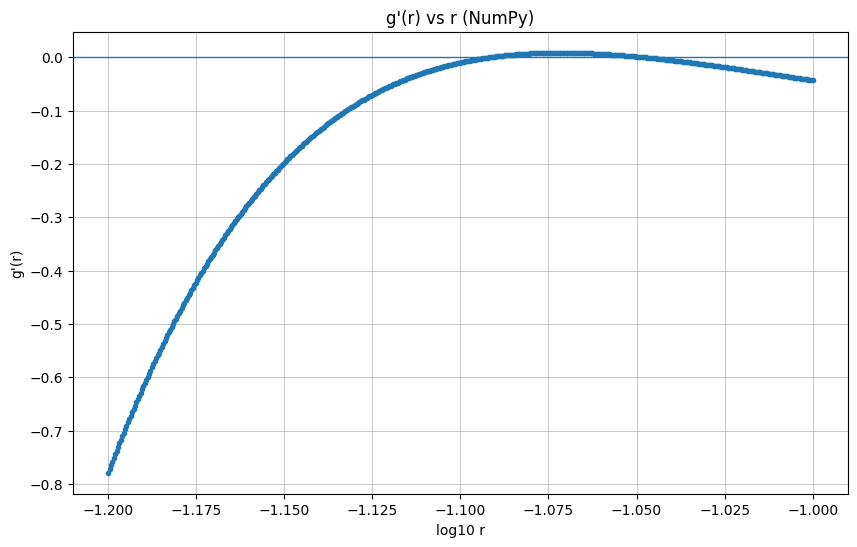

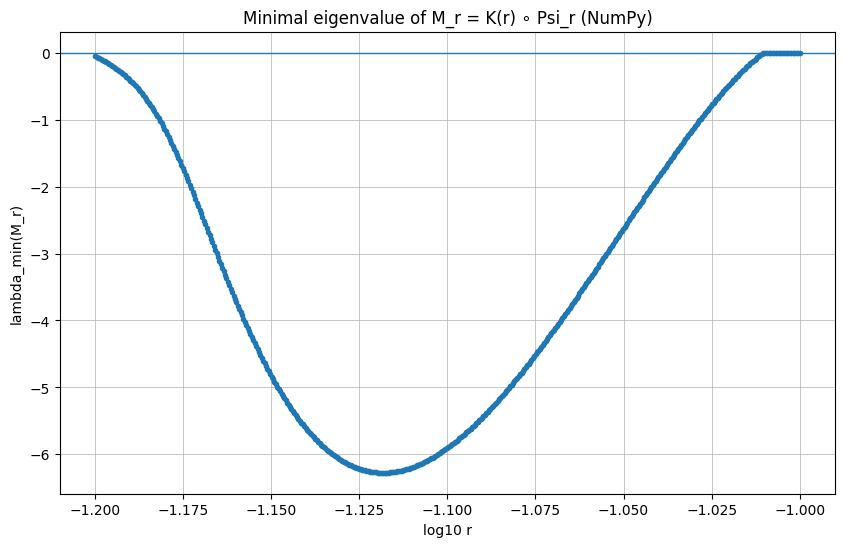

Computed points: 500
min g'(r): -0.7791772111832636
max g'(r): 0.008730749659216941
count g'(r)>0: 111  / g'(r)<0: 389
min var0(r): 0.8041192664536809
max var0(r): 0.8083463171354532
min lambda_min(M_r): -6.274897165603948
max lambda_min(M_r): 0.00011174763356044293


In [94]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Design (example: your two-cluster in R^3, deterministic)
# ============================================================

def two_clusters_3d_np(n_per_cluster=8, R=30.0, delta=1.0, separation=20.0, seed=1.2345):
    z1 = np.array([R, 0.0, 0.0], dtype=float)
    z2 = np.array([R, separation, 0.0], dtype=float)

    def unit_u(i, seed0):
        t1 = seed0 + i*1.111
        t2 = seed0 + i*2.222
        t3 = seed0 + i*3.333
        u = np.array([np.sin(t1), np.sin(t2), np.sin(t3)], dtype=float)
        nrm = np.linalg.norm(u)
        return u / (nrm if nrm != 0 else 1.0)

    pts = []
    for i in range(n_per_cluster):
        pts.append(z1 + delta*unit_u(i, seed))
    for i in range(n_per_cluster):
        pts.append(z2 + delta*unit_u(i, seed + 1000.0))
    return np.vstack(pts)

X = two_clusters_3d_np(n_per_cluster=8, R=30.0, delta=1.0, separation=20.0)

# ============================================================
# Kernel: Drift + Exp-Exp
#   eta(t) = b t + (1 - exp(-t))
#   eta'(t)= b + exp(-t)
# ============================================================

b_param = 2e-3 

def eta_np(t):
    return b_param*t + (1.0 - np.exp(-t))

def eta_prime_np(t):
    return b_param + np.exp(-t)

# ============================================================
# Geometry helpers: squared distances
# ============================================================

def sq_dists(X, Y):
    # returns matrix of ||x_i - y_j||^2
    X2 = np.sum(X*X, axis=1, keepdims=True)
    Y2 = np.sum(Y*Y, axis=1, keepdims=True).T
    return X2 + Y2 - 2.0*(X @ Y.T)

# Precompute distances that do NOT depend on r
D_ij = sq_dists(X, X)                # n x n
D_i0 = np.sum(X*X, axis=1)           # n

# ============================================================
# Build K, K', a, a', Psi, M, and compute metrics
# ============================================================

def compute_all_for_r(r, lam=1e-30):
    r = float(r)
    rr2 = (r*r)

    # K_ij = exp(-eta(r^2 D_ij))
    S_ij = rr2 * D_ij
    K = np.exp(-eta_np(S_ij))

    # K'_ij = d/dr exp(-eta(r^2 D)) = -K * (2 r D eta'(r^2 D))
    Kp = -K * (2.0*r * D_ij * eta_prime_np(S_ij))

    # a_i = exp(-eta(r^2 D_i0))
    S_i0 = rr2 * D_i0
    a = np.exp(-eta_np(S_i0))              # shape (n,)
    ap = -a * (2.0*r * D_i0 * eta_prime_np(S_i0))

    # Solve (K + lam I) alpha = a
    Klam = K + lam*np.eye(K.shape[0])
    alpha = np.linalg.solve(Klam, a)

    # g and g'
    g = a @ alpha
    gp = 2.0*(ap @ alpha) - alpha @ (Kp @ alpha)

    # var at origin (k00=exp(-eta(0))=1)
    var0 = 1.0 - g

    # cosine(alpha, 1)
    ones = np.ones_like(alpha)
    cos = (ones @ alpha) / (np.linalg.norm(ones) * np.linalg.norm(alpha))

    # Build Psi via eta_r'(x,y) = 2 r D_ij eta'(r^2 D_ij)
    eta_r_ij = 2.0*r * D_ij * eta_prime_np(S_ij)    # n x n
    eta_r_i0 = 2.0*r * D_i0 * eta_prime_np(S_i0)    # n

    # Psi_ij = eta_r'(xi,0) + eta_r'(xj,0) - eta_r'(xi,xj)
    Psi = eta_r_i0[:, None] + eta_r_i0[None, :] - eta_r_ij

    # M = K ∘ Psi (Hadamard)
    M = K * Psi

    # minimal eigenvalue (symmetric)
    lam_min = np.min(np.linalg.eigvalsh(0.5*(M + M.T)))

    return g, gp, var0, cos, lam_min

# ============================================================
# Sweep r
# ============================================================

r_vals = np.logspace(-1.2, -1, 500)
lam = 1e-30

g_list = np.empty_like(r_vals)
gp_list = np.empty_like(r_vals)
var_list = np.empty_like(r_vals)
cos_list = np.empty_like(r_vals)
lammin_list = np.empty_like(r_vals)

for i, r in enumerate(r_vals):
    g, gp, var0, cos, lam_min = compute_all_for_r(r, lam=lam)
    g_list[i] = g
    gp_list[i] = gp
    var_list[i] = var0
    cos_list[i] = cos
    lammin_list[i] = lam_min

log10r = np.log10(r_vals)

# ============================================================
# Plots
# ============================================================

plt.figure(figsize=(10,6))
plt.plot(log10r, gp_list, marker=".", linestyle="-")
plt.axhline(0.0, linewidth=1.0)
plt.xlabel("log10 r")
plt.ylabel("g'(r)")
plt.title("g'(r) vs r (NumPy)")
plt.grid(True, which="both", linewidth=0.5)
plt.show()

# log10|g'| with sign
# tiny = 1e-300
# plt.figure(figsize=(10,6))
# pos = gp_list > 0
# neg = gp_list < 0
# plt.scatter(log10r[pos], np.log10(np.maximum(np.abs(gp_list[pos]), tiny)), label="g'(r) > 0")
# plt.scatter(log10r[neg], np.log10(np.maximum(np.abs(gp_list[neg]), tiny)), label="g'(r) < 0")
# plt.xlabel("log10 r")
# plt.ylabel("log10 |g'(r)|")
# plt.title("log10 |g'(r)| with sign (NumPy)")
# plt.grid(True, which="both", linewidth=0.5)
# plt.legend()
# plt.show()

# plt.figure(figsize=(10,6))
# plt.plot(log10r, var_list, marker=".", linestyle="-")
# plt.axhline(0.0, linewidth=1.0)
# plt.xlabel("log10 r")
# plt.ylabel("sigma^2(0; rX) = 1 - g(r)")
# plt.title("Posterior variance at origin vs r (NumPy)")
# plt.grid(True, which="both", linewidth=0.5)
# plt.show()

# plt.figure(figsize=(10,6))
# plt.plot(log10r, cos_list, marker=".", linestyle="-")
# plt.xlabel("log10 r")
# plt.ylabel("cos(alpha, 1)")
# plt.title("Cosine similarity of alpha with ones vector (NumPy)")
# plt.ylim(-1.05, 1.05)
# plt.grid(True, which="both", linewidth=0.5)
# plt.show()

plt.figure(figsize=(10,6))
plt.plot(log10r, lammin_list, marker=".", linestyle="-")
plt.axhline(0.0, linewidth=1.0)
plt.xlabel("log10 r")
plt.ylabel("lambda_min(M_r)")
plt.title("Minimal eigenvalue of M_r = K(r) ∘ Psi_r (NumPy)")
plt.grid(True, which="both", linewidth=0.5)
plt.show()

# ============================================================
# Quick stats
# ============================================================

print("Computed points:", len(r_vals))
print("min g'(r):", gp_list.min())
print("max g'(r):", gp_list.max())
print("count g'(r)>0:", np.sum(gp_list > 0), " / g'(r)<0:", np.sum(gp_list < 0))
print("min var0(r):", var_list.min())
print("max var0(r):", var_list.max())
print("min lambda_min(M_r):", lammin_list.min())
print("max lambda_min(M_r):", lammin_list.max())

In [41]:
import math
import numpy as np

# ---------- Utilities ----------

def second_moment_matrix(X: np.ndarray) -> np.ndarray:
    """
    X: (n, d) with rows x_i^T
    S = (1/n) sum x_i x_i^T = (1/n) X^T X
    """
    n = X.shape[0]
    return (X.T @ X) / n

def is_proportional_to_identity(S: np.ndarray, tol: float = 1e-8):
    """
    Returns (bool, lambda) where lambda satisfies S ~ lambda I.
    """
    d = S.shape[0]
    lam = np.trace(S) / d
    err = np.linalg.norm(S - lam * np.eye(d), ord='fro') / max(np.linalg.norm(S, ord='fro'), 1e-16)
    return (err <= tol), lam, err

def bisect_root(f, a, b, max_iter=200, tol=1e-10):
    """
    Simple bisection method. Requires f(a)*f(b) <= 0.
    """
    fa, fb = f(a), f(b)
    if not (np.isfinite(fa) and np.isfinite(fb)):
        raise ValueError("Non-finite f(a) or f(b).")
    if fa == 0:
        return a
    if fb == 0:
        return b
    if fa * fb > 0:
        raise ValueError("Bisection requires a sign change on [a,b].")

    lo, hi = a, b
    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        fm = f(mid)
        if not np.isfinite(fm):
            # try to shrink interval conservatively
            hi = mid
            continue
        if abs(fm) < tol or (hi - lo) < tol:
            return mid
        if fa * fm <= 0:
            hi, fb = mid, fm
        else:
            lo, fa = mid, fm
    return 0.5 * (lo + hi)

def bracket_roots(f, s_min, s_max, n_grid=2000):
    """
    Scan on a grid and return intervals [a,b] where f changes sign.
    """
    xs = np.linspace(s_min, s_max, n_grid)
    ys = np.array([f(x) for x in xs], dtype=float)
    intervals = []
    for i in range(len(xs) - 1):
        y1, y2 = ys[i], ys[i+1]
        if not (np.isfinite(y1) and np.isfinite(y2)):
            continue
        if y1 == 0:
            intervals.append((xs[i], xs[i]))
        elif y1 * y2 < 0:
            intervals.append((xs[i], xs[i+1]))
    return intervals

# ---------- Kernel example: RBF / squared exponential ----------
# k(x,y) = exp(-||x-y||^2/(2 ell^2)) => kappa(s)=exp(-s/(2 ell^2))

def make_rbf_kappa(ell: float):
    c = 1.0 / (2.0 * ell * ell)

    def kappa(s):
        return math.exp(-c * s)

    def kappa_p(s):
        return -c * math.exp(-c * s)

    def kappa_pp(s):
        return (c * c) * math.exp(-c * s)

    return kappa, kappa_p, kappa_pp

# ---------- Construct x* such that gamma2 = 0 ----------

def gamma2_equation_components(R2, kappa0, kappa_p0, kappa, kappa_p, kappa_pp):
    """
    Returns A(s) and B(s) such that gamma2 condition is:
        A(s) - B(s) * x*^T S x* = 0
    with B(s) = 2 kappa''(s)
    and A(s) = R^2( (kappa'(0)/kappa(0))*kappa(s) - kappa'(s) )
    """
    def A(s):
        return R2 * ((kappa_p0 / kappa0) * kappa(s) - kappa_p(s))
    def B(s):
        return 2.0 * kappa_pp(s)
    return A, B

def pick_direction_for_rayleigh(S, target_q):
    """
    Given symmetric PSD S and target_q in [lam_min, lam_max],
    returns a unit vector u with u^T S u = target_q (up to floating error),
    using only the min/max eigenvectors.
    """
    evals, evecs = np.linalg.eigh(S)
    lam_min, lam_max = float(evals[0]), float(evals[-1])
    v_min, v_max = evecs[:, 0], evecs[:, -1]

    if target_q < lam_min - 1e-12 or target_q > lam_max + 1e-12:
        raise ValueError("target_q out of achievable Rayleigh quotient interval.")

    if abs(lam_max - lam_min) < 1e-15:
        # S is proportional to identity; any unit vector works
        u = np.zeros(S.shape[0])
        u[0] = 1.0
        return u

    # Solve lam_min * cos^2 + lam_max * sin^2 = target_q
    t = (target_q - lam_min) / (lam_max - lam_min)
    t = min(max(t, 0.0), 1.0)  # clamp
    sin = math.sqrt(t)
    cos = math.sqrt(1.0 - t)
    u = cos * v_min + sin * v_max
    u = u / np.linalg.norm(u)
    return u

def solve_xstars_gamma2_zero(
    X: np.ndarray,
    R: float,
    m: int,
    kappa, kappa_p, kappa_pp,
    s_min: float = 1e-6,
    s_max: float = 50.0,
    n_scan: int = 4000,
    tol_iso: float = 1e-8,
):
    """
    Attempts to construct m points x*_j such that gamma2_j = 0.

    Returns:
        xstars: (m,d) array
        info: dict with diagnostic info
    """
    n, d = X.shape
    S = second_moment_matrix(X)
    is_iso, lam, err = is_proportional_to_identity(S, tol=tol_iso)

    k0 = kappa(0.0)
    kp0 = kappa_p(0.0)
    R2 = R * R

    A, B = gamma2_equation_components(R2, k0, kp0, kappa, kappa_p, kappa_pp)

    info = {
        "S": S,
        "isotropic_S": is_iso,
        "lambda_if_iso": lam,
        "iso_error": err,
    }

    xstars = []

    if is_iso:
        # Condition becomes: A(s) - B(s) * (lam * s) = 0
        def f(s):
            return A(s) - B(s) * (lam * s)

        intervals = bracket_roots(f, s_min, s_max, n_grid=n_scan)
        if not intervals:
            info["status"] = "no_roots_found_in_range"
            return np.zeros((0, d)), info

        # Use up to m roots; pick arbitrary directions (since isotropic)
        roots = []
        for (a, b) in intervals:
            if a == b:
                roots.append(a)
            else:
                try:
                    roots.append(bisect_root(f, a, b))
                except Exception:
                    continue
            if len(roots) >= m:
                break

        for s in roots:
            # arbitrary unit vector
            u = np.zeros(d); u[0] = 1.0
            xstars.append(math.sqrt(s) * u)

        info["status"] = "ok"
        info["mode"] = "isotropic"
        info["roots_s"] = roots
        return np.vstack(xstars), info

    # Anisotropic S:
    # Need u^T S u = q(s) := A(s)/(B(s)*s)
    evals = np.linalg.eigvalsh(S)
    lam_min, lam_max = float(evals[0]), float(evals[-1])
    info["lam_min"] = lam_min
    info["lam_max"] = lam_max

    def q(s):
        Bs = B(s)
        if abs(Bs) < 1e-16:
            return np.nan
        return A(s) / (Bs * s)

    # Find radii where q(s) lies in [lam_min, lam_max]
    # We'll scan and pick s-values where feasible, then choose u accordingly.
    ss = np.linspace(s_min, s_max, n_scan)
    qs = np.array([q(s) for s in ss], dtype=float)
    feasible = np.isfinite(qs) & (qs >= lam_min) & (qs <= lam_max)

    if not np.any(feasible):
        info["status"] = "no_feasible_radii_in_range"
        return np.zeros((0, d)), info

    # Pick m feasible radii spread out
    idxs = np.where(feasible)[0]
    pick = np.linspace(0, len(idxs) - 1, num=min(m, len(idxs))).astype(int)
    chosen_s = [float(ss[idxs[i]]) for i in pick]

    for s in chosen_s:
        target_q = float(q(s))
        u = pick_direction_for_rayleigh(S, target_q)
        xstars.append(math.sqrt(s) * u)

    info["status"] = "ok"
    info["mode"] = "anisotropic"
    info["chosen_s"] = chosen_s
    info["chosen_q"] = [float(q(s)) for s in chosen_s]
    return np.vstack(xstars), info

# ---------- Example usage ----------
if __name__ == "__main__":
    # Example local design: cross polytope in d=3 (isotropic second moment)
    d = 3
    R = 1.0
    X = np.vstack([np.eye(d), -np.eye(d)]) * R  # n=6, centred, spherical, isotropic S

    kappa, kappa_p, kappa_pp = make_rbf_kappa(ell=1.2)

    xstars, info = solve_xstars_gamma2_zero(
        X=X, R=R, m=4,
        kappa=kappa, kappa_p=kappa_p, kappa_pp=kappa_pp,
        s_min=1e-4, s_max=50.0
    )

    print("mode:", info.get("mode"), "status:", info["status"])
    print("isotropic S:", info["isotropic_S"], "iso_err:", info["iso_error"])
    print("xstars:\n", xstars)

mode: None status: no_roots_found_in_range
isotropic S: True iso_err: 0.0
xstars:
 []


In [95]:
import numpy as np

# ============================================================
# 1) Kernel model: k(h) = exp(-eta(h)), h = r^2 * d^2
#    Provide eta and eta'(t) for your kernel.
# ============================================================

def eta_expexp(t: np.ndarray) -> np.ndarray:
    # eta(t) = 1 - exp(-t)
    return 1.0 - np.exp(-t)

def eta_expexp_prime(t: np.ndarray) -> np.ndarray:
    # eta'(t) = exp(-t)
    return np.exp(-t)

def make_eta_drift_expexp(b: float):
    # eta(t) = b t + (1 - exp(-t)), eta'(t) = b + exp(-t)
    def eta(t):
        return b * t + (1.0 - np.exp(-t))
    def eta_prime(t):
        return b + np.exp(-t)
    return eta, eta_prime

# Pick kernel here:
eta_fun = eta_expexp
eta_prime_fun = eta_expexp_prime
# eta_fun, eta_prime_fun = make_eta_drift_expexp(b=1e-3)

# ============================================================
# 2) Scalar helpers: for a given distance d, build:
#    k(d) = exp(-eta(r^2 d^2))
#    q(d) = 2 r d^2 eta'(r^2 d^2)   (this is eta_r'(x,y) when ||x-y||=d)
#    dk/dr = -k * q(d)
# ============================================================

def k_of_d(r: float, d: float) -> float:
    s = (r * r) * (d * d)
    return float(np.exp(-eta_fun(np.array(s))))

def q_of_d(r: float, d: float) -> float:
    s = (r * r) * (d * d)
    return float(2.0 * r * (d * d) * eta_prime_fun(np.array(s)))

def dk_dr_of_d(r: float, d: float) -> float:
    k = k_of_d(r, d)
    q = q_of_d(r, d)
    return -k * q

# ============================================================
# 3) Build the 2-block constant-distance K and a
#
# Block structure: size m each, total n=2m
# Within-block: diag k0, offdiag k_delta
# Cross-block: all entries k_Delta
# a: all entries k_R (same radius assumption)
# ============================================================

def build_K_a_Kp_ap(r: float, m: int, R: float, delta: float, Delta: float):
    n = 2 * m

    k0 = k_of_d(r, 0.0)
    k_delta = k_of_d(r, delta)
    k_Delta = k_of_d(r, Delta)
    k_R = k_of_d(r, R)

    # Derivatives wrt r
    dk0 = dk_dr_of_d(r, 0.0)        # will be 0
    dk_delta = dk_dr_of_d(r, delta)
    dk_Delta = dk_dr_of_d(r, Delta)
    dk_R = dk_dr_of_d(r, R)

    # K
    K = np.empty((n, n), dtype=float)
    # block indices
    idx1 = slice(0, m)
    idx2 = slice(m, 2*m)

    # fill within blocks
    K[idx1, idx1] = k_delta
    np.fill_diagonal(K[idx1, idx1], k0)

    K[idx2, idx2] = k_delta
    np.fill_diagonal(K[idx2, idx2], k0)

    # cross blocks
    K[idx1, idx2] = k_Delta
    K[idx2, idx1] = k_Delta

    # K'
    Kp = np.empty((n, n), dtype=float)
    Kp[idx1, idx1] = dk_delta
    np.fill_diagonal(Kp[idx1, idx1], dk0)

    Kp[idx2, idx2] = dk_delta
    np.fill_diagonal(Kp[idx2, idx2], dk0)

    Kp[idx1, idx2] = dk_Delta
    Kp[idx2, idx1] = dk_Delta

    # a, a'
    a = np.full((n, 1), k_R, dtype=float)
    ap = np.full((n, 1), dk_R, dtype=float)

    # also return scalars used in closed form
    scalars = dict(
        k0=k0, k_delta=k_delta, k_Delta=k_Delta, k_R=k_R,
        dk0=dk0, dk_delta=dk_delta, dk_Delta=dk_Delta, dk_R=dk_R,
    )
    return K, a, Kp, ap, scalars

# ============================================================
# 4) Compute g'(r) two ways:
#    (i) general: gp = 2 ap^T alpha - alpha^T Kp alpha, alpha=K^{-1}a
#    (ii) closed: gp_closed = -2m beta^2 (D+mE)
# ============================================================

def gp_general(r: float, m: int, R: float, delta: float, Delta: float, ridge: float = 0.0):
    K, a, Kp, ap, sc = build_K_a_Kp_ap(r, m, R, delta, Delta)
    if ridge > 0:
        K = K + ridge * np.eye(K.shape[0])
    alpha = np.linalg.solve(K, a)
    gp = float(2.0 * (ap.T @ alpha) - (alpha.T @ (Kp @ alpha)))
    return gp, alpha, sc

def gp_closed_form(r: float, m: int, R: float, delta: float, Delta: float):
    # kernel scalars
    k0 = k_of_d(r, 0.0)
    k_delta = k_of_d(r, delta)
    k_Delta = k_of_d(r, Delta)
    k_R = k_of_d(r, R)

    # q scalars
    q_R = q_of_d(r, R)
    q_delta = q_of_d(r, delta)
    q_Delta = q_of_d(r, Delta)

    A = k0 + (m - 1) * k_delta
    B = m * k_Delta
    beta = k_R / (A + B)

    D = 2.0 * q_R * k0 + (m - 1) * (2.0 * q_R - q_delta) * k_delta
    E = (2.0 * q_R - q_Delta) * k_Delta

    gp_closed = -2.0 * m * (beta ** 2) * (D + m * E)

    # return all intermediates for debugging
    info = dict(
        k0=k0, k_delta=k_delta, k_Delta=k_Delta, k_R=k_R,
        q_R=q_R, q_delta=q_delta, q_Delta=q_Delta,
        A=A, B=B, beta=beta, D=D, E=E, D_plus_mE=(D + m*E),
    )
    return gp_closed, info

# ============================================================
# 5) Run a check at one parameter point (edit freely)
# ============================================================

if __name__ == "__main__":
    # Pick parameters
    r = 1.2
    m = 7
    R = 30.0
    delta = 1.0
    Delta = 20.0
    ridge = 0.0  # set tiny e.g. 1e-12 if K gets ill-conditioned

    gp1, alpha, sc = gp_general(r, m, R, delta, Delta, ridge=ridge)
    gp2, info = gp_closed_form(r, m, R, delta, Delta)

    # alpha should be (approximately) constant if your reduction is correct
    alpha_flat = alpha.ravel()
    alpha_mean = alpha_flat.mean()
    alpha_std = alpha_flat.std()

    # beta from closed form vs alpha entries
    beta = info["beta"]

    # errors
    abs_err = abs(gp1 - gp2)
    rel_err = abs_err / max(1.0, abs(gp1), abs(gp2))

    print("=== Algebra check: identical 2-block reduction ===")
    print(f"r={r}, m={m}, R={R}, delta={delta}, Delta={Delta}, ridge={ridge}")
    print()
    print(f"gp_general     = {gp1:.16e}")
    print(f"gp_closed_form = {gp2:.16e}")
    print(f"abs error      = {abs_err:.3e}")
    print(f"rel error      = {rel_err:.3e}")
    print()
    print("--- alpha constancy check ---")
    print(f"alpha mean     = {alpha_mean:.16e}")
    print(f"alpha std      = {alpha_std:.3e}")
    print(f"beta (closed)  = {beta:.16e}")
    print(f"max |alpha_i - beta| = {np.max(np.abs(alpha_flat - beta)):.3e}")
    print()
    print("--- sign driver ---")
    print(f"D+mE = {info['D_plus_mE']:.16e}")
    print("Prediction: gp>0 iff D+mE<0")
    print(f"gp_closed sign = {'+' if gp2>0 else '-' if gp2<0 else '0'}")

=== Algebra check: identical 2-block reduction ===
r=1.2, m=7, R=30.0, delta=1.0, Delta=20.0, ridge=0.0

gp_general     = 7.4215279618576241e-02
gp_closed_form = 7.4215279618576227e-02
abs error      = 1.388e-17
rel error      = 1.388e-17

--- alpha constancy check ---
alpha mean     = 5.7728790560784046e-02
alpha std      = 3.053e-17
beta (closed)  = 5.7728790560784025e-02
max |alpha_i - beta| = 7.633e-17

--- sign driver ---
D+mE = -1.5906710405232727e+00
Prediction: gp>0 iff D+mE<0
gp_closed sign = +


/var/folders/y9/f2jq2rkn6h16kl4g9j02c2800000gn/T/ipykernel_31731/2426409605.py:122: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gp = float(2.0 * (ap.T @ alpha) - (alpha.T @ (Kp @ alpha)))


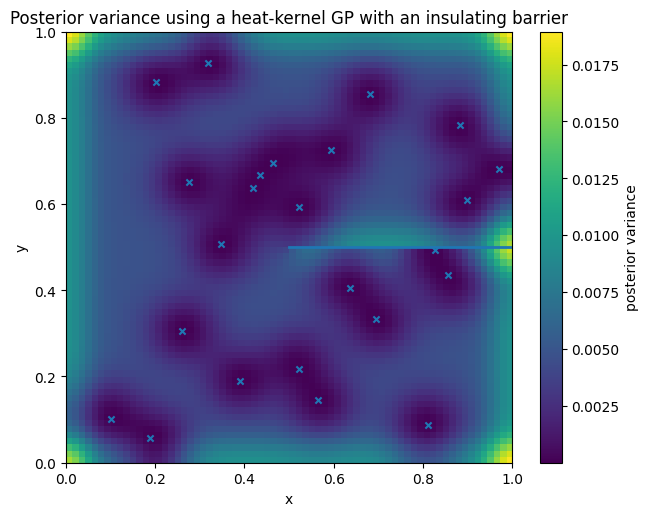

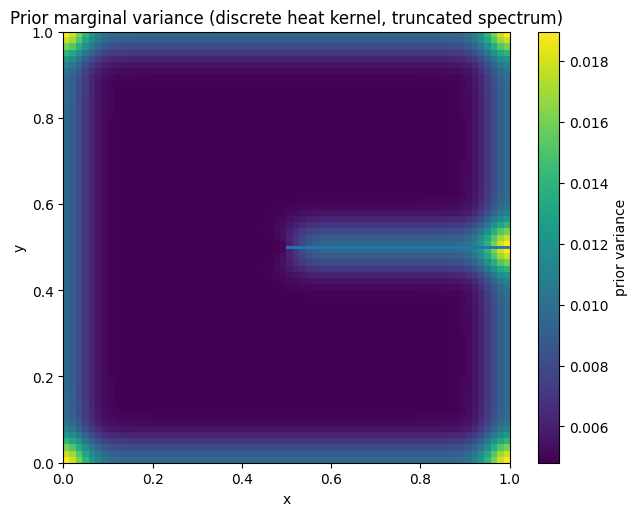

(24,
 array([1.21716722e-12, 3.96668728e+00, 9.58802039e+00, 1.57254941e+01,
        3.83327726e+01]),
 2690.560223554406)

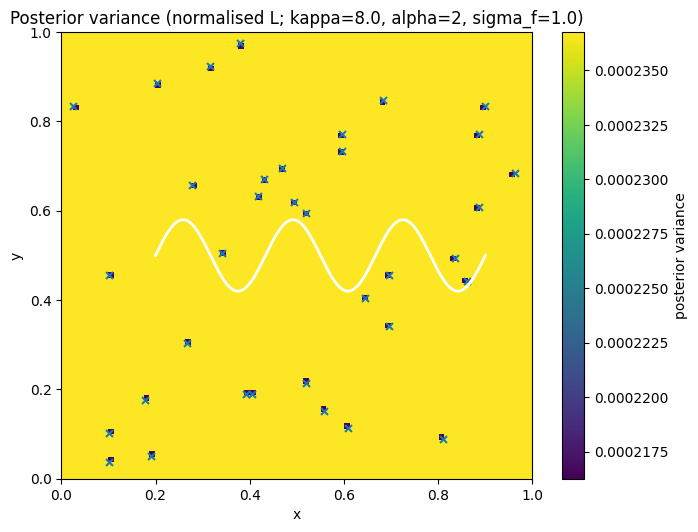

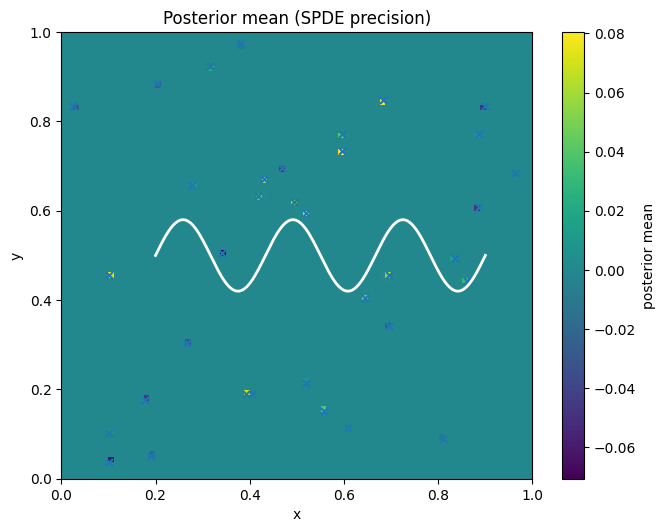

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse.linalg import splu

# ----------------------------
# Geometry: segment intersection (robust enough for grid edges)
# ----------------------------
def _orient(a, b, c):
    return (b[0]-a[0])*(c[1]-a[1]) - (b[1]-a[1])*(c[0]-a[0])

def _on_segment(a, b, c):
    return (min(a[0], b[0]) <= c[0] <= max(a[0], b[0]) and
            min(a[1], b[1]) <= c[1] <= max(a[1], b[1]))

def segments_intersect(p1, p2, q1, q2, eps=1e-12):
    o1 = _orient(p1, p2, q1)
    o2 = _orient(p1, p2, q2)
    o3 = _orient(q1, q2, p1)
    o4 = _orient(q1, q2, p2)

    if (o1 * o2 < -eps) and (o3 * o4 < -eps):
        return True

    if abs(o1) <= eps and _on_segment(p1, p2, q1): return True
    if abs(o2) <= eps and _on_segment(p1, p2, q2): return True
    if abs(o3) <= eps and _on_segment(q1, q2, p1): return True
    if abs(o4) <= eps and _on_segment(q1, q2, p2): return True

    return False

def edge_crosses_polyline(p, r, curve_pts):
    for k in range(len(curve_pts) - 1):
        q = curve_pts[k]
        s = curve_pts[k + 1]
        if segments_intersect(p, r, q, s):
            return True
    return False


# ----------------------------
# Build adjacency W (not Laplacian directly) with arbitrary barrier curve
# ----------------------------
def build_adjacency_with_barrier_curve(N, curve_pts=None):
    """
    N x N grid over [0,1]^2. Build 4-neighbour adjacency W.
    Remove any edge that intersects the barrier polyline.
    """
    xs = np.linspace(0.0, 1.0, N)
    ys = np.linspace(0.0, 1.0, N)
    h = xs[1] - xs[0]

    def idx(i, j): return i * N + j

    rows, cols, data = [], [], []

    def add_edge(a, b, w):
        rows.extend([a, b])
        cols.extend([b, a])
        data.extend([w, w])

    # Use unit weights for adjacency; we'll handle scaling separately
    w_edge = 1.0

    for i in range(N):
        for j in range(N):
            a = idx(i, j)
            p = np.array([xs[i], ys[j]])

            # right neighbour
            if i + 1 < N:
                b = idx(i + 1, j)
                r = np.array([xs[i + 1], ys[j]])
                if curve_pts is None or not edge_crosses_polyline(p, r, curve_pts):
                    add_edge(a, b, w_edge)

            # up neighbour
            if j + 1 < N:
                b = idx(i, j + 1)
                r = np.array([xs[i], ys[j + 1]])
                if curve_pts is None or not edge_crosses_polyline(p, r, curve_pts):
                    add_edge(a, b, w_edge)

    W = sparse.coo_matrix((data, (rows, cols)), shape=(N * N, N * N)).tocsr()
    return W, xs, ys, h


# ----------------------------
# Laplacians: unnormalised and symmetric-normalised
# ----------------------------
def unnormalised_laplacian(W):
    d = np.array(W.sum(axis=1)).ravel()
    L = sparse.diags(d) - W
    return L, d

def symmetric_normalised_laplacian(W, eps=1e-12):
    """
    L_sym = I - D^{-1/2} W D^{-1/2}
    """
    d = np.array(W.sum(axis=1)).ravel()
    inv_sqrt_d = 1.0 / np.sqrt(np.maximum(d, eps))
    Dm12 = sparse.diags(inv_sqrt_d)
    Lsym = sparse.eye(W.shape[0], format="csr") - (Dm12 @ W @ Dm12)
    return Lsym, d


# ----------------------------
# SPDE precision with sane scaling + amplitude
# ----------------------------
def build_precision_from_laplacian(L, kappa=8.0, alpha=2, sigma_f=1.0):
    """
    Q = (kappa^2 I + L)^alpha / sigma_f^2

    IMPORTANT: L is assumed to be dimensionless / well-scaled.
    """
    n = L.shape[0]
    A = L + (kappa ** 2) * sparse.eye(n, format="csr")

    if alpha == 1:
        Q = A
    elif alpha == 2:
        Q = (A @ A).tocsr()
    else:
        raise ValueError("Use alpha=1 or alpha=2 for this demo.")

    # Amplitude scaling
    Q = Q / (sigma_f ** 2)
    return Q


# ----------------------------
# Exact posterior marginal variances via batched solves
# ----------------------------
def exact_diag_inverse_from_lu(lu, n, batch=64):
    diag = np.zeros(n)
    Icols = np.zeros((n, batch))
    for start in range(0, n, batch):
        bsz = min(batch, n - start)
        Icols[:] = 0.0
        Icols[start:start + bsz, :bsz] = np.eye(bsz)
        X = lu.solve(Icols[:, :bsz])
        diag[start:start + bsz] = np.diag(X[start:start + bsz, :])
    return diag

def posterior_from_precision(Q, obs_nodes, y_obs, sigma=0.05, batch=64):
    """
    Prior: f ~ N(0, Q^{-1})
    Likelihood: y = f(obs_nodes) + eps, eps ~ N(0, sigma^2 I)
    """
    n = Q.shape[0]
    obs_nodes = np.asarray(obs_nodes, dtype=int)
    y_obs = np.asarray(y_obs, dtype=float)

    diag_add = np.zeros(n)
    diag_add[obs_nodes] = 1.0 / (sigma ** 2)
    Q_post = Q + sparse.diags(diag_add, format="csr")

    b = np.zeros(n)
    b[obs_nodes] = y_obs / (sigma ** 2)

    lu = splu(Q_post.tocsc())
    mean = lu.solve(b)
    var = exact_diag_inverse_from_lu(lu, n, batch=batch)
    var = np.maximum(var, 0.0)
    return mean, var

def prior_variance_from_precision(Q, batch=64):
    """
    Compute diag(Q^{-1}) exactly (can be useful for debugging scaling).
    """
    lu = splu(Q.tocsc())
    var = exact_diag_inverse_from_lu(lu, Q.shape[0], batch=batch)
    return np.maximum(var, 0.0)


# ----------------------------
# Demo
# ----------------------------
# Barrier curve: wavy polyline
ts = np.linspace(0, 1, 300)
curve_pts = np.c_[0.2 + 0.7 * ts, 0.5 + 0.08 * np.sin(6 * np.pi * ts)]

N = 80

# Build adjacency with barrier
W, xs, ys, h = build_adjacency_with_barrier_curve(N=N, curve_pts=curve_pts)

# Choose which Laplacian to use:
# (1) Symmetric normalised Laplacian -> much less "variance spike on cut"
L, deg = symmetric_normalised_laplacian(W)

# Optional: If you want the unnormalised Laplacian, uncomment:
# L, deg = unnormalised_laplacian(W)

# Key scaling upgrade:
# If you use UNnormalised Laplacian built from unit weights, it is already dimensionless-ish.
# If you had used 1/h^2 weights, you'd need L *= h*h. Here we don't.
# If you still want to calibrate to physical diffusion scale, you can optionally do:
# L = (1.0) * L

# SPDE parameters (now interpretable)
kappa = 8.0      # try 4..20; smaller = longer-range correlation
alpha = 2        # 1 or 2; 2 smoother
sigma_f = 1.0    # prior marginal scale (roughly)

Q = build_precision_from_laplacian(L, kappa=kappa, alpha=alpha, sigma_f=sigma_f)

# Sample observation locations on grid
rng = np.random.default_rng(2)
n_obs = 35
X_obs = rng.uniform(0, 1, size=(n_obs, 2))
i_obs = np.clip(np.round(X_obs[:, 0] * (N - 1)).astype(int), 0, N - 1)
j_obs = np.clip(np.round(X_obs[:, 1] * (N - 1)).astype(int), 0, N - 1)
obs_nodes = np.unique(i_obs * N + j_obs)

# Fake observations (replace with your evaluations)
def f_true(x, y):
    return np.sin(2 * np.pi * x) * np.cos(2 * np.pi * y)

y_clean = np.array([f_true(xs[i], ys[j]) for (i, j) in zip(i_obs, j_obs)])
sigma = 0.05
y_obs = y_clean + sigma * rng.standard_normal(size=y_clean.shape)

# Posterior mean + variance (exact diagonal)
mean, var = posterior_from_precision(Q, obs_nodes, y_obs, sigma=sigma, batch=64)

# (Optional) prior variance for comparison/debug
# prior_var = prior_variance_from_precision(Q, batch=64)

# Reshape for plotting
mean_grid = mean.reshape(N, N).T
var_grid = var.reshape(N, N).T
# prior_var_grid = prior_var.reshape(N, N).T

# Plot posterior variance
fig, ax = plt.subplots(figsize=(7.6, 5.8))
im = ax.imshow(var_grid, origin="lower", extent=[0, 1, 0, 1], aspect="auto")
ax.scatter(xs[i_obs], ys[j_obs], s=25, marker="x")
ax.plot(curve_pts[:, 0], curve_pts[:, 1], linewidth=2, color="white")
ax.set_title(f"Posterior variance (normalised L; kappa={kappa}, alpha={alpha}, sigma_f={sigma_f})")
ax.set_xlabel("x"); ax.set_ylabel("y")
fig.colorbar(im, ax=ax, label="posterior variance")
plt.show()

# Plot posterior mean
fig2, ax2 = plt.subplots(figsize=(7.6, 5.8))
im2 = ax2.imshow(mean_grid, origin="lower", extent=[0, 1, 0, 1], aspect="auto")
ax2.scatter(xs[i_obs], ys[j_obs], s=25, marker="x")
ax2.plot(curve_pts[:, 0], curve_pts[:, 1], linewidth=2, color="white")
ax2.set_title("Posterior mean (SPDE precision)")
ax2.set_xlabel("x"); ax2.set_ylabel("y")
fig2.colorbar(im2, ax=ax2, label="posterior mean")
plt.show()

# If you want to see the prior variance too, uncomment this block:
# fig3, ax3 = plt.subplots(figsize=(7.6, 5.8))
# im3 = ax3.imshow(prior_var_grid, origin="lower", extent=[0, 1, 0, 1], aspect="auto")
# ax3.plot(curve_pts[:, 0], curve_pts[:, 1], linewidth=2, color="white")
# ax3.set_title("Prior marginal variance (for scale sanity check)")
# ax3.set_xlabel("x"); ax3.set_ylabel("y")
# fig3.colorbar(im3, ax=ax3, label="prior variance")
# plt.show()

In [22]:
var

array([5.03261692e-07, 4.78991962e-07, 4.49429930e-07, ...,
       4.49520551e-07, 4.79081583e-07, 5.03350846e-07])

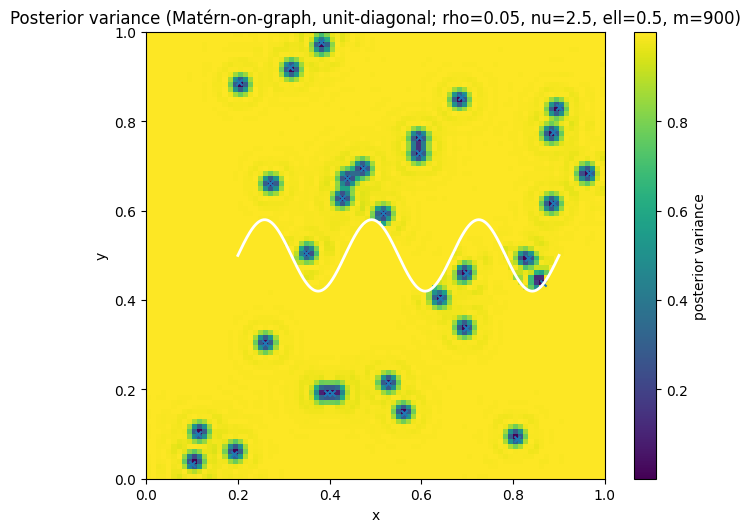

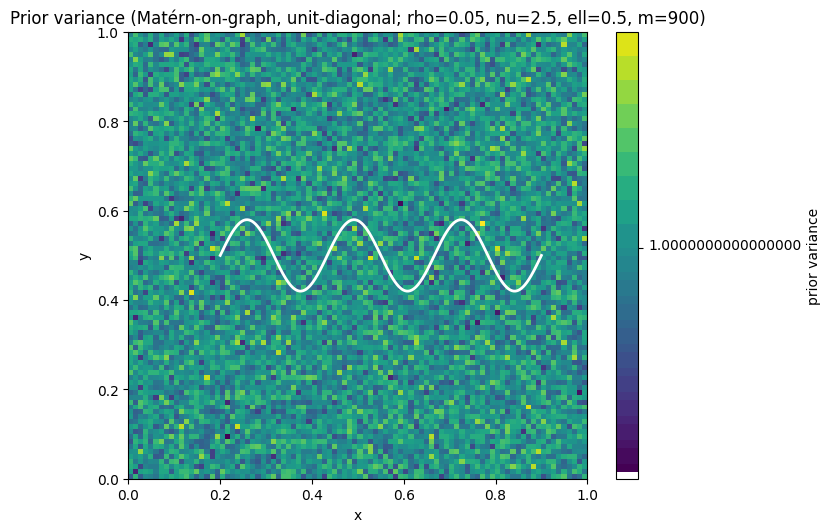

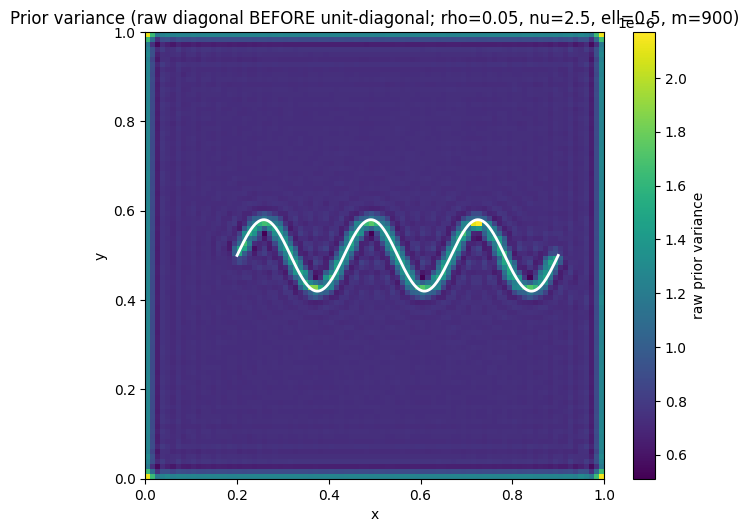

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse.linalg import eigsh
from scipy.linalg import cho_factor, cho_solve

# ============================================================
# Key fixes / changes:
# 1) Use a Matérn kernel derived from the Laplacian spectrum.
# 2) Enforce *unit diagonal* (correlation normalisation) to kill
#    boundary + discontinuity "brightness" in the prior/posterior
#    variance that comes from finite-domain / internal-boundary effects.
# 3) Remove unused heat-kernel path to avoid confusion.
# 4) Mildly improved defaults to reduce truncation ripples:
#      - prefer rho in [0.02, 0.08]
#      - increase m
#      - avoid huge ell (e.g. ell=0.5) unless you *want* global modes
# ============================================================


# ----------------------------
# Fast edge blocking (kept)
# ----------------------------
def precompute_blocked_edges(N, xs, ys, curve_pts, eps=1e-12):
    blocked_h = np.zeros((N - 1, N), dtype=bool)
    blocked_v = np.zeros((N, N - 1), dtype=bool)

    def clamp(a, lo, hi):
        return max(lo, min(hi, a))

    for k in range(len(curve_pts) - 1):
        x0, y0 = curve_pts[k]
        x1, y1 = curve_pts[k + 1]

        if abs(x0 - x1) < eps and abs(y0 - y1) < eps:
            continue

        # crossings with vertical grid lines x=xs[i] -> block vertical edges (i, j)-(i, j+1)
        xmin, xmax = (x0, x1) if x0 <= x1 else (x1, x0)
        i_lo = clamp(np.searchsorted(xs, xmin + eps), 0, N - 1)
        i_hi = clamp(np.searchsorted(xs, xmax - eps) - 1, 0, N - 1)

        if abs(x1 - x0) > eps and i_lo <= i_hi:
            for i in range(i_lo, i_hi + 1):
                xv = xs[i]
                t = (xv - x0) / (x1 - x0)
                if 0.0 < t < 1.0:
                    yv = y0 + t * (y1 - y0)
                    j = np.searchsorted(ys, yv) - 1
                    if 0 <= j < N - 1:
                        blocked_v[i, j] = True

        # crossings with horizontal grid lines y=ys[j] -> block horizontal edges (i, j)-(i+1, j)
        ymin, ymax = (y0, y1) if y0 <= y1 else (y1, y0)
        j_lo = clamp(np.searchsorted(ys, ymin + eps), 0, N - 1)
        j_hi = clamp(np.searchsorted(ys, ymax - eps) - 1, 0, N - 1)

        if abs(y1 - y0) > eps and j_lo <= j_hi:
            for j in range(j_lo, j_hi + 1):
                yv = ys[j]
                t = (yv - y0) / (y1 - y0)
                if 0.0 < t < 1.0:
                    xv = x0 + t * (x1 - x0)
                    i = np.searchsorted(xs, xv) - 1
                    if 0 <= i < N - 1:
                        blocked_h[i, j] = True

    return blocked_h, blocked_v


# ----------------------------
# Build weighted adjacency W fast from blocked masks
# ----------------------------
def build_weighted_adjacency_from_blocked(N, blocked_h, blocked_v, rho=0.0):
    """
    4-neighbour adjacency on N x N.
    If an edge is blocked, its weight is set to rho
      - rho=0.0 => hard barrier
      - 0<rho<1 => soft barrier
    """
    n = N * N

    def idx(i, j):
        return i * N + j

    rows, cols, data = [], [], []

    def add_undirected(a, b, w):
        rows.extend([a, b])
        cols.extend([b, a])
        data.extend([w, w])

    # horizontal edges: (i,j) <-> (i+1,j), i=0..N-2, j=0..N-1
    for i in range(N - 1):
        for j in range(N):
            w = rho if blocked_h[i, j] else 1.0
            if w != 0.0:
                a = idx(i, j)
                b = idx(i + 1, j)
                add_undirected(a, b, w)

    # vertical edges: (i,j) <-> (i,j+1), i=0..N-1, j=0..N-2
    for i in range(N):
        for j in range(N - 1):
            w = rho if blocked_v[i, j] else 1.0
            if w != 0.0:
                a = idx(i, j)
                b = idx(i, j + 1)
                add_undirected(a, b, w)

    W = sparse.coo_matrix((data, (rows, cols)), shape=(n, n)).tocsr()
    return W


# ----------------------------
# Matérn-on-graph via Laplacian spectrum (degree-corrected)
# ----------------------------
def matern_graph_eig(W, nu=2.5, ell=0.20, sigma2=1.0, m=600, d=2, eps=1e-12):
    """
    Construct low-rank approximation:
        K ≈ Phi diag(s) Phi^T

    We use the symmetric normalised Laplacian:
        L_sym = I - D^{-1/2} W D^{-1/2}

    Take eigenpairs (λ_k, U_k) of L_sym, and form degree-corrected features:
        Phi = D^{-1/2} U

    Then apply Matérn spectral weights:
        s_k = sigma2 * (kappa^2 + λ_k)^(-alpha)
        alpha = nu + d/2
        kappa = sqrt(2 nu) / ell      (heuristic but good as a lengthscale knob)

    NOTE: Even with degree-correction, diag(K) will not be constant on a bounded
    domain / with internal barriers. If you want to remove boundary/discontinuity
    brightness in variance plots, apply unit-diagonal normalisation below.
    """
    n = W.shape[0]
    deg = np.asarray(W.sum(axis=1)).ravel()
    inv_sqrt = 1.0 / np.sqrt(np.maximum(deg, eps))
    Dm12 = sparse.diags(inv_sqrt)

    Lsym = sparse.eye(n, format="csr") - (Dm12 @ W @ Dm12)

    # smallest eigenvalues/eigenvectors
    vals, U = eigsh(Lsym, k=m, which="SM")
    order = np.argsort(vals)
    vals = vals[order]
    U = U[:, order]

    Phi = inv_sqrt[:, None] * U

    alpha = nu + 0.5 * d
    kappa = np.sqrt(2.0 * nu) / max(ell, 1e-12)
    s = sigma2 * (kappa**2 + vals) ** (-alpha)
    return vals, Phi, s


# ----------------------------
# Unit-diagonal (correlation) normalisation
# ----------------------------
def unit_diagonal_features(Phi, s, eps=1e-12):
    """
    Given K ≈ Phi diag(s) Phi^T, enforce K_ii = 1 by rescaling rows of Phi.

    r_i^2 = sum_k s_k * Phi_{ik}^2  (approx prior variance at node i)
    Phi'_{ik} = Phi_{ik} / r_i
    => diag(K') ≈ 1

    Returns:
        Phi_ud: rescaled Phi
        prior_var_raw: r_i^2 (the original diagonal before normalisation)
    """
    prior_var_raw = (Phi**2) @ s
    r = np.sqrt(np.maximum(prior_var_raw, eps))
    Phi_ud = Phi / r[:, None]
    return Phi_ud, prior_var_raw


# ----------------------------
# GP variance computations (stable)
# ----------------------------
def gp_prior_posterior_variance(Phi, s, obs_nodes, sigma_n):
    """
    Kernel approx: K ≈ Phi diag(s) Phi^T

    Returns:
        prior_var: diag(K)
        post_var:  diag(K - K_xX (K_XX + σ_n^2 I)^{-1} K_Xx)
    """
    Phi_obs = Phi[obs_nodes, :]

    K_XX = (Phi_obs * s) @ Phi_obs.T
    K_XXn = K_XX + (sigma_n**2) * np.eye(K_XX.shape[0])

    prior_var = (Phi**2) @ s

    cF = cho_factor(K_XXn, lower=True, check_finite=False)

    K_xX = (Phi * s) @ Phi_obs.T
    sol = cho_solve(cF, K_xX.T, check_finite=False)  # (n_obs x n_all)

    reduction = np.sum(K_xX * sol.T, axis=1)
    post_var = np.maximum(prior_var - reduction, 0.0)
    return prior_var, post_var


# ----------------------------
# Example run
# ----------------------------
N = 90
xs = np.linspace(0, 1, N)
ys = np.linspace(0, 1, N)

ts = np.linspace(0, 1, 600)
curve_pts = np.c_[0.2 + 0.7 * ts, 0.5 + 0.08 * np.sin(6 * np.pi * ts)]

blocked_h, blocked_v = precompute_blocked_edges(N, xs, ys, curve_pts)

# Barrier strength:
# - very small rho (~0.02..0.08) often reduces ringing while still being "nearly discontinuous"
rho = 0.05
W = build_weighted_adjacency_from_blocked(N, blocked_h, blocked_v, rho=rho)

# Observations (nodes only)
rng = np.random.default_rng(2)
n_obs = 30
X_obs = rng.uniform(0, 1, size=(n_obs, 2))
i_obs = np.clip(np.round(X_obs[:, 0] * (N - 1)).astype(int), 0, N - 1)
j_obs = np.clip(np.round(X_obs[:, 1] * (N - 1)).astype(int), 0, N - 1)
obs_nodes = np.unique(i_obs * N + j_obs)

sigma_n = 1e-3

# Matérn hyperparameters
nu = 2.5
ell = 0.5
sigma2 = 1.0
m = 900

vals, Phi, s = matern_graph_eig(W, nu=nu, ell=ell, sigma2=sigma2, m=m, d=2)

# ---- CRITICAL: unit-diagonal normalisation to remove brightness ----
Phi, prior_var_raw = unit_diagonal_features(Phi, s)

prior_var, post_var = gp_prior_posterior_variance(Phi, s, obs_nodes, sigma_n)

prior_var_grid = prior_var.reshape(N, N).T
post_var_grid = post_var.reshape(N, N).T
prior_var_raw_grid = prior_var_raw.reshape(N, N).T

# Plots
fig, ax = plt.subplots(figsize=(7.4, 5.8))
im = ax.imshow(post_var_grid, origin="lower", extent=[0, 1, 0, 1], aspect="auto")
ax.scatter(xs[i_obs], ys[j_obs], s=20, marker="x")
ax.plot(curve_pts[:, 0], curve_pts[:, 1], linewidth=2, color="white")
ax.set_title(f"Posterior variance (Matérn-on-graph, unit-diagonal; rho={rho}, nu={nu}, ell={ell}, m={m})")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.colorbar(im, ax=ax, label="posterior variance")
plt.show()

fig2, ax2 = plt.subplots(figsize=(7.4, 5.8))
im2 = ax2.imshow(prior_var_grid, origin="lower", extent=[0, 1, 0, 1], aspect="auto")
ax2.plot(curve_pts[:, 0], curve_pts[:, 1], linewidth=2, color="white")
ax2.set_title(f"Prior variance (Matérn-on-graph, unit-diagonal; rho={rho}, nu={nu}, ell={ell}, m={m})")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
fig2.colorbar(im2, ax=ax2, label="prior variance")
plt.show()

# Optional: show what you were previously seeing (raw diagonal, before unit-diagonal normalisation)
fig3, ax3 = plt.subplots(figsize=(7.4, 5.8))
im3 = ax3.imshow(prior_var_raw_grid, origin="lower", extent=[0, 1, 0, 1], aspect="auto")
ax3.plot(curve_pts[:, 0], curve_pts[:, 1], linewidth=2, color="white")
ax3.set_title(f"Prior variance (raw diagonal BEFORE unit-diagonal; rho={rho}, nu={nu}, ell={ell}, m={m})")
ax3.set_xlabel("x")
ax3.set_ylabel("y")
fig3.colorbar(im3, ax=ax3, label="raw prior variance")
plt.show()

In [32]:
post_var

array([2.22901685e-08, 2.02063978e-08, 1.57293598e-08, ...,
       1.57687298e-08, 2.02130413e-08, 2.22842721e-08])